# Predicting Final State with Long Short‐Term Memory Neural Networks


Other papers: 

- Compares performance of traditional time series model to Neural Networks:
     Lou, H.-R., Wang, X., Gao, Y., & Zeng, Q. (2022). Comparison of ARIMA model, DNN model and LSTM model in predicting disease burden of occupational pneumoconiosis in Tianjin, China. BMC Public Health, 22(1), Article 2167. https://doi.org/10.1186/s12889-022-14642-3

- Predicting Parkisons Diagnosis: dd

  Tekindor, A. N., & Akman Aydın, E. (2025). Speech signals-based Parkinson’s disease diagnosis using hybrid autoencoder-LSTM models. Computers in Biology and Medicine, 193, Article 110334. https://doi.org/10.1016/j.compbiomed.2025.110334


In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import cross_val_predict
import random

## On Labor Force Exit

In [51]:

# Load the data
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Features to use
features = ['EMP_numeric', 'SLEDAI2_I', 'score_n', 'STERDOSE', 'ISDOSE', 'INCEPT',
            'AMDOSE', 'age_at_record', 'time_since_last', 
            'time_since_first', 'visit_num']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))


# Fill NA values
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3580384684.py:2: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3580384684.py:3: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Train Test Split

In [53]:
random.seed(365)
# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths



# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
random.seed(365)
# Corrected model training section
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Train the model with corrected class_weight
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict  # Use the computed weights
)

# Rest of your code remains the same...

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 203ms/step - accuracy: 0.2993 - loss: 1.7572 - val_accuracy: 0.1171 - val_loss: 1.7939
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 484ms/step - accuracy: 0.2246 - loss: 1.6480 - val_accuracy: 0.2927 - val_loss: 1.7745
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 777ms/step - accuracy: 0.3710 - loss: 1.7237 - val_accuracy: 0.7268 - val_loss: 1.6723
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 527ms/step - accuracy: 0.7020 - loss: 1.6738 - val_accuracy: 0.5902 - val_loss: 1.6689
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.6098 - loss: 1.6414 - val_accuracy: 0.7902 - val_loss: 1.3201
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.7833 - loss: 1.4991 - val_accuracy: 0.8000 - val_loss: 1.1999
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.7790 - loss: 1.4035 - val_accuracy: 0.8195 - val_loss: 1.1743
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.7317 - loss: 1.2677 - val_accuracy

Available columns in high_risk_df: ['PTNO', 'First_High_Risk_Date', 'Final_Outcome', 'Risk_Score', 'Threshold_Used', 'SLEDAI_at_Warning', 'Steroid_at_Warning', 'SDI_at_Warning', 'Immunosuppressant_at_Warning', 'Employment_at_Warning', 'Months_Prior_to_Exit', 'Warning_Type']

=== Value Distributions in High-Risk Patients (Unscaled) ===
SLEDAI:
 count    187.000000
mean       2.967914
std        3.239381
min        0.000000
25%        0.000000
50%        2.000000
75%        4.000000
max       18.000000
Name: SLEDAI_unscaled, dtype: float64

Steroid Doses:
 count    187.000000
mean       5.084492
std        7.766971
min        0.000000
25%        0.000000
50%        2.000000
75%        7.500000
max       60.000000
Name: Steroid_unscaled, dtype: float64

SDI Scores:
 count    187.000000
mean       1.812834
std        2.115546
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max       12.000000
Name: SDI_unscaled, dtype: float64

Immunosuppressant Doses:
 coun

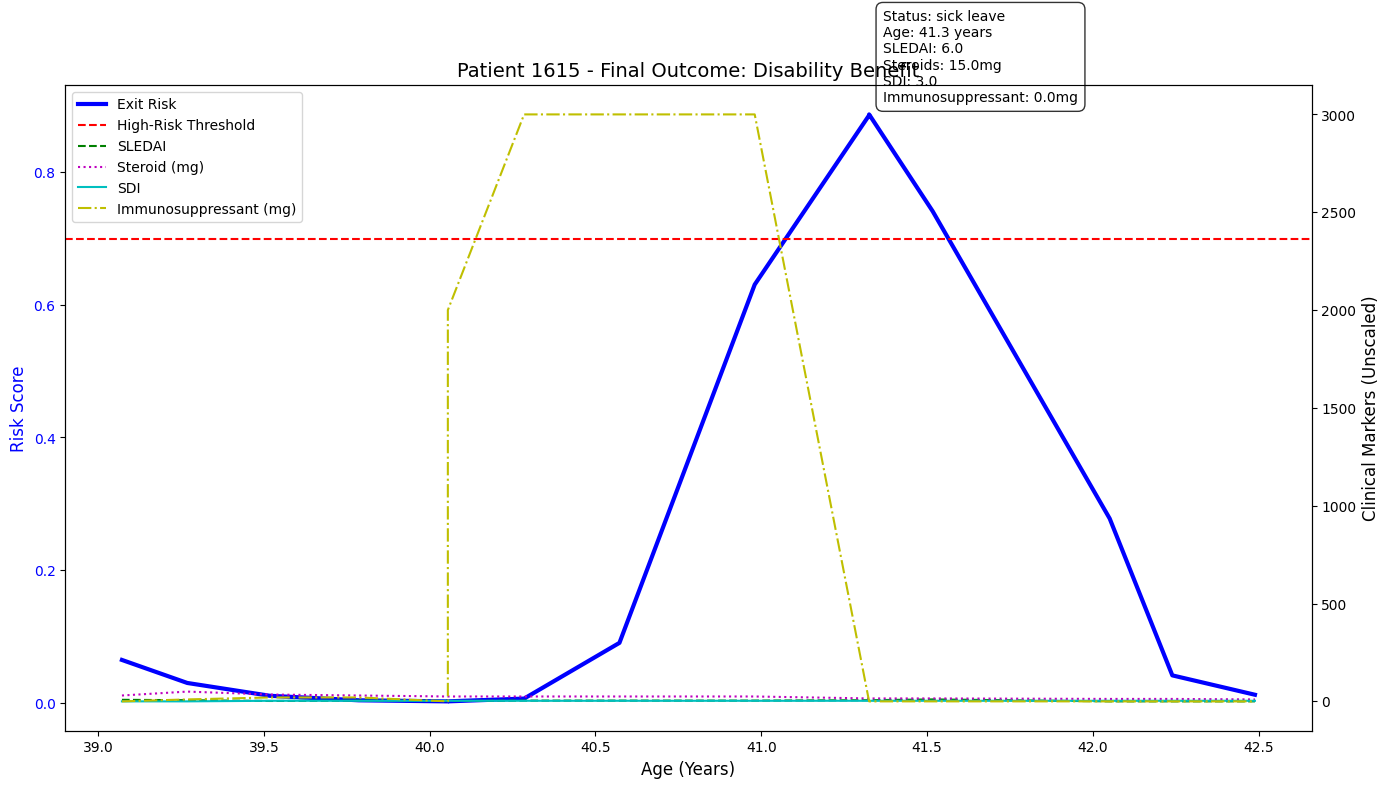

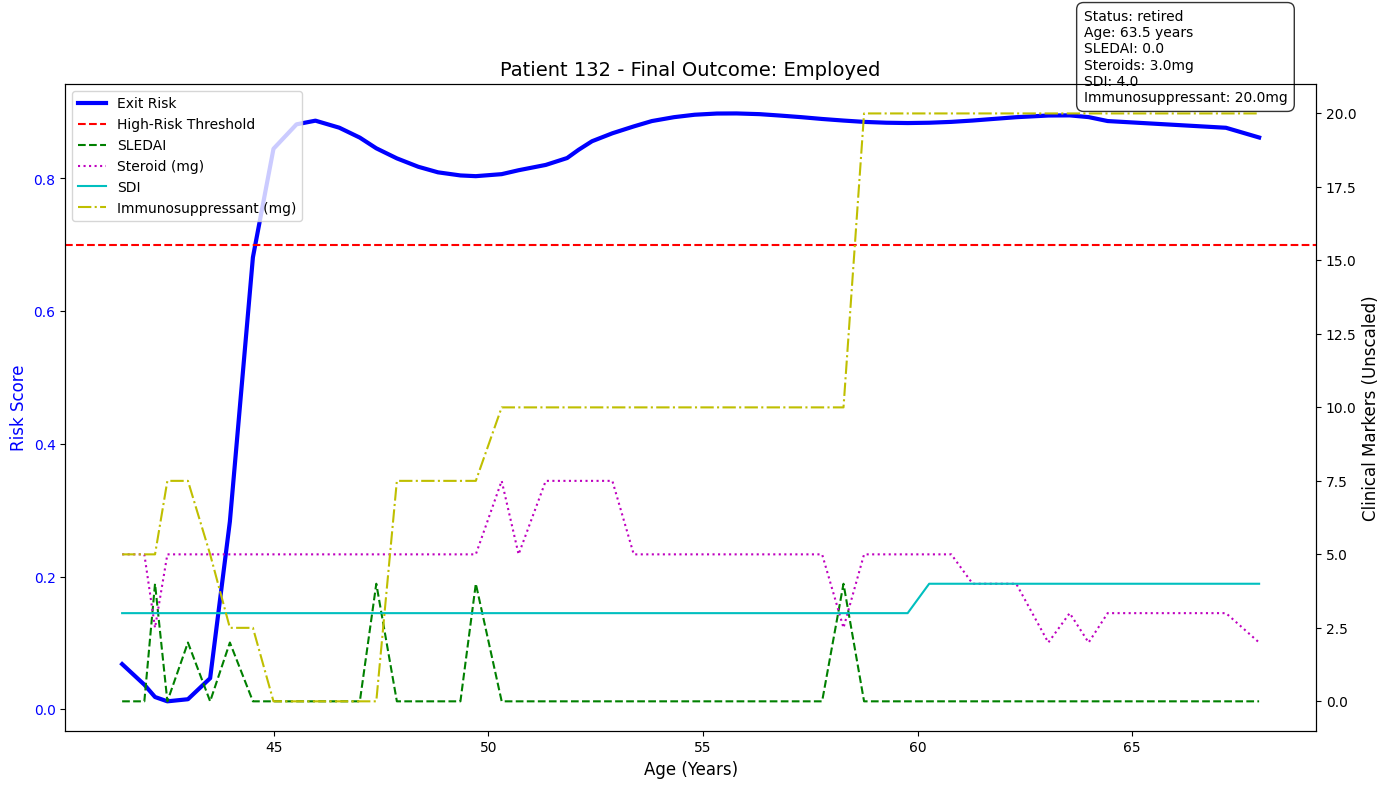

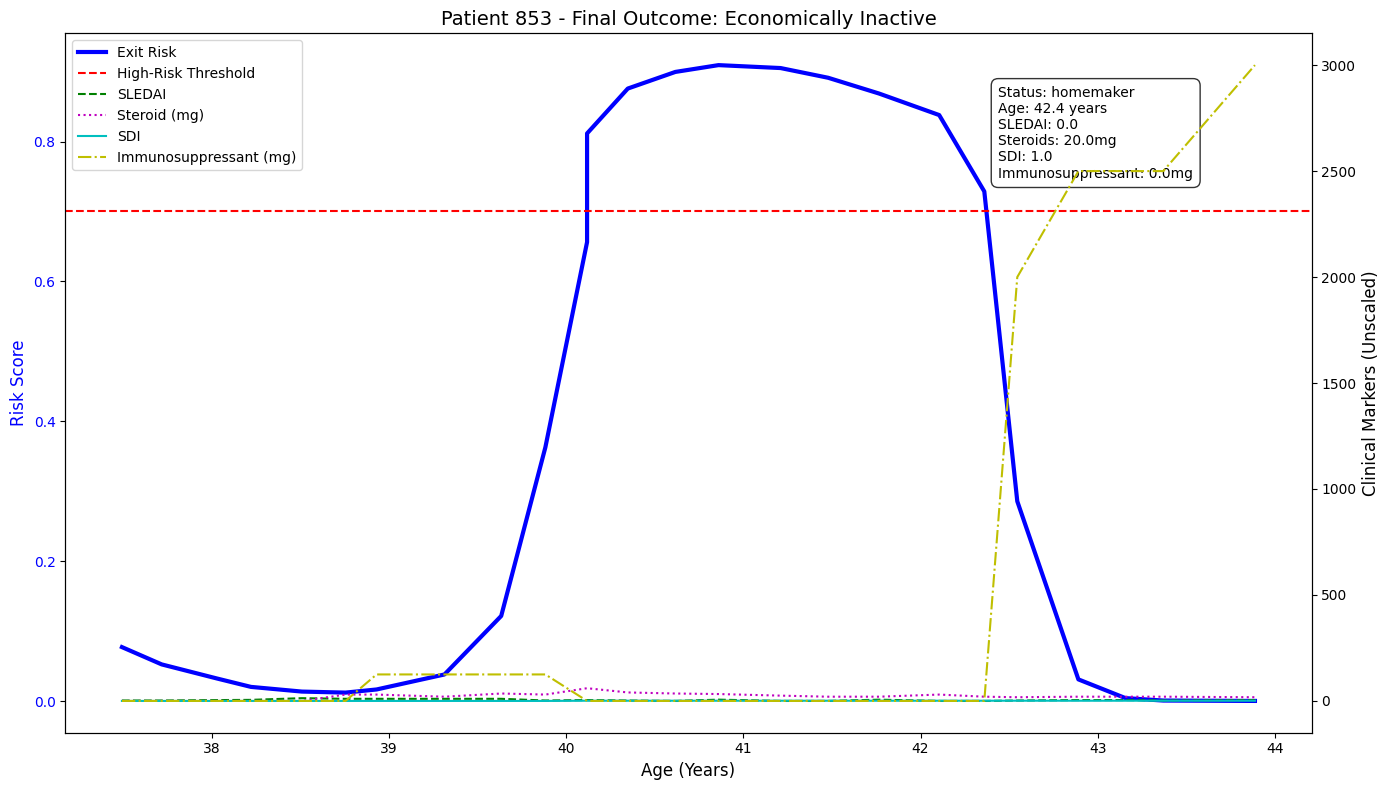

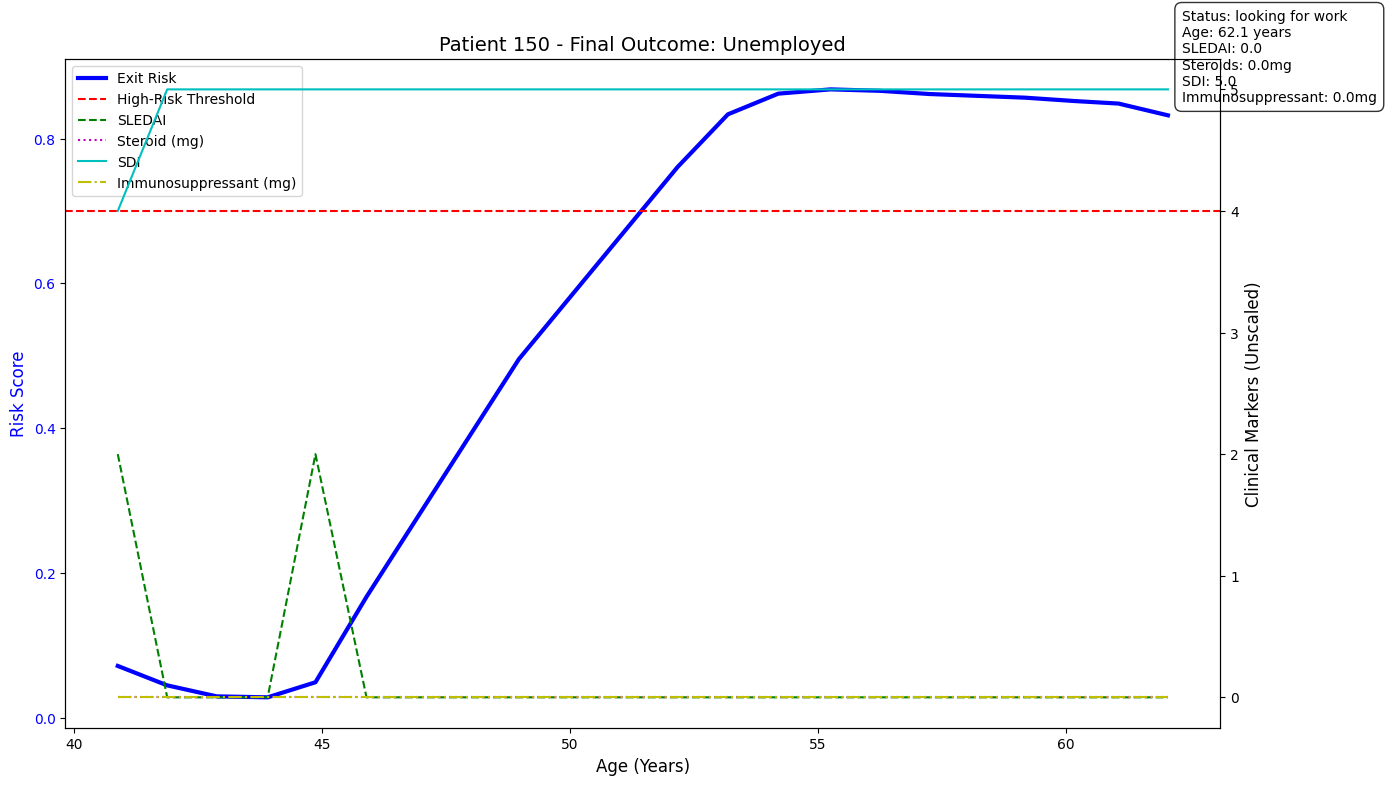

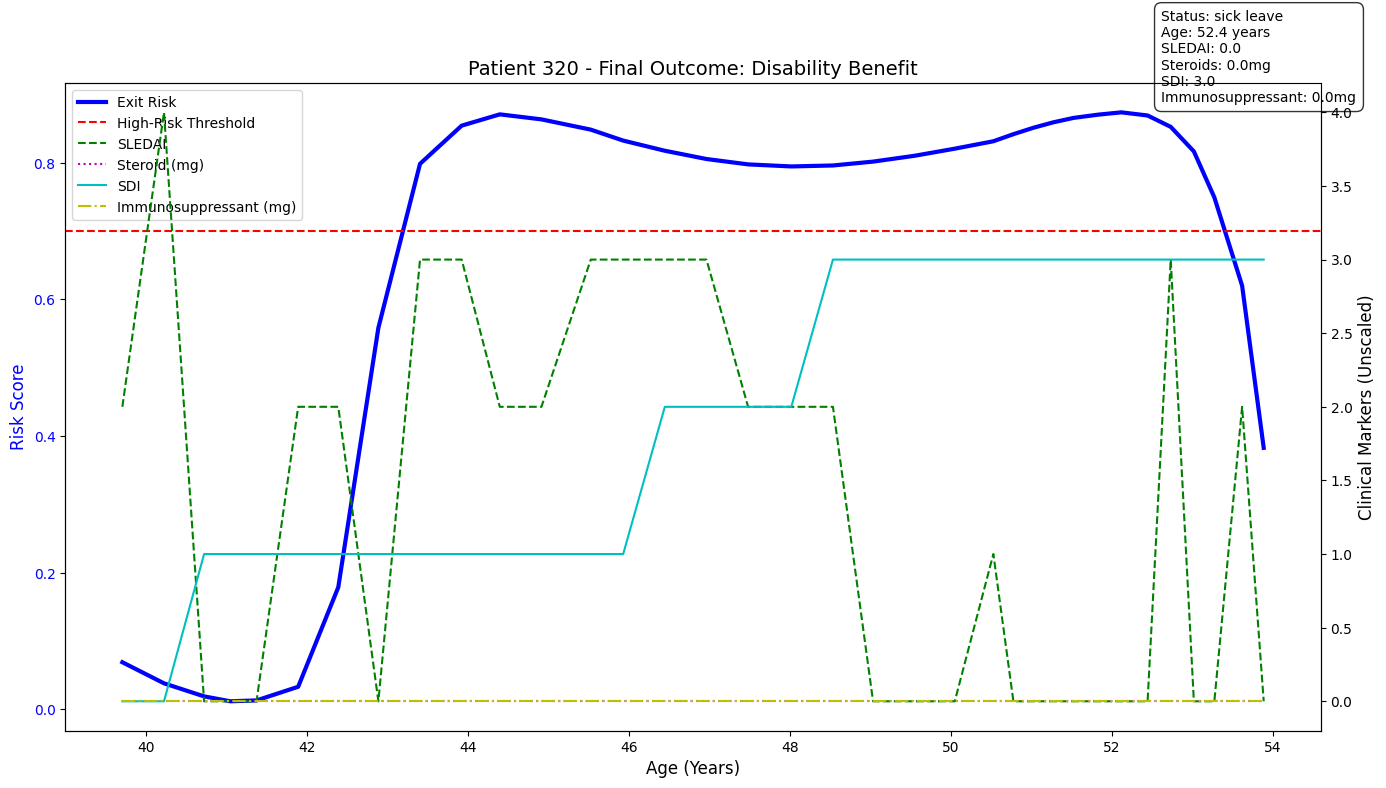

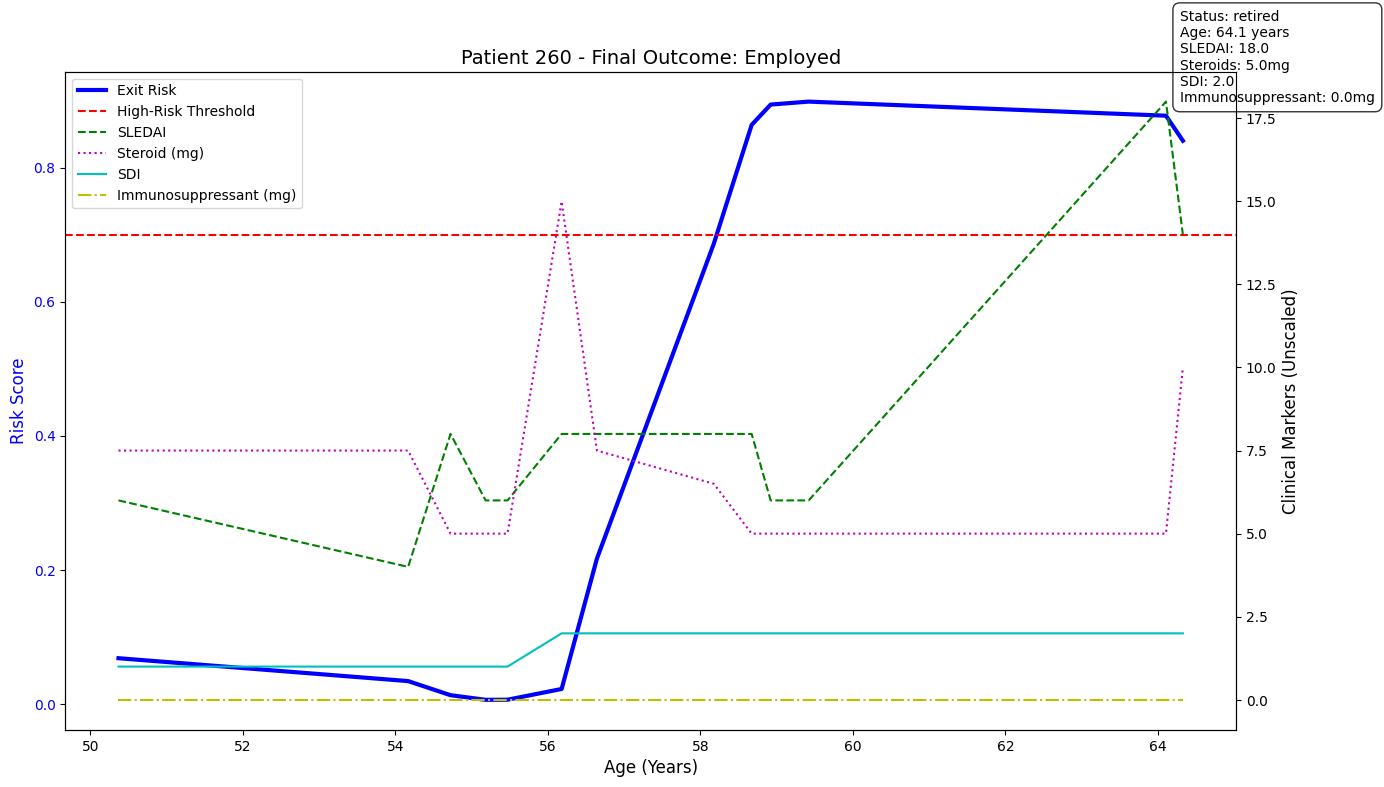

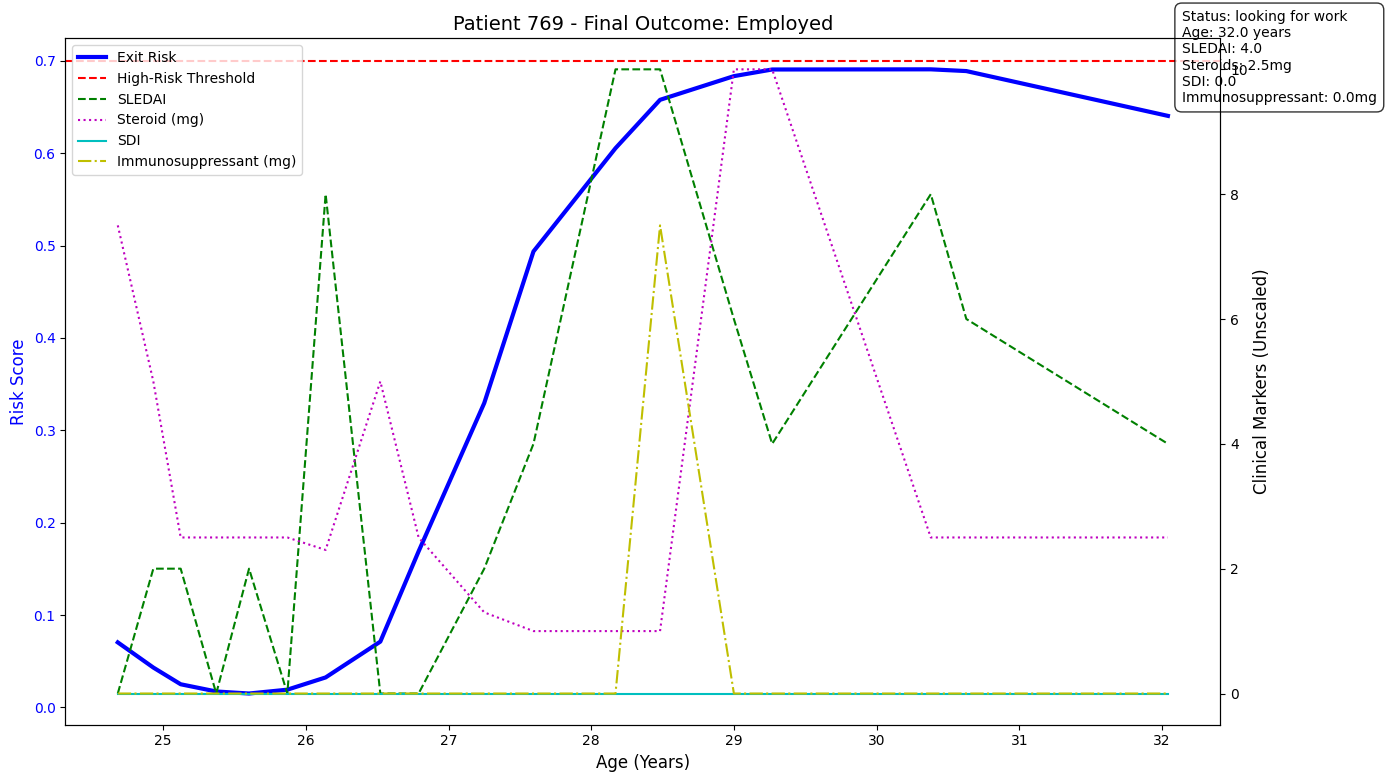

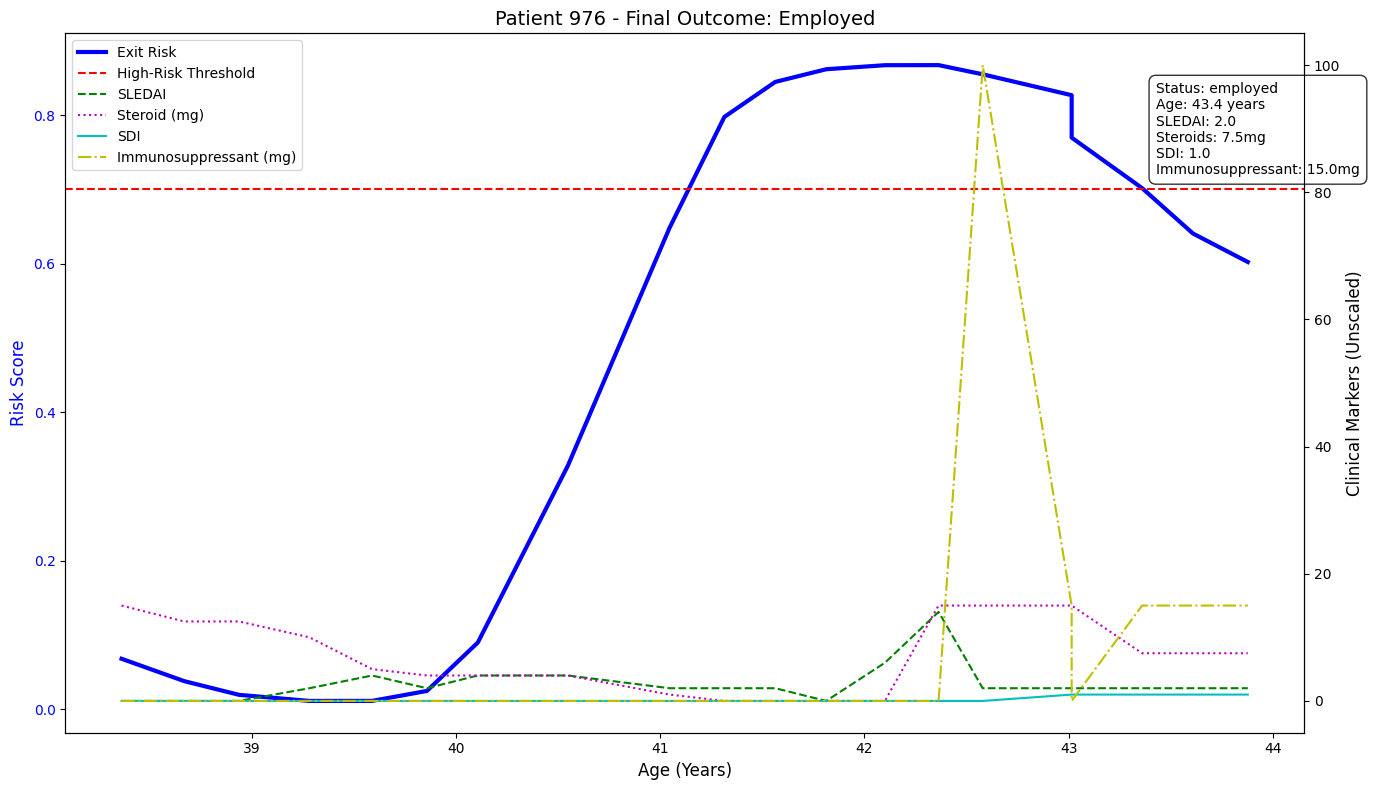

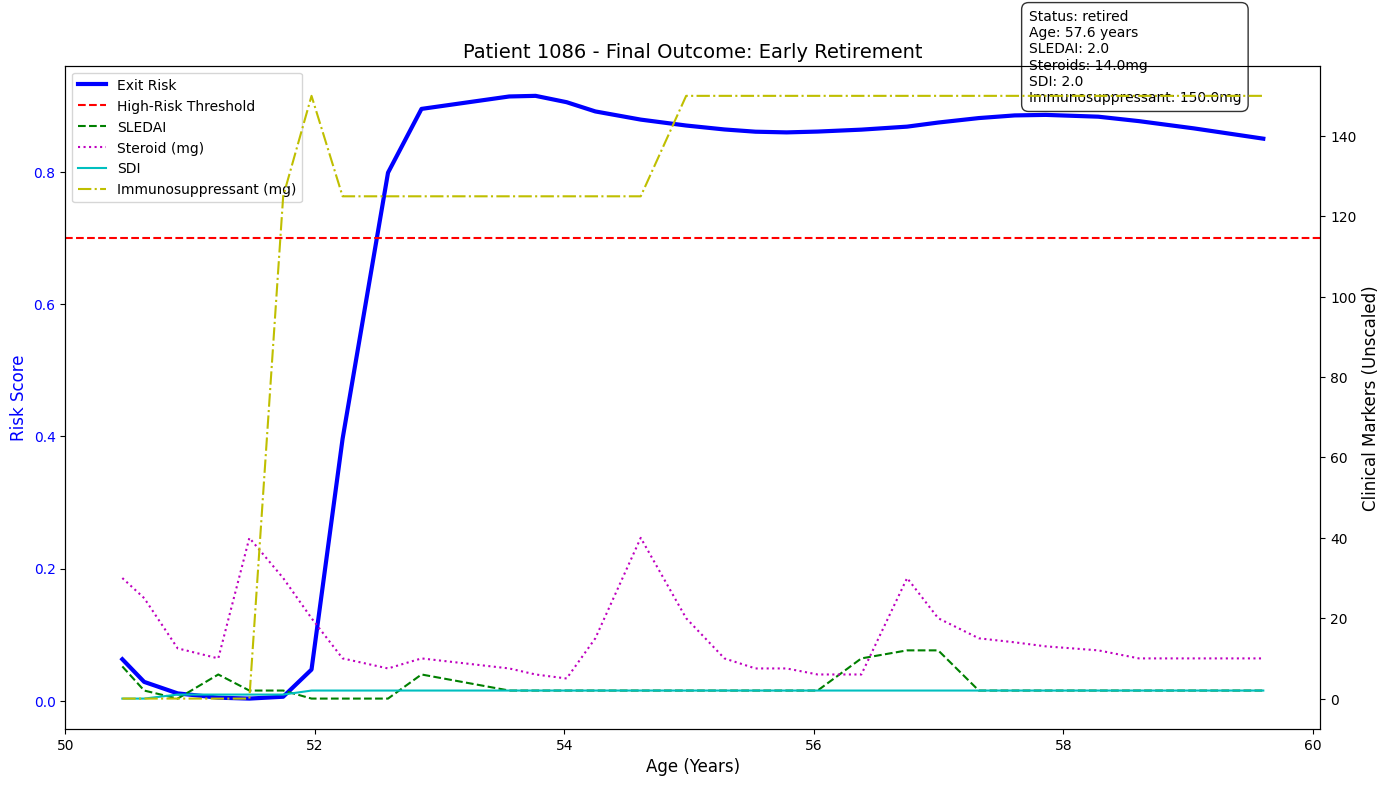

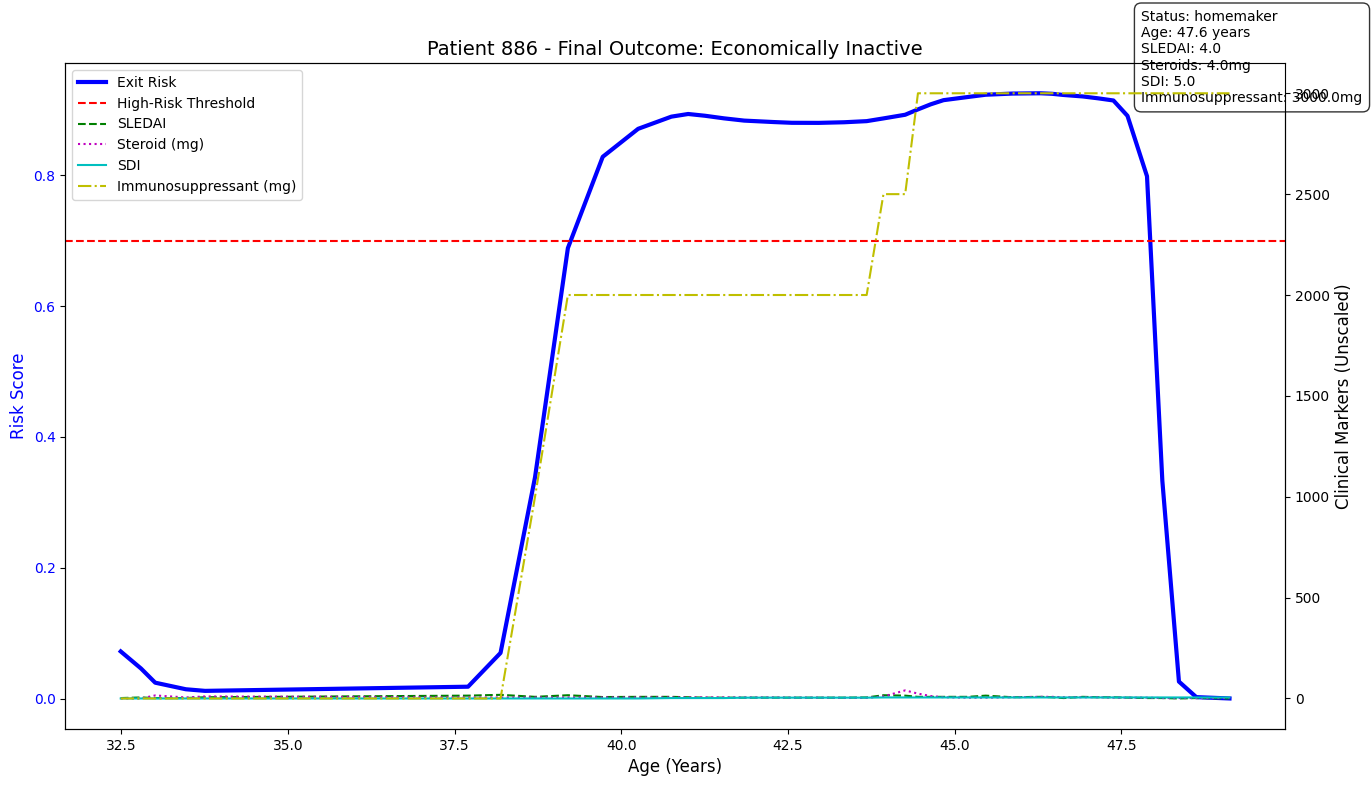

In [61]:
def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules
    THRESHOLD_RULES = [
        {'conditions': {'SLEDAI2_I': lambda x: x >= 6, 'STERDOSE': lambda x: x >= 7.5},
         'risk_threshold': 0.4},
        {'conditions': {'ISDOSE': lambda x: x >= 100},
         'risk_threshold': 0.35},
        {'conditions': {'EMPf': lambda x: 'unemployed' in x.lower()},
         'risk_threshold': 0.3},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prioritize warnings closer to employment change
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            # Only include warnings within 5 years of exit
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'SLEDAI_at_Warning': best_warning['context']['SLEDAI2_I'],
                    'Steroid_at_Warning': best_warning['context']['STERDOSE'],
                    'SDI_at_Warning': best_warning['context']['score_n'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'Very_High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] > 30])/len(high_risk_df):.0%} on >30mg prednisone",
            'High_ISDOSE': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 100])/len(high_risk_df):.0%} on high ISDOSE (≥100mg)",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Trigger_Types': {
            'Risk_Score_Only': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Risk_Score'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A",
            'Clinical_Deterioration': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Clinical_Deterioration'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

data['BIRTHDT'] = pd.to_datetime(data['BIRTHDT'])
# Print patients with final state "Disability Benefit"
# -------------------
high_risk_df = get_high_risk_patients(model, data, features)


# Execute the analysis with age on x-axis
# -------------------
# Generate clinical report with all predictors
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(10, len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)

In [63]:
def evaluate_flagging_performance(high_risk_df, data):
    """Evaluate how well the flagging system performed across the entire dataset"""
    
    # 1. Analyze flagged patients
    flagged_stats = {
        'total_flagged': len(high_risk_df),
        'still_employed_when_flagged': high_risk_df['Employment_at_Warning'].str.contains('employed', case=False).sum(),
        'percentage_still_employed': high_risk_df['Employment_at_Warning'].str.contains('employed', case=False).mean(),
        'median_months_before_exit': high_risk_df['Months_Prior_to_Exit'].median(),
        'early_warnings': (high_risk_df['Months_Prior_to_Exit'] > 12).sum(),
        'imminent_warnings': (high_risk_df['Months_Prior_to_Exit'] <= 12).sum()
    }
    
    # 2. Analyze entire dataset
    all_patients = data.groupby('PTNO').last().reset_index()
    should_have_been_flagged = all_patients[~all_patients['EMPf'].str.contains('employed', case=False)]
    was_flagged = all_patients['PTNO'].isin(high_risk_df['PTNO'])
    
    # Calculate confusion matrix components
    true_positives = len(high_risk_df)
    false_positives = len(was_flagged[was_flagged & all_patients['EMPf'].str.contains('employed', case=False)])
    false_negatives = len(should_have_been_flagged) - true_positives
    true_negatives = len(all_patients) - (true_positives + false_positives + false_negatives)
    
    # Calculate performance metrics
    sensitivity = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    specificity = true_negatives / (true_negatives + false_positives) if (true_negatives + false_positives) > 0 else 0
    
    overall_stats = {
        'total_patients': len(all_patients),
        'should_have_been_flagged': len(should_have_been_flagged),
        'was_flagged': true_positives,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'true_negatives': true_negatives,
        'sensitivity': sensitivity,
        'precision': precision,
        'specificity': specificity,
        'flagging_rate': true_positives / len(should_have_been_flagged) if len(should_have_been_flagged) > 0 else 0,
        'false_positive_rate': false_positives / (len(all_patients) - len(should_have_been_flagged)) if (len(all_patients) - len(should_have_been_flagged)) > 0 else 0
    }
    
    return flagged_stats, overall_stats

# After generating high_risk_df
flagged_stats, overall_stats = evaluate_flagging_performance(high_risk_df, data)

# Print detailed flagging report
print("\n=== Flagging Performance Report ===")
print("\nFlagged Patients Summary:")
print(f"- Total flagged: {flagged_stats['total_flagged']}")
print(f"- Still employed when flagged: {flagged_stats['still_employed_when_flagged']} ({flagged_stats['percentage_still_employed']:.1%})")
print(f"- Median months before exit: {flagged_stats['median_months_before_exit']}")
print(f"- Early warnings (>12 months): {flagged_stats['early_warnings']}")
print(f"- Imminent warnings (≤12 months): {flagged_stats['imminent_warnings']}")

print("\nOverall Flagging Accuracy:")
print(f"- Total patients: {overall_stats['total_patients']}")
print(f"- Should have been flagged (not employed at end): {overall_stats['should_have_been_flagged']}")
print(f"- Correctly flagged (true positives): {overall_stats['was_flagged']}")
print(f"- False positives: {overall_stats['false_positives']}")
print(f"- False negatives: {overall_stats['false_negatives']}")
print(f"- Sensitivity (recall): {overall_stats['sensitivity']:.1%}")
print(f"- Precision: {overall_stats['precision']:.1%}")
print(f"- Specificity: {overall_stats['specificity']:.1%}")
print(f"- Flagging rate: {overall_stats['flagging_rate']:.1%}")
print(f"- False positive rate: {overall_stats['false_positive_rate']:.1%}")

# Add to clinical report
clinical_report['Flagging_Performance'] = {
    'Flagged_Patients': flagged_stats,
    'Overall_Accuracy': overall_stats
}


=== Flagging Performance Report ===

Flagged Patients Summary:
- Total flagged: 187
- Still employed when flagged: 24 (12.8%)
- Median months before exit: 6.0
- Early warnings (>12 months): 44
- Imminent warnings (≤12 months): 143

Overall Flagging Accuracy:
- Total patients: 1025
- Should have been flagged (not employed at end): 238
- Correctly flagged (true positives): 187
- False positives: 28
- False negatives: 51
- Sensitivity (recall): 78.6%
- Precision: 87.0%
- Specificity: 96.4%
- Flagging rate: 78.6%
- False positive rate: 3.6%


## Enhanced Version

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/2669549878.py:137: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  data['score_n_change'] = data.groupby('PTNO')['score_n_change'].fillna(0)


Available columns in high_risk_df: ['PTNO', 'First_High_Risk_Date', 'Final_Outcome', 'Risk_Score', 'Threshold_Used', 'Rule_Triggered', 'SLEDAI_at_Warning', 'Steroid_at_Warning', 'SDI_at_Warning', 'SDI_Change_at_Warning', 'Immunosuppressant_at_Warning', 'Employment_at_Warning', 'Employment_Stability', 'Months_Prior_to_Exit', 'Warning_Type', 'Alert_Level']

=== Value Distributions in High-Risk Patients (Unscaled) ===
SLEDAI:
 count    186.000000
mean       3.172043
std        4.056689
min        0.000000
25%        0.000000
50%        2.000000
75%        4.000000
max       34.000000
Name: SLEDAI_unscaled, dtype: float64

Steroid Doses:
 count    186.000000
mean       5.473118
std        8.559605
min        0.000000
25%        0.000000
50%        1.250000
75%        7.500000
max       60.000000
Name: Steroid_unscaled, dtype: float64

SDI Scores:
 count    186.000000
mean       1.677419
std        2.022368
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max 

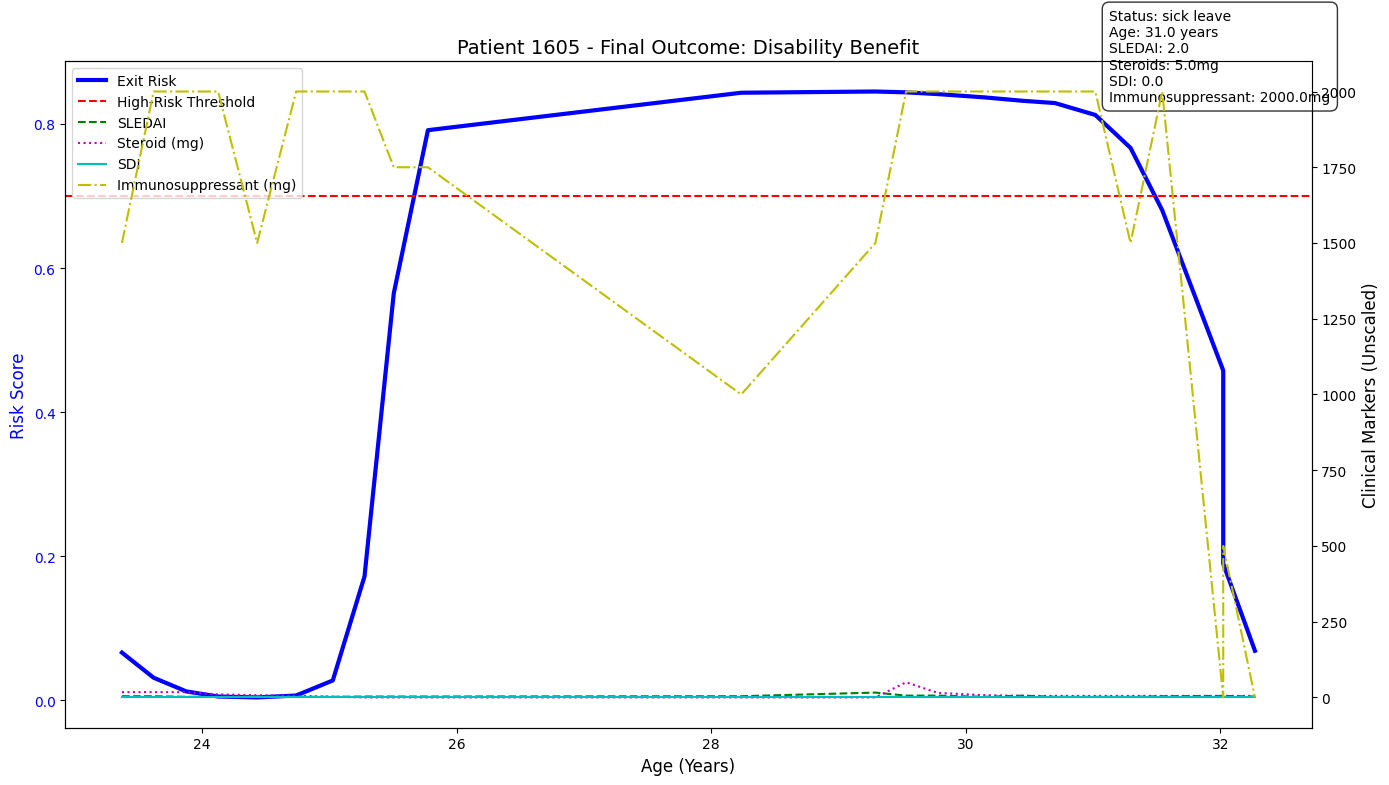

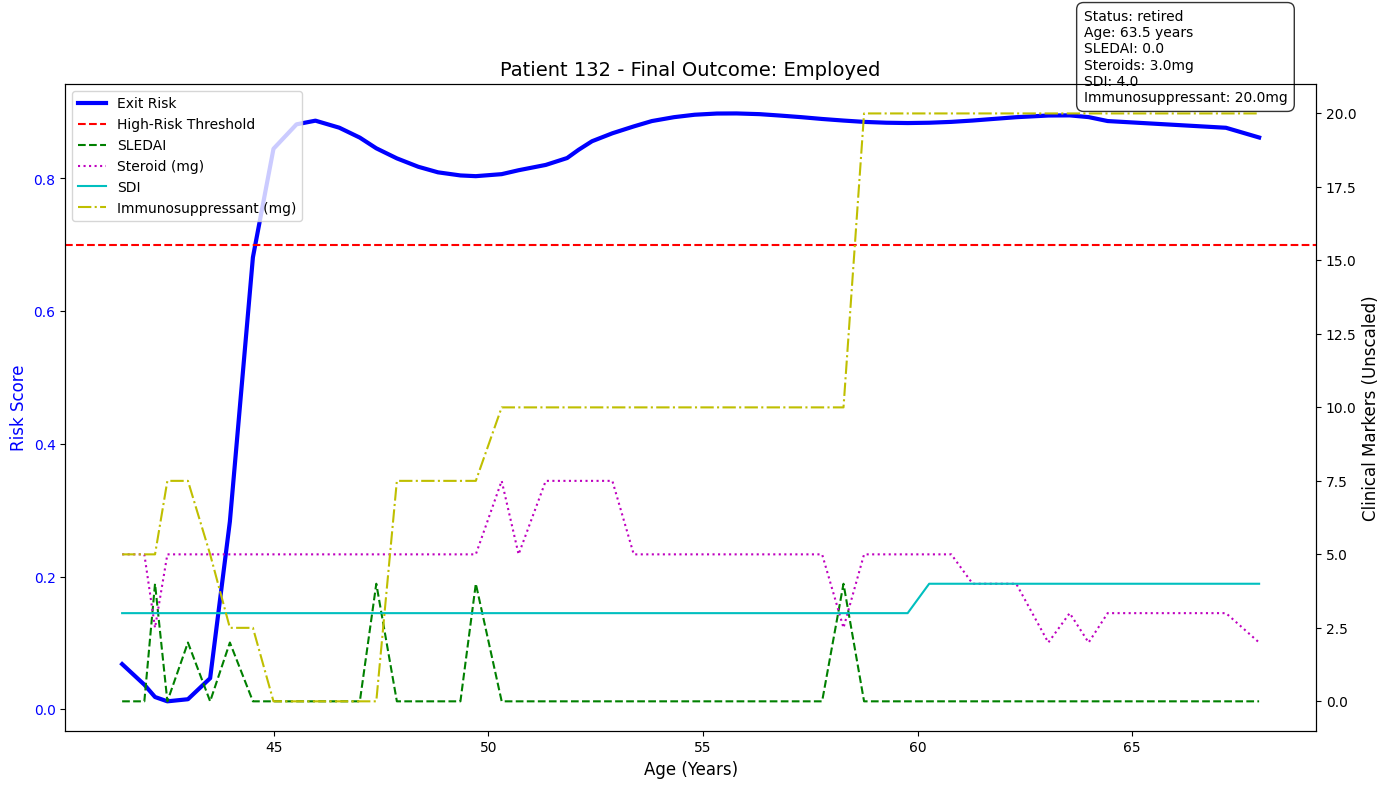

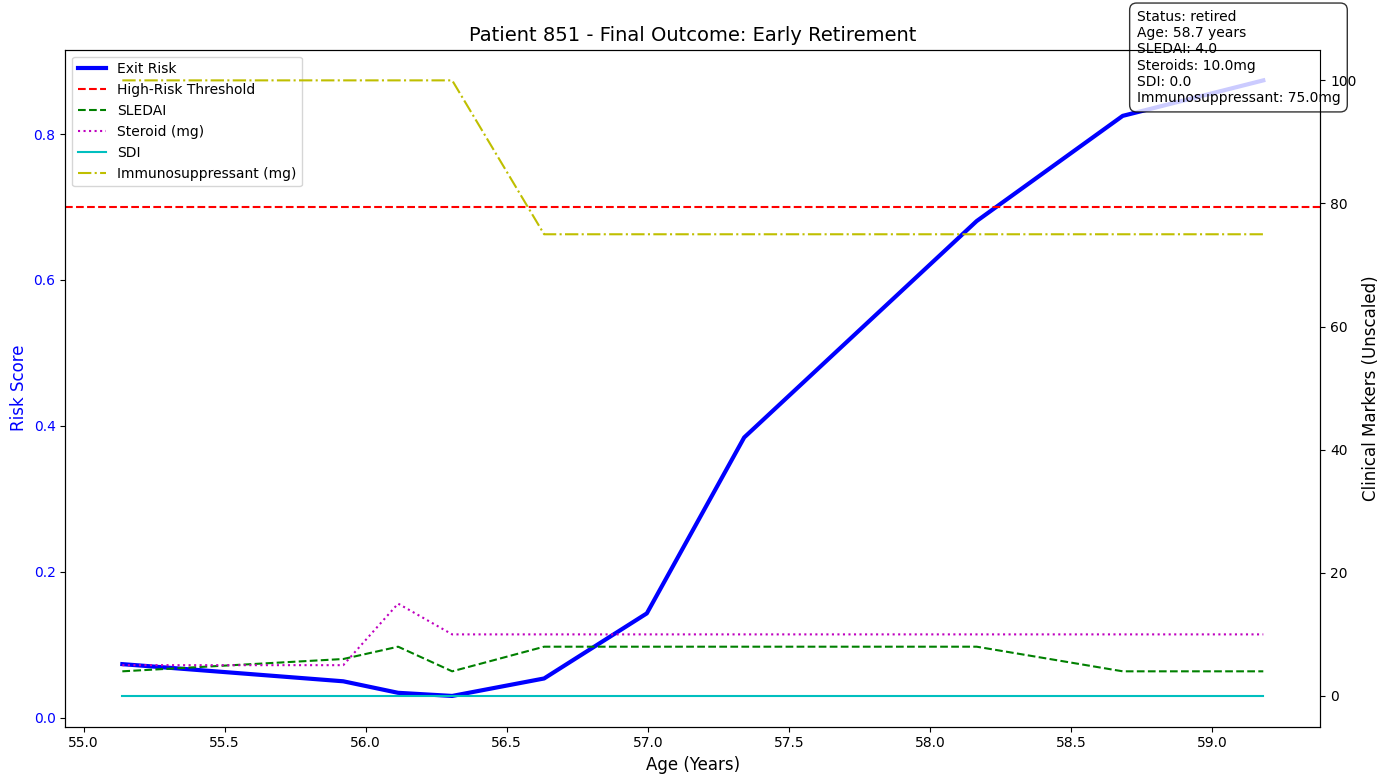

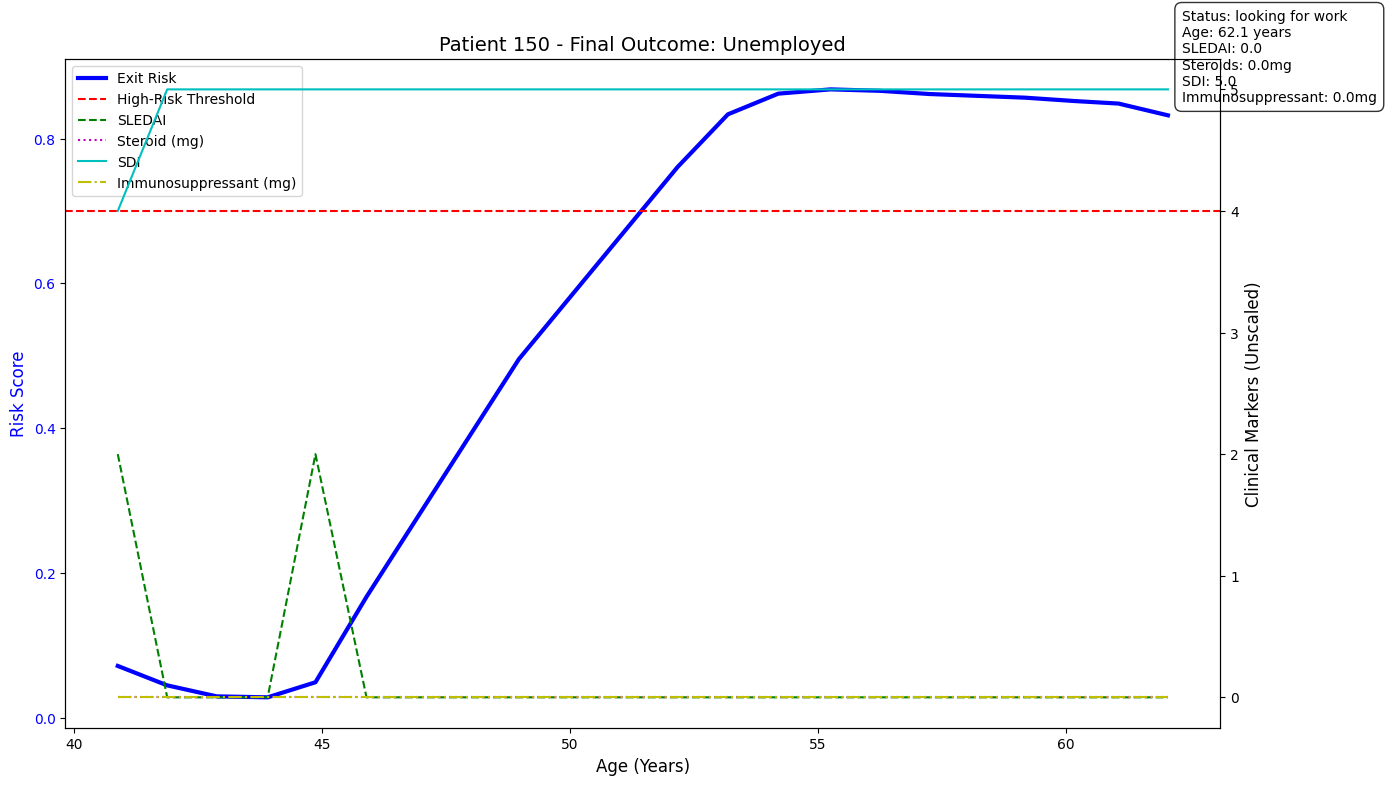

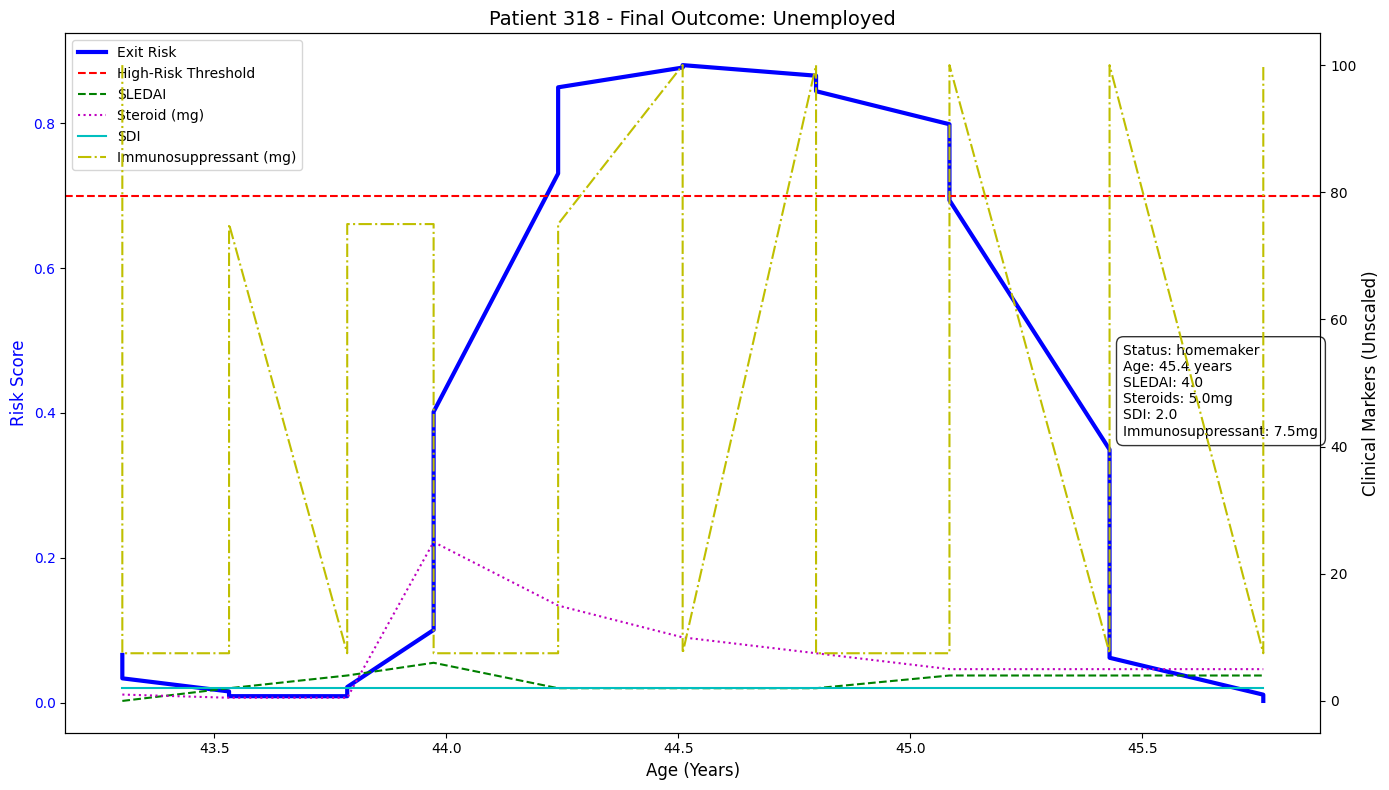

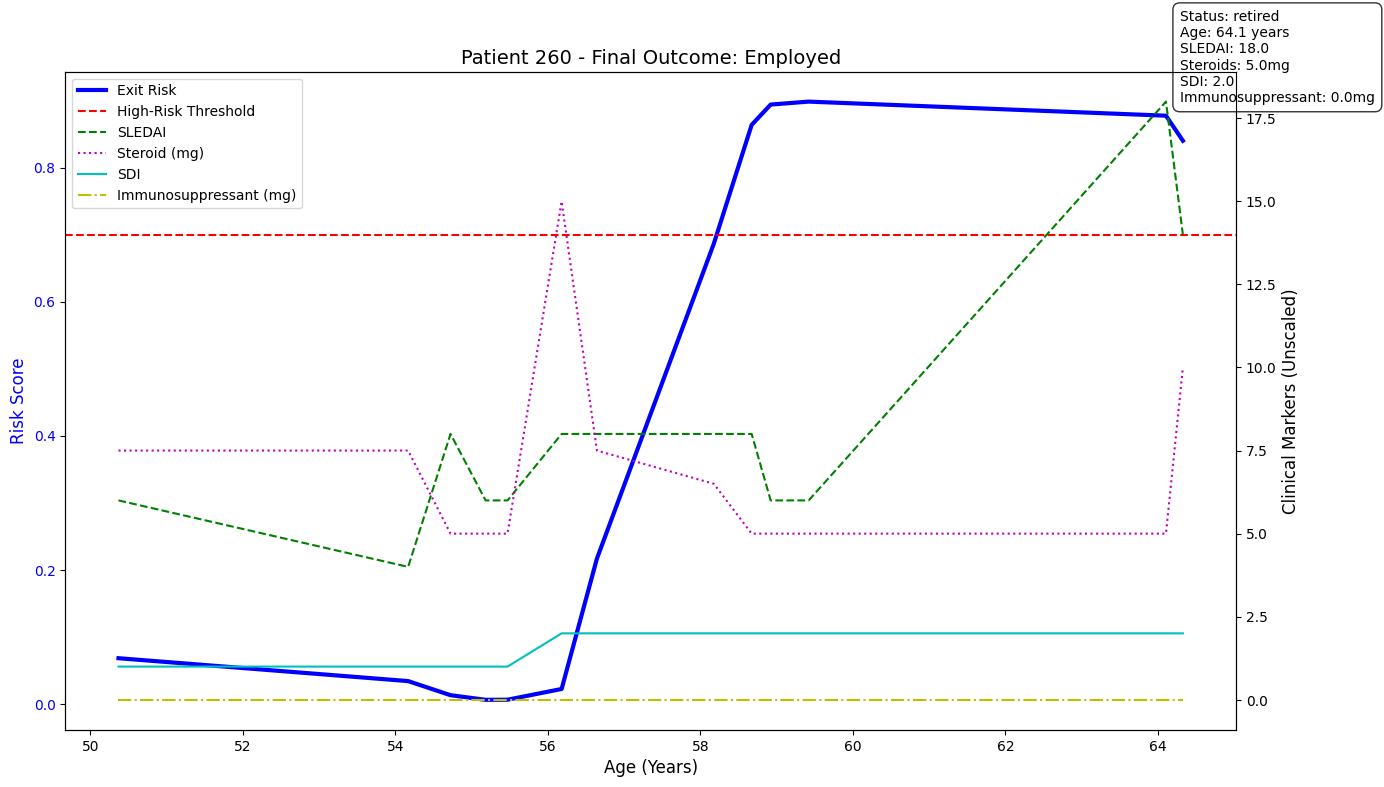

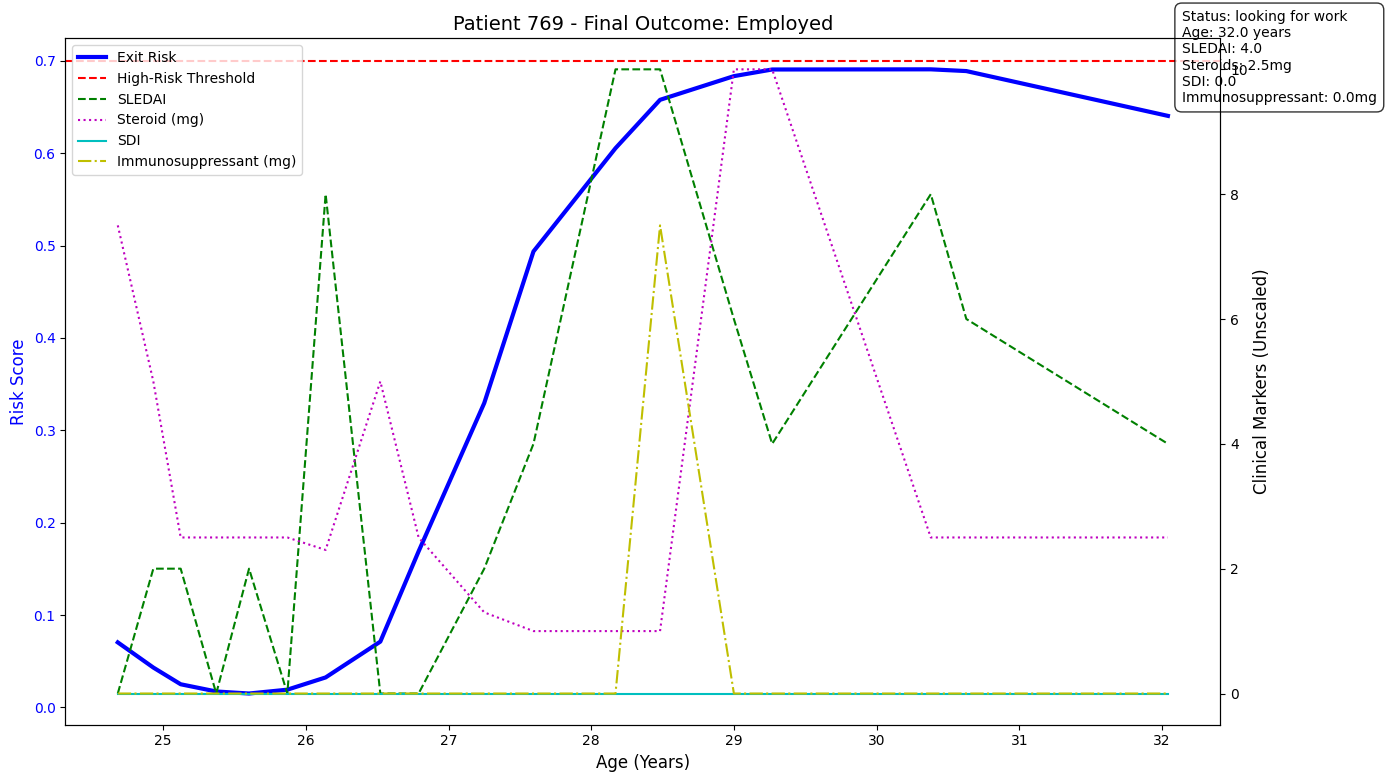

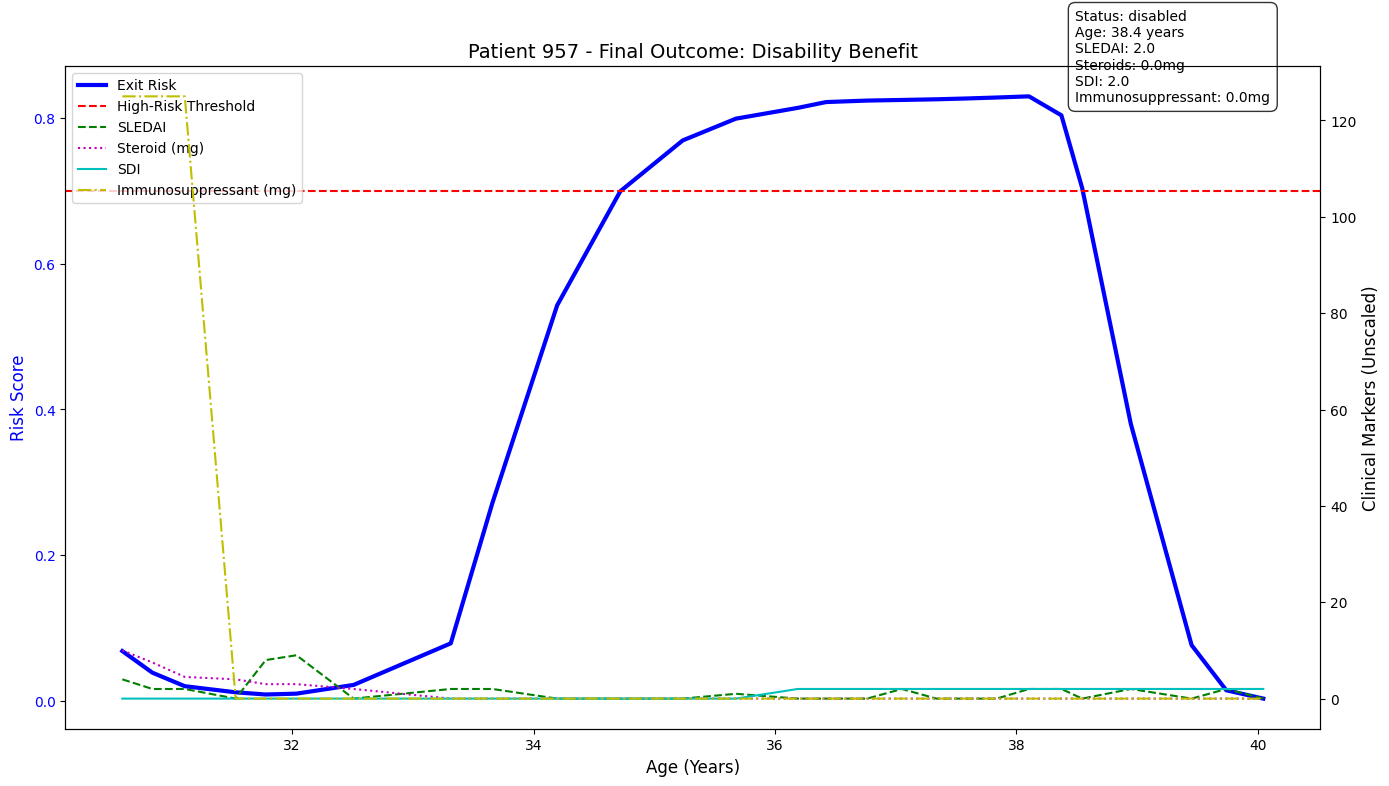

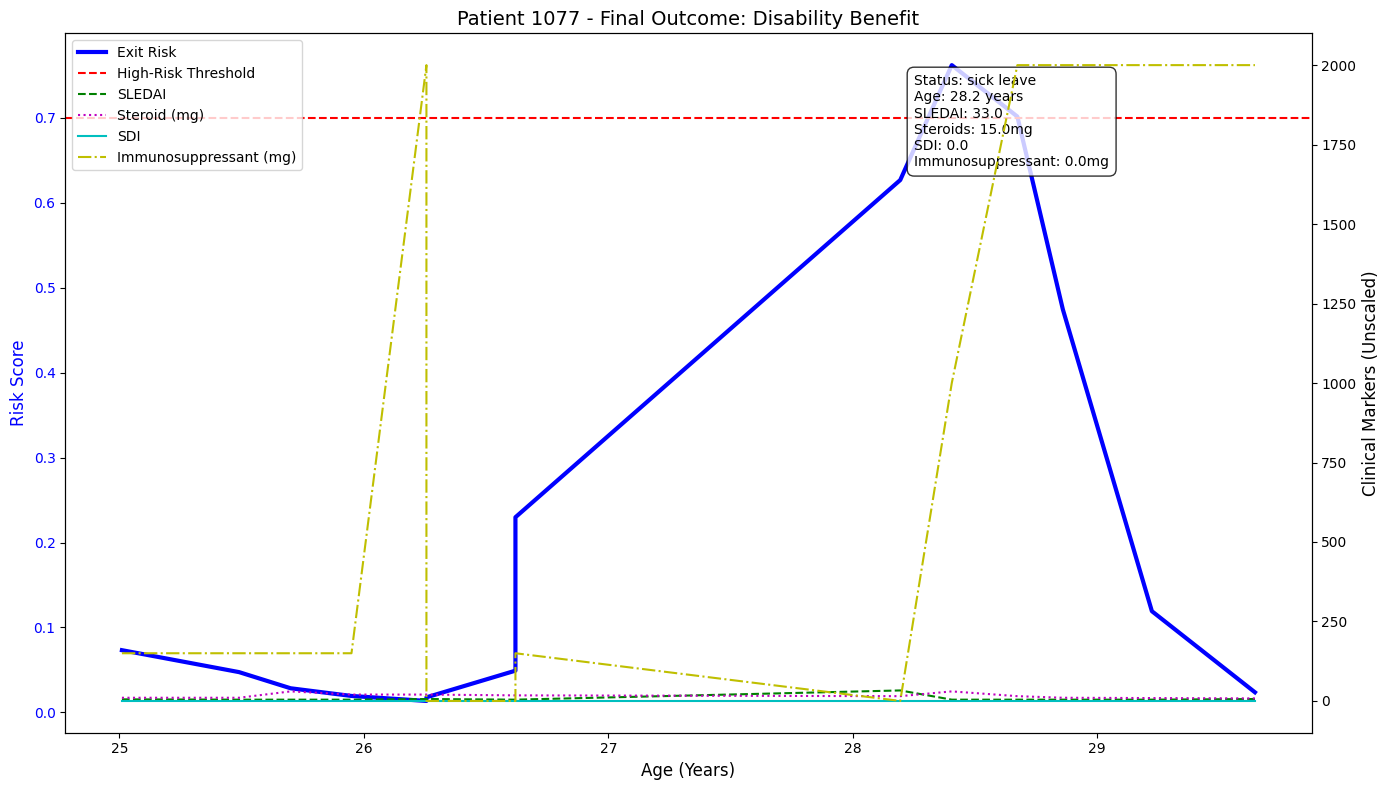

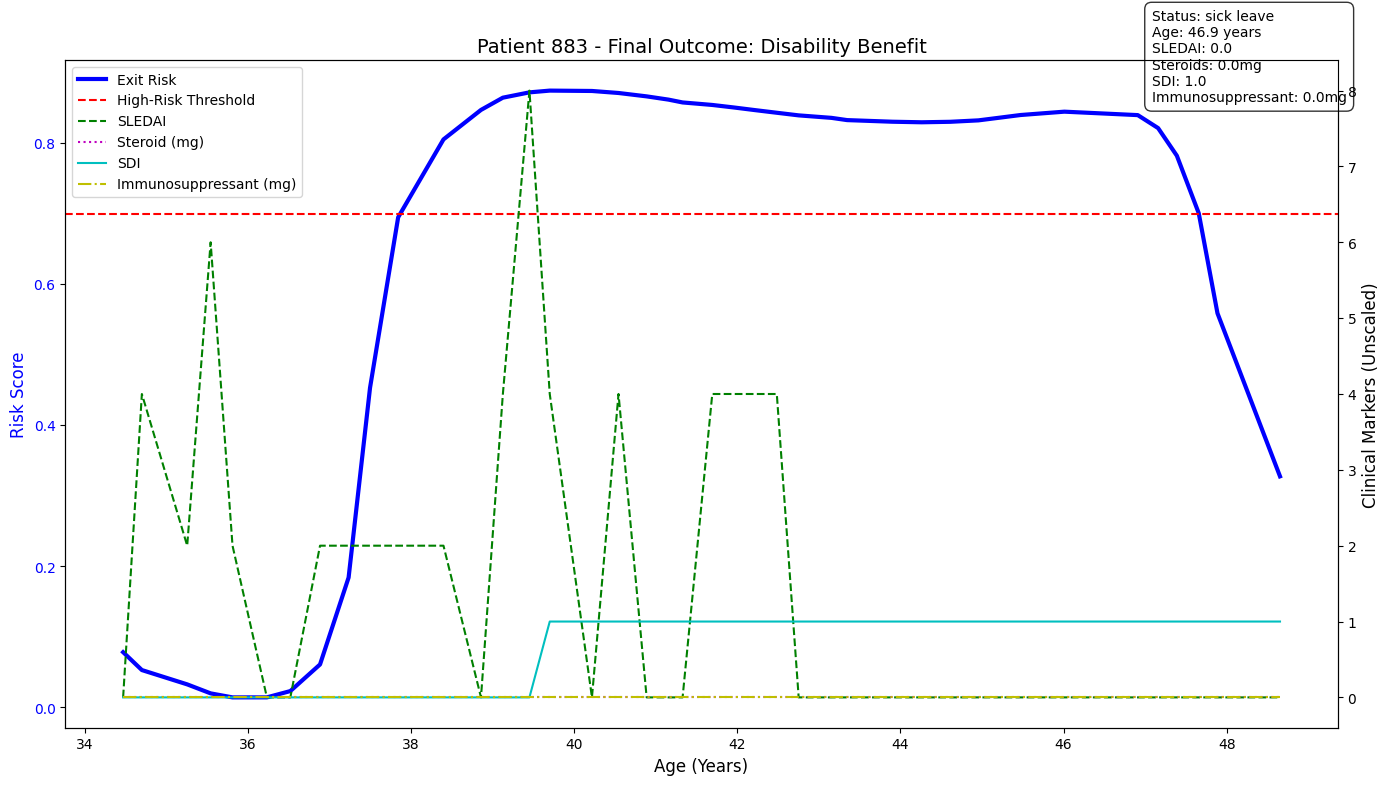

In [65]:
def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Enhanced threshold rules with SDI progression and employment stability
    THRESHOLD_RULES = [
        # Highest priority - acute high-risk situations
        {'conditions': {'SLEDAI2_I': lambda x: x >= 6, 'STERDOSE': lambda x: x >= 7.5},
         'risk_threshold': 0.4},
        {'conditions': {'ISDOSE': lambda x: x >= 100},
         'risk_threshold': 0.35},
         
        # New: SDI progression + employed cases
        {'conditions': {'score_n': lambda x: x >= 1, 'EMPf': lambda x: 'employed' in x.lower()},
         'risk_threshold': 0.35},
         
        # New: Progressive disease activity
        {'conditions': {'SLEDAI2_I': lambda x: x >= 4, 'STERDOSE': lambda x: x > 0,
                       'score_n_change': lambda x: x >= 0.5},
         'risk_threshold': 0.4},
         
        # Employment status change
        {'conditions': {'EMPf': lambda x: 'unemployed' in x.lower()},
         'risk_threshold': 0.3},
         
        # Default threshold
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    # Pre-calculate SDI progression rates
    data = calculate_sdi_progression(data)
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Track employment stability
        emp_history = []
        warning_points = []
        
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            emp_history.append(current_data['EMPf'])
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                    
                # Check if all conditions are met
                conditions_met = True
                for k, f in rule['conditions'].items():
                    if k not in current_data:
                        conditions_met = False
                        break
                    if not f(current_data[k]):
                        conditions_met = False
                        break
                
                if conditions_met:
                    applied_threshold = rule['risk_threshold']
                    break
            
            # Check employment stability (for reducing false positives)
            is_stable = len(set(emp_history)) == 1  # All statuses same
            
            if current_risk >= applied_threshold and not is_stable:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold,
                    'rule_triggered': str(rule.get('conditions', 'default'))
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prioritize by: 1. Clinical urgency, 2. Proximity to exit
            warning_points.sort(
                key=lambda x: (
                    -x['risk'],  # Higher risk first
                    abs((patient_data['ASSDT'].iloc[-1] - x['date']).days)  # Then closest to exit
            )
            )
            
            best_warning = warning_points[0]
            months_prior = (patient_data['ASSDT'].iloc[-1] - best_warning['date']).days // 30
            
            # Categorize warning type
            if months_prior > 24:
                warning_type = 'Very Early'
            elif months_prior > 12:
                warning_type = 'Early'
            else:
                warning_type = 'Imminent'
            
            # Include all relevant warnings (not just closest to exit)
            high_risk.append({
                'PTNO': pid,
                'First_High_Risk_Date': best_warning['date'],
                'Final_Outcome': patient_data['end_state'].iloc[-1],
                'Risk_Score': best_warning['risk'],
                'Threshold_Used': best_warning['threshold'],
                'Rule_Triggered': best_warning['rule_triggered'],
                'SLEDAI_at_Warning': best_warning['context']['SLEDAI2_I'],
                'Steroid_at_Warning': best_warning['context']['STERDOSE'],
                'SDI_at_Warning': best_warning['context']['score_n'],
                'SDI_Change_at_Warning': best_warning['context'].get('score_n_change', 0),
                'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                'Employment_at_Warning': best_warning['context']['EMPf'],
                'Employment_Stability': is_stable,
                'Months_Prior_to_Exit': months_prior,
                'Warning_Type': warning_type,
                'Alert_Level': ('Red' if best_warning['risk'] > 0.45 or 
                               'unemployed' in best_warning['context']['EMPf'].lower() 
                               else 'Yellow')
            })
    
    return pd.DataFrame(high_risk)

def calculate_sdi_progression(data):
    """Calculate SDI progression between visits"""
    data = data.sort_values(['PTNO', 'ASSDT'])
    
    # Calculate change from previous visit
    data['score_n_change'] = data.groupby('PTNO')['score_n'].diff()
    
    # Fill first visit with 0 change
    data['score_n_change'] = data.groupby('PTNO')['score_n_change'].fillna(0)
    
    return data

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'Very_High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] > 30])/len(high_risk_df):.0%} on >30mg prednisone",
            'High_ISDOSE': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 100])/len(high_risk_df):.0%} on high ISDOSE (≥100mg)",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Trigger_Types': {
            'Risk_Score_Only': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Risk_Score'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A",
            'Clinical_Deterioration': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Clinical_Deterioration'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

data['BIRTHDT'] = pd.to_datetime(data['BIRTHDT'])
# Example usage:
data = calculate_sdi_progression(data)
high_risk_df = get_high_risk_patients(model, data, features)

# Then generate your clinical report as before
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)


# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(10, len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)

## Looking only at employed portion

In [66]:

# Load the data
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Features to use
features = ['EMP_numeric', 'SLEDAI2_I', 'score_n', 'STERDOSE', 'ISDOSE', 'INCEPT',
            'AMDOSE', 'age_at_record', 'time_since_last', 
            'time_since_first', 'visit_num']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))


# Fill NA values
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3580384684.py:2: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3580384684.py:3: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 0.1484 - loss: 1.8681 - val_accuracy: 0.0244 - val_loss: 1.8000
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.0763 - loss: 1.7329 - val_accuracy: 0.1561 - val_loss: 1.7973
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.2429 - loss: 1.5528 - val_accuracy: 0.4976 - val_loss: 1.7339
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.6468 - loss: 1.5770 - val_accuracy: 0.7463 - val_loss: 1.6219
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.7443 - loss: 1.5936 - val_accuracy: 0.7561 - val_loss: 1.5449
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.7520 - loss: 1.5338 - val_accuracy: 0.7512 - val_loss: 1.3889
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.7550 - loss: 1.5658 - val_accuracy: 0.7366 - val_loss: 1.2619
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.7729 - loss: 1.3792 - val_accuracy: 0.7

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

Available columns in high_risk_df: ['PTNO', 'First_High_Risk_Date', 'Final_Outcome', 'Risk_Score', 'Threshold_Used', 'SLEDAI_at_Warning', 'Steroid_at_Warning', 'SDI_at_Warning', 'Immunosuppressant_at_Warning', 'Employment_at_Warning', 'Months_Prior_to_Exit', 'Warning_Type']

=== Value Distributions in High-Risk Patients (Unscaled) ===
SLEDAI:
 count    208.000000
mean       3.533654
std        4.252742
min        0.000000
25%        0.000000
50%        2.000000
75%        5.000000
max       33.000000
Name: SLEDAI_unscaled, dtype: float64

Steroid Doses:
 count    208.000000
mean       6.452404
std        8.633537
min        0.000000
25%        0.000000
50%        3.900000
75%       10.000000
max       40.000000
Name: Steroid_unscaled, dtype: float64

SDI Scores:
 count    208.000000
mean       1.639423
std        2.066476
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max       12.000000
Name: SDI_unscaled, dtype: float64

Immunosuppressant Doses:
 coun

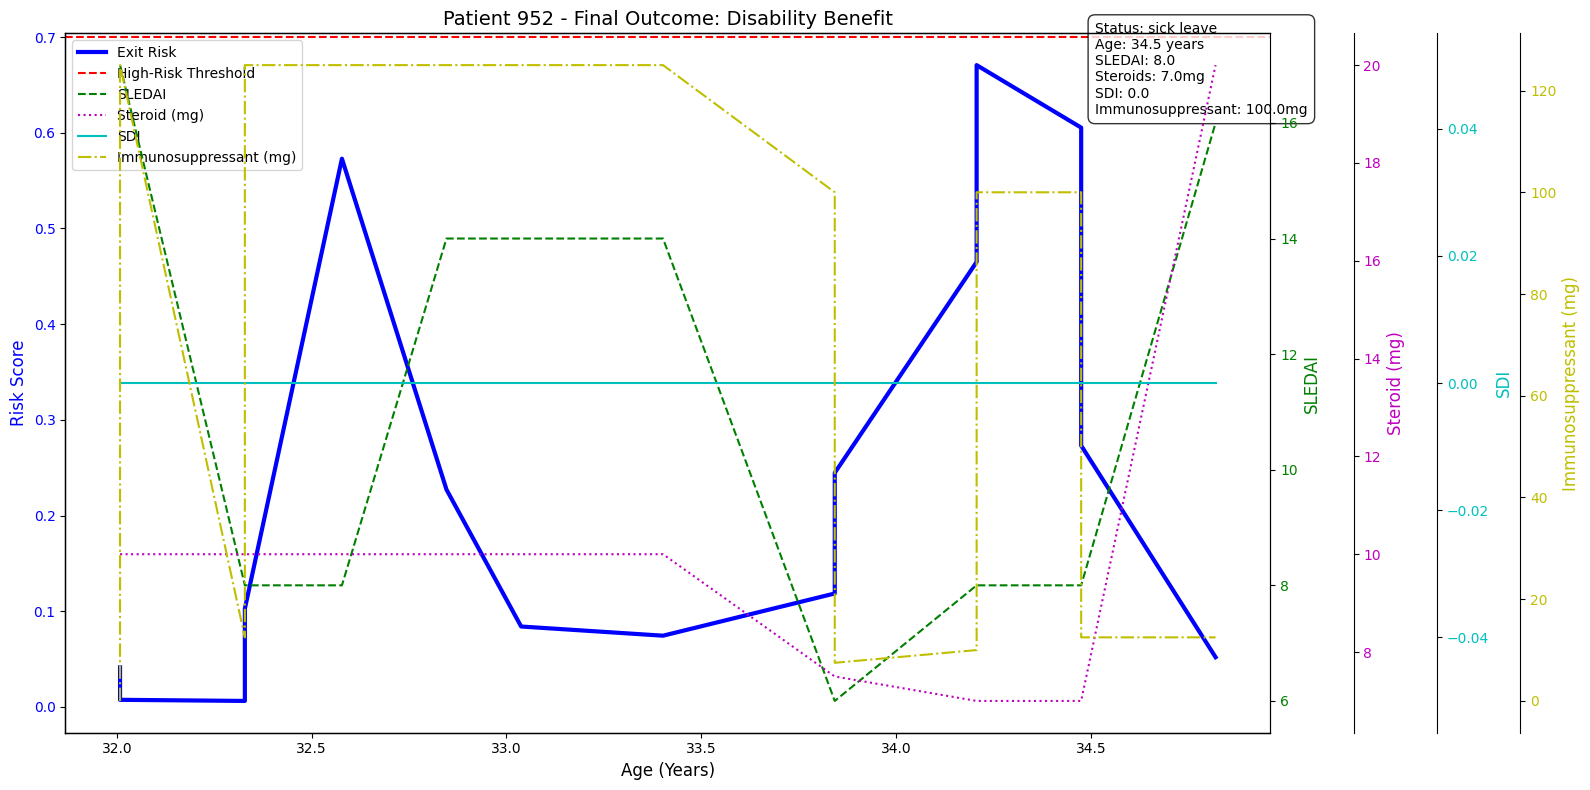

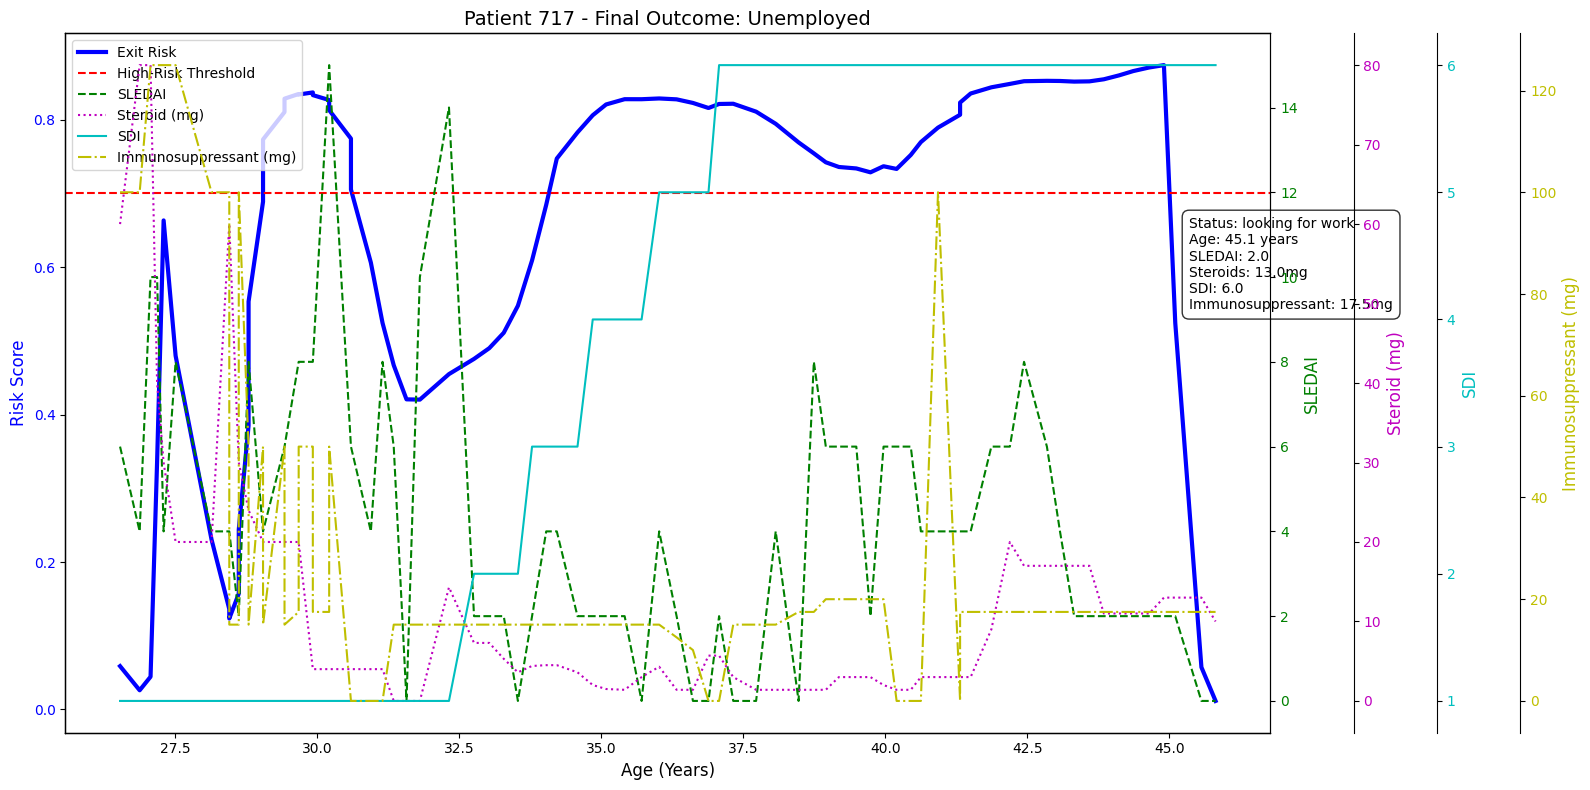

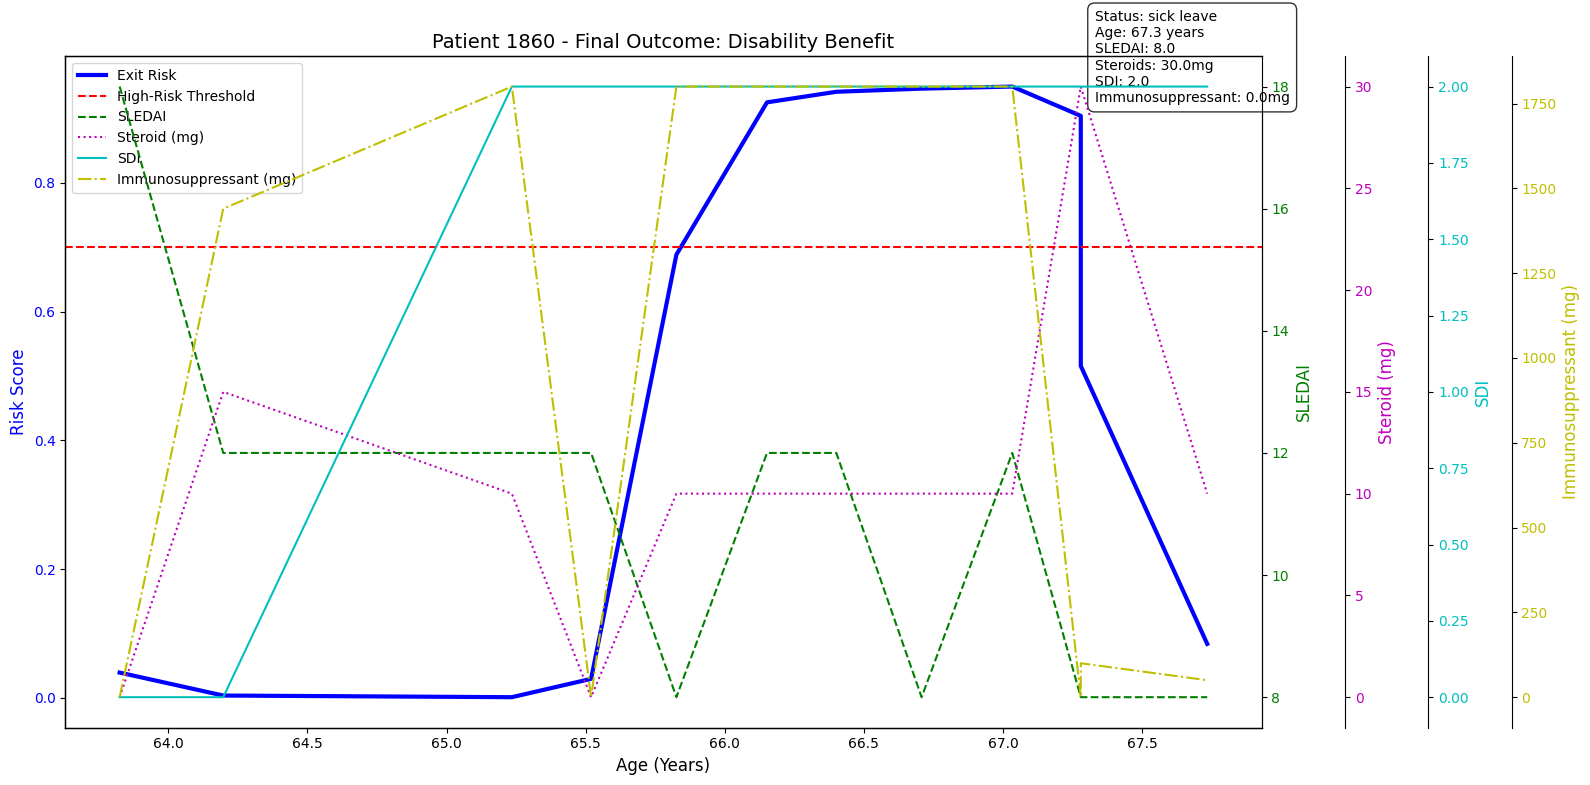

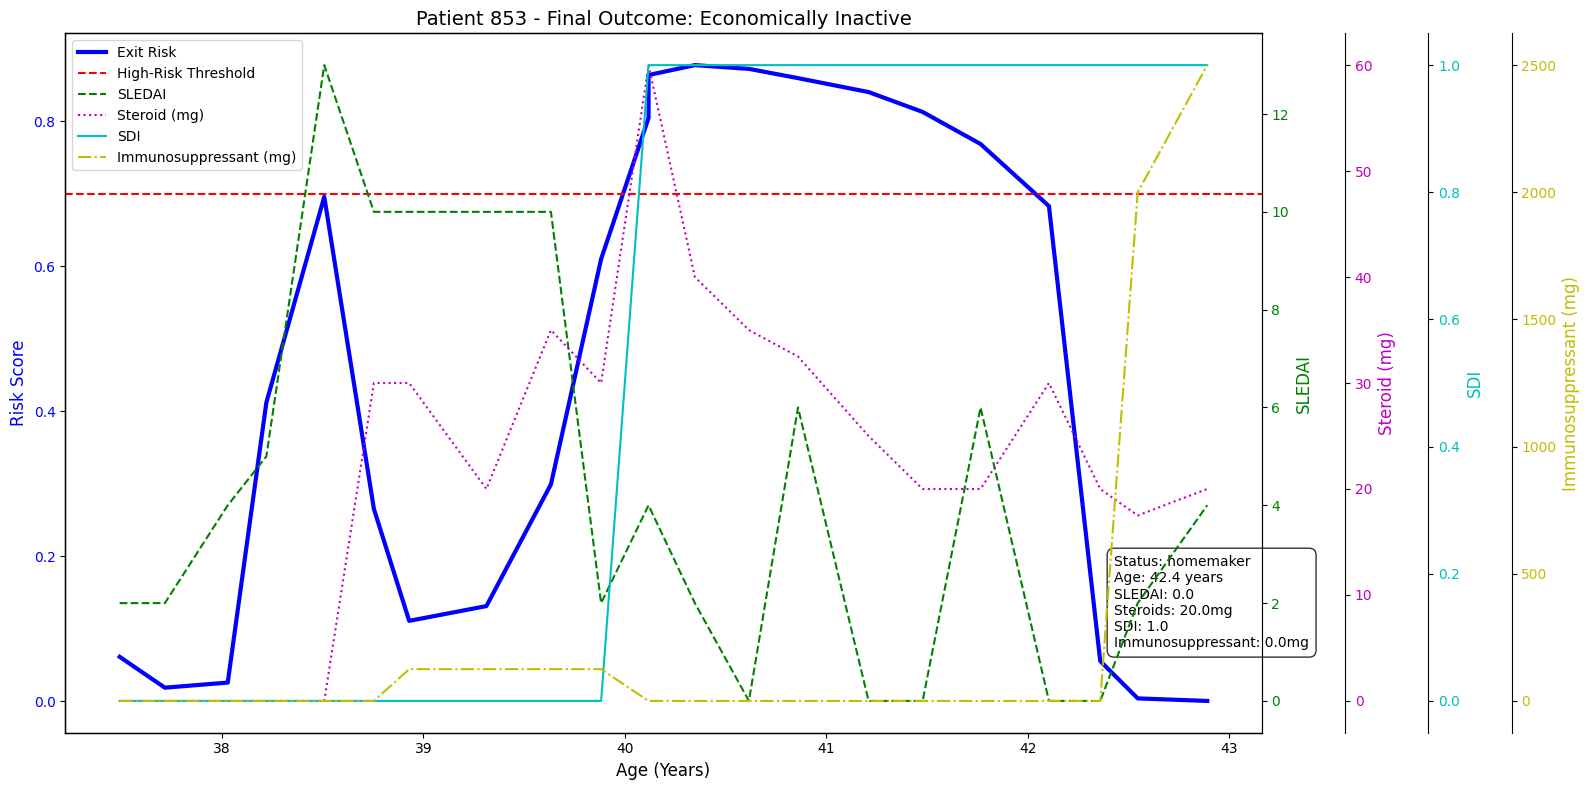

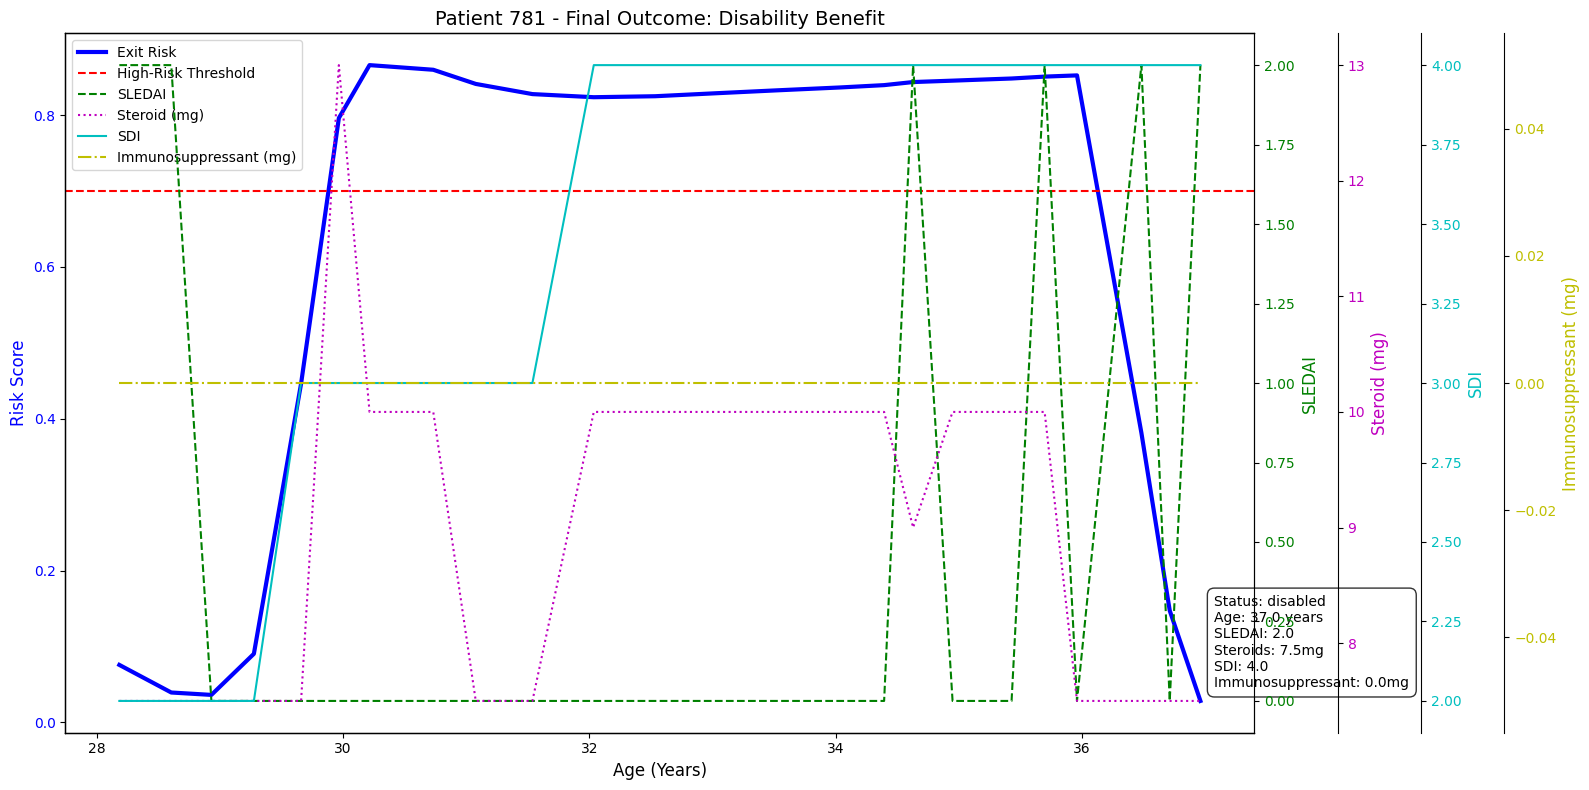

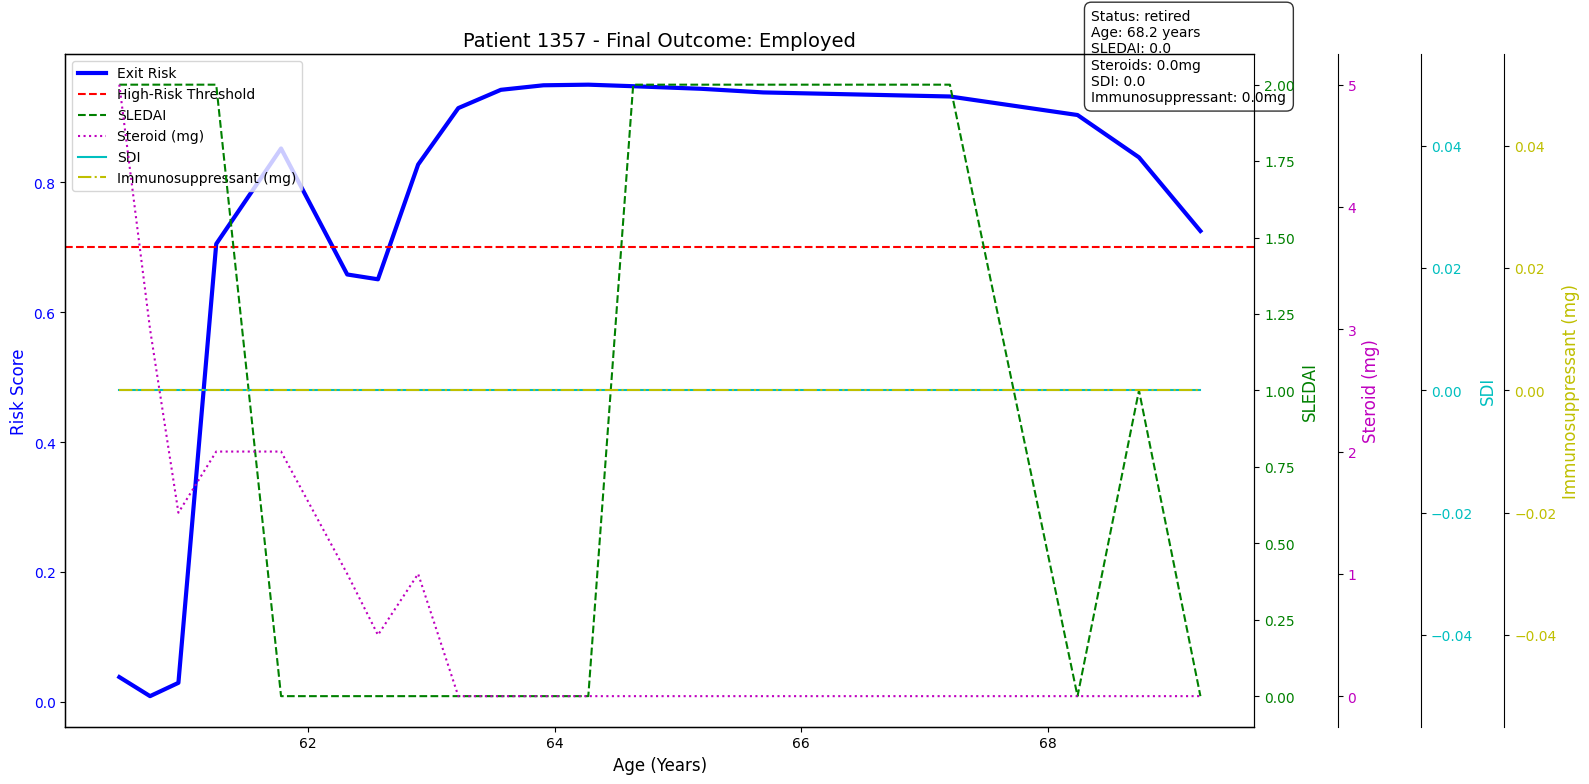

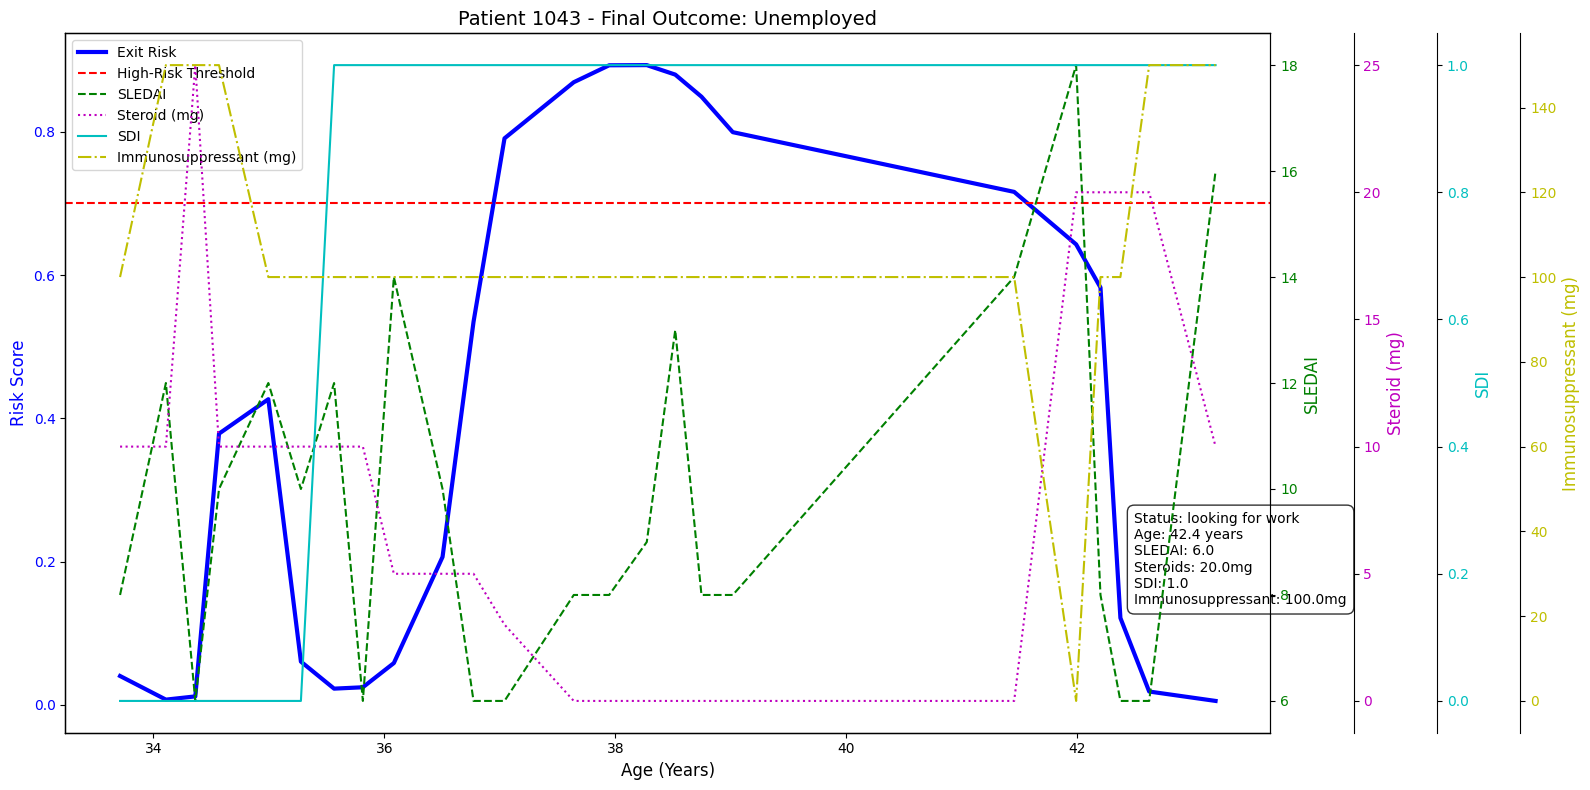

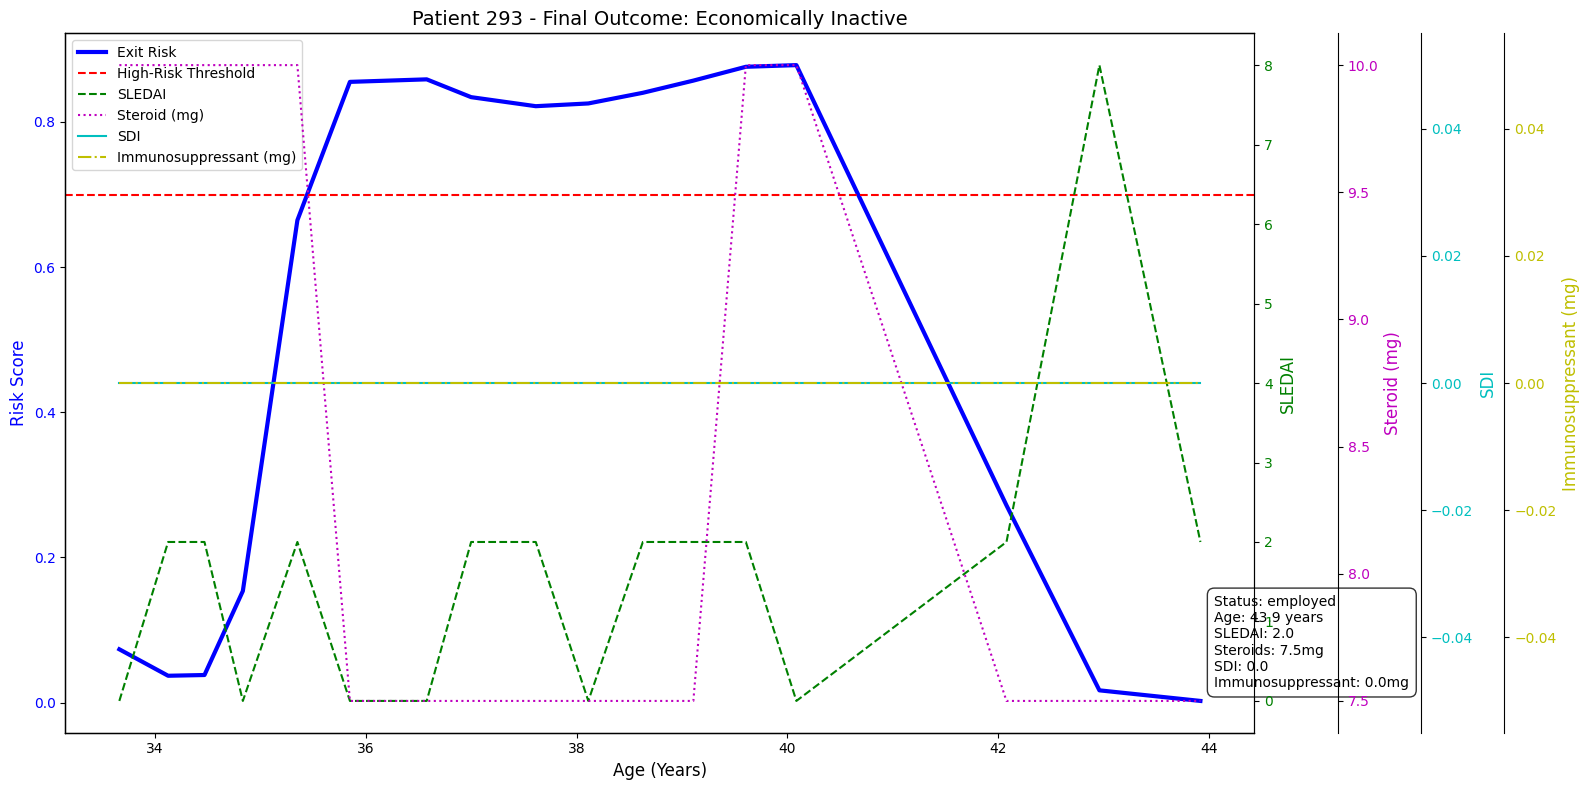

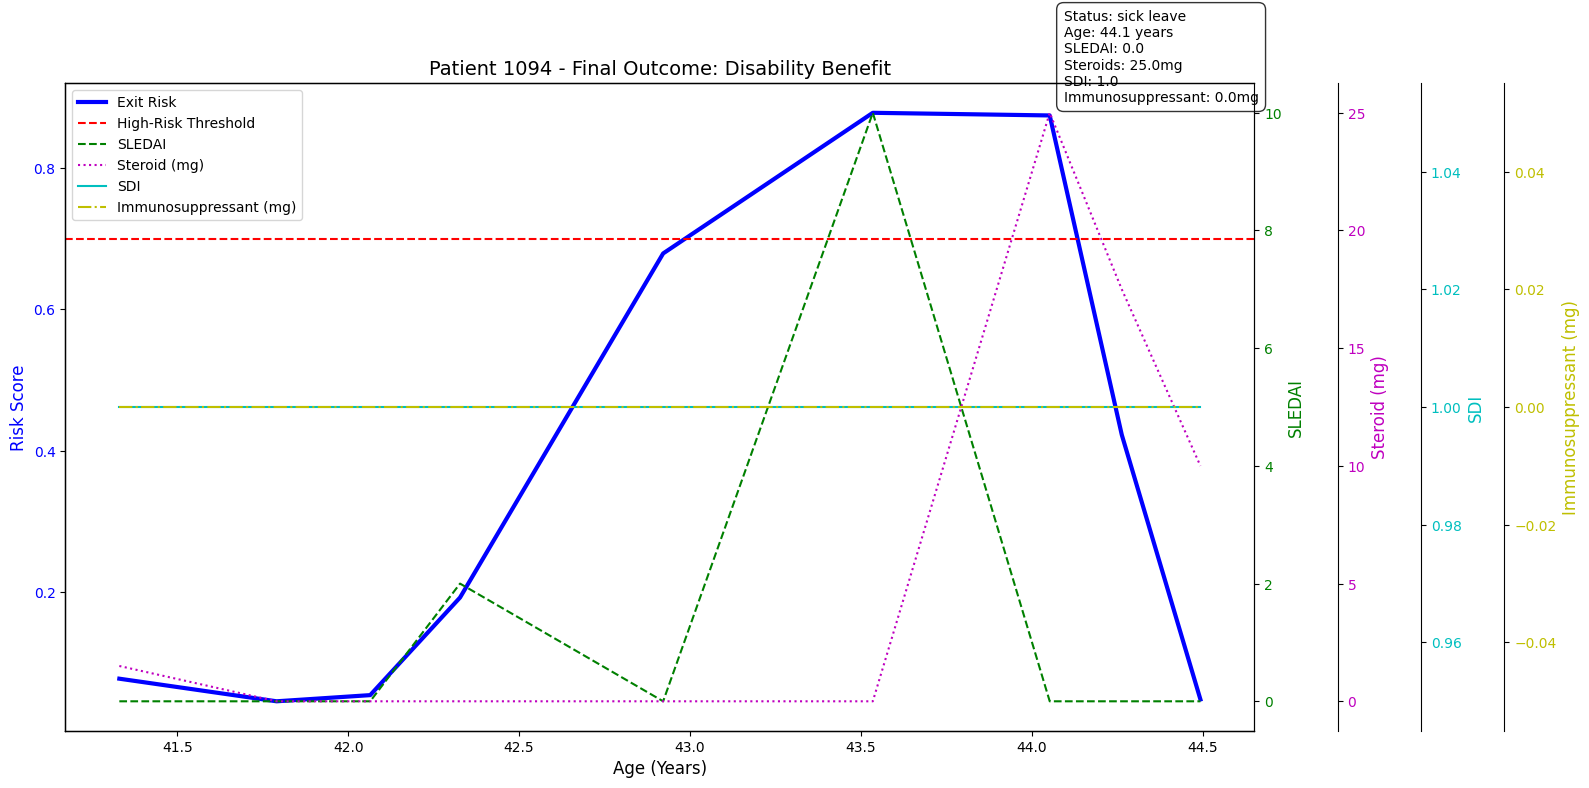

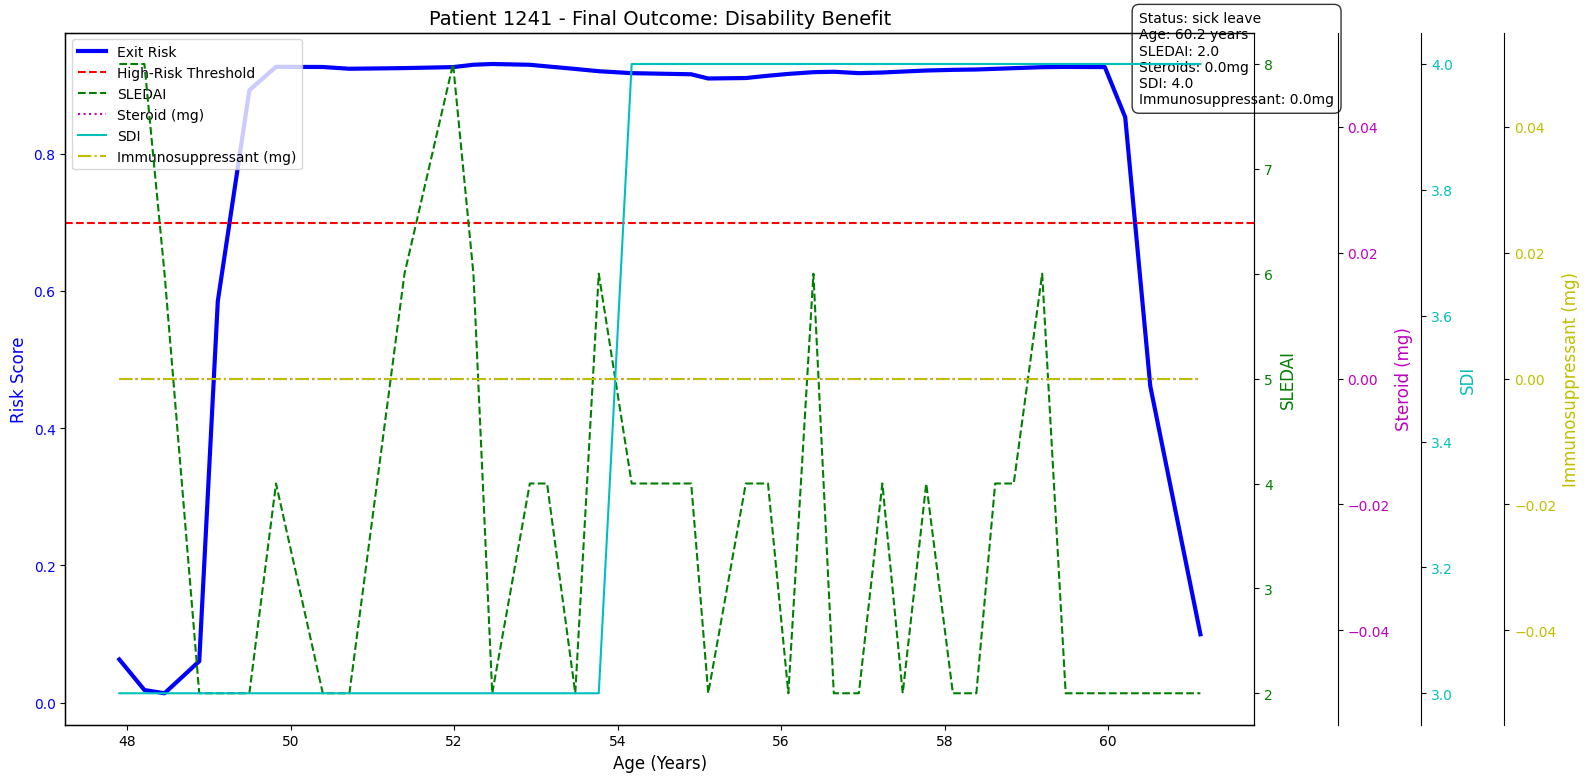

In [70]:
### Train Test Split
random.seed(365)
# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths



# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

random.seed(365)
# Corrected model training section
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Train the model with corrected class_weight
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict  # Use the computed weights
)

# Rest of your code remains the same...

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules
    THRESHOLD_RULES = [
        {'conditions': {'SLEDAI2_I': lambda x: x >= 6, 'STERDOSE': lambda x: x >= 7.5},
         'risk_threshold': 0.4},
        {'conditions': {'ISDOSE': lambda x: x >= 100},
         'risk_threshold': 0.35},
        {'conditions': {'EMPf': lambda x: 'unemployed' in x.lower()},
         'risk_threshold': 0.3},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prioritize warnings closer to employment change
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            # Only include warnings within 5 years of exit
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'SLEDAI_at_Warning': best_warning['context']['SLEDAI2_I'],
                    'Steroid_at_Warning': best_warning['context']['STERDOSE'],
                    'SDI_at_Warning': best_warning['context']['score_n'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'Very_High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] > 30])/len(high_risk_df):.0%} on >30mg prednisone",
            'High_ISDOSE': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 100])/len(high_risk_df):.0%} on high ISDOSE (≥100mg)",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Trigger_Types': {
            'Risk_Score_Only': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Risk_Score'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A",
            'Clinical_Deterioration': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Clinical_Deterioration'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Plot a patient's risk score and clinical markers with age on x-axis"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age at each assessment
    patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = (risk_df['ASSDT'] - patient_data['BIRTHDT'].iloc[0]).dt.days / 365.25
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure with larger width to accommodate multiple axes
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Plot risk score (left axis) with age on x-axis
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_ylim(0, 1)  # Force risk score axis to start at 0 and end at 1
    
    # Create temporary array for inverse transform
    temp_array = np.zeros((len(risk_df), len(features)))
    
    # Fill with scaled values
    temp_array[:, feature_pos['SLEDAI2_I']] = risk_df['SLEDAI']
    temp_array[:, feature_pos['STERDOSE']] = risk_df['Steroid_Dose']
    temp_array[:, feature_pos['score_n']] = risk_df['SDI']
    temp_array[:, feature_pos['ISDOSE']] = risk_df['Immunosuppressant']
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract unscaled values
    risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos['SLEDAI2_I']]
    risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos['STERDOSE']]
    risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos['score_n']]
    risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos['ISDOSE']]
    
    # Define colors and styles for each clinical marker
    clinical_markers = {
        'SLEDAI': ('g', '--'),
        'Steroid (mg)': ('m', ':'),
        'SDI': ('c', '-'),
        'Immunosuppressant (mg)': ('y', '-.')
    }
    
    # Create right axes for each clinical marker
    axes_right = {}
    offset = 60  # Pixel offset for each additional axis
    
    for i, (marker_name, (color, linestyle)) in enumerate(clinical_markers.items()):
        # Create new axis, offset from the previous one
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset * i))
        
        # Plot the clinical marker
        ax.plot(risk_df['Age'], risk_df[f'{marker_name.split(" ")[0]}_unscaled'], 
               color=color, linestyle=linestyle, label=marker_name)
        
        # Style the axis and set y-lim to start at 0
        ax.set_ylabel(marker_name, color=color, fontsize=12)
        ax.tick_params(axis='y', labelcolor=color)
        
        # Get the max value for this marker to set upper bound
        max_val = risk_df[f'{marker_name.split(" ")[0]}_unscaled'].max()
        buffer = max_val * 0.1  # Add 10% buffer above max value
        ax.set_ylim(0, max_val + buffer)
        
        # Store the axis for later reference
        axes_right[marker_name] = ax
    
    # Find point where employment status changes
    status_changes = risk_df['Employment_Status'].ne(risk_df['Employment_Status'].shift())
    if status_changes.any():
        change_point = risk_df[status_changes].iloc[-1]  # Get last status change
        label = (f"Status: {change_point['Employment_Status']}\n"
                f"Age: {change_point['Age']:.1f} years\n"
                f"SLEDAI: {change_point['SLEDAI_unscaled']:.1f}\n"
                f"Steroids: {change_point['Steroid_unscaled']:.1f}mg\n"
                f"SDI: {change_point['SDI_unscaled']:.1f}\n"
                f"Immunosuppressant: {change_point['Immunosuppressant_unscaled']:.1f}mg")
        
        ax1.annotate(label, 
                    (change_point['Age'], change_point['Risk_Score']),
                    textcoords="offset points", 
                    xytext=(10,10), 
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}', fontsize=14)
    
    # Combine legends from all axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for ax in axes_right.values():
        lines, labels = ax.get_legend_handles_labels()
        lines_right.extend(lines)
        labels_right.extend(labels)
    
    ax1.legend(lines1 + lines_right, labels1 + labels_right, loc='upper left')
    
    plt.tight_layout()
    plt.show()

data['BIRTHDT'] = pd.to_datetime(data['BIRTHDT'])
# Print patients with final state "Disability Benefit"
# -------------------
high_risk_df = get_high_risk_patients(model, data, features)


# Execute the analysis with age on x-axis
# -------------------
# Generate clinical report with all predictors
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(10, len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)


In [71]:
def evaluate_flagging_performance(high_risk_df, data):
    """Evaluate how well the flagging system performed across the entire dataset"""
    
    # 1. Analyze flagged patients
    flagged_stats = {
        'total_flagged': len(high_risk_df),
        'still_employed_when_flagged': high_risk_df['Employment_at_Warning'].str.contains('employed', case=False).sum(),
        'percentage_still_employed': high_risk_df['Employment_at_Warning'].str.contains('employed', case=False).mean(),
        'median_months_before_exit': high_risk_df['Months_Prior_to_Exit'].median(),
        'early_warnings': (high_risk_df['Months_Prior_to_Exit'] > 12).sum(),
        'imminent_warnings': (high_risk_df['Months_Prior_to_Exit'] <= 12).sum()
    }
    
    # 2. Analyze entire dataset
    all_patients = data.groupby('PTNO').last().reset_index()
    should_have_been_flagged = all_patients[~all_patients['EMPf'].str.contains('employed', case=False)]
    was_flagged = all_patients['PTNO'].isin(high_risk_df['PTNO'])
    
    # Calculate confusion matrix components
    true_positives = len(high_risk_df)
    false_positives = len(was_flagged[was_flagged & all_patients['EMPf'].str.contains('employed', case=False)])
    false_negatives = len(should_have_been_flagged) - true_positives
    true_negatives = len(all_patients) - (true_positives + false_positives + false_negatives)
    
    # Calculate performance metrics
    sensitivity = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    specificity = true_negatives / (true_negatives + false_positives) if (true_negatives + false_positives) > 0 else 0
    
    overall_stats = {
        'total_patients': len(all_patients),
        'should_have_been_flagged': len(should_have_been_flagged),
        'was_flagged': true_positives,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'true_negatives': true_negatives,
        'sensitivity': sensitivity,
        'precision': precision,
        'specificity': specificity,
        'flagging_rate': true_positives / len(should_have_been_flagged) if len(should_have_been_flagged) > 0 else 0,
        'false_positive_rate': false_positives / (len(all_patients) - len(should_have_been_flagged)) if (len(all_patients) - len(should_have_been_flagged)) > 0 else 0
    }
    
    return flagged_stats, overall_stats

# After generating high_risk_df
flagged_stats, overall_stats = evaluate_flagging_performance(high_risk_df, data)

# Print detailed flagging report
print("\n=== Flagging Performance Report ===")
print("\nFlagged Patients Summary:")
print(f"- Total flagged: {flagged_stats['total_flagged']}")
print(f"- Still employed when flagged: {flagged_stats['still_employed_when_flagged']} ({flagged_stats['percentage_still_employed']:.1%})")
print(f"- Median months before exit: {flagged_stats['median_months_before_exit']}")
print(f"- Early warnings (>12 months): {flagged_stats['early_warnings']}")
print(f"- Imminent warnings (≤12 months): {flagged_stats['imminent_warnings']}")

print("\nOverall Flagging Accuracy:")
print(f"- Total patients: {overall_stats['total_patients']}")
print(f"- Should have been flagged (not employed at end): {overall_stats['should_have_been_flagged']}")
print(f"- Correctly flagged (true positives): {overall_stats['was_flagged']}")
print(f"- False positives: {overall_stats['false_positives']}")
print(f"- False negatives: {overall_stats['false_negatives']}")
print(f"- Sensitivity (recall): {overall_stats['sensitivity']:.1%}")
print(f"- Precision: {overall_stats['precision']:.1%}")
print(f"- Specificity: {overall_stats['specificity']:.1%}")
print(f"- Flagging rate: {overall_stats['flagging_rate']:.1%}")
print(f"- False positive rate: {overall_stats['false_positive_rate']:.1%}")

# Add to clinical report
clinical_report['Flagging_Performance'] = {
    'Flagged_Patients': flagged_stats,
    'Overall_Accuracy': overall_stats
}


=== Flagging Performance Report ===

Flagged Patients Summary:
- Total flagged: 208
- Still employed when flagged: 92 (44.2%)
- Median months before exit: 7.0
- Early warnings (>12 months): 55
- Imminent warnings (≤12 months): 153

Overall Flagging Accuracy:
- Total patients: 1025
- Should have been flagged (not employed at end): 243
- Correctly flagged (true positives): 208
- False positives: 23
- False negatives: 35
- Sensitivity (recall): 85.6%
- Precision: 90.0%
- Specificity: 97.1%
- Flagging rate: 85.6%
- False positive rate: 2.9%


# CV


=== Fold 1/5 ===


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.2690 - loss: 1.7706 - val_accuracy: 0.0634 - val_loss: 1.7966
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.1345 - loss: 1.6427 - val_accuracy: 0.1024 - val_loss: 1.7965
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.4146 - loss: 1.5430 - val_accuracy: 0.7415 - val_loss: 1.7481
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 192ms/step - accuracy: 0.7150 - loss: 1.5893 - val_accuracy: 0.7220 - val_loss: 1.6911
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.7496 - loss: 1.5902 - val_accuracy: 0.7268 - val_loss: 1.5888
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.7412 - loss: 1.4945 - val_accuracy: 0.7463 - val_loss: 1.5395
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 0.7404 - loss: 1.5733 - val_accuracy: 0.7317 - val_loss: 1.4166
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 262ms/step - accuracy: 0.7642 - loss: 1.4543 - val_accuracy: 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 181ms/step - accuracy: 0.0368 - loss: 1.9531 - val_accuracy: 0.0732 - val_loss: 1.7982
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.1116 - loss: 1.7016 - val_accuracy: 0.0439 - val_loss: 1.7970
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.0881 - loss: 1.7385 - val_accuracy: 0.0976 - val_loss: 1.7916
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.1698 - loss: 1.6166 - val_accuracy: 0.3415 - val_loss: 1.7632
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.3157 - loss: 1.7804 - val_accuracy: 0.4927 - val_loss: 1.6909
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5231 - loss: 1.5341 - val_accuracy: 0.7415 - val_loss: 1.6128
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.5353 - loss: 1.7819 - val_accuracy: 0.7512 - val_loss: 1.5286
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.6743 - loss: 1.5936 - val_accuracy: 0.7610 - val_l

...

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.0351 - loss: 1.6387 - val_accuracy: 0.0390 - val_loss: 1.8145
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.0412 - loss: 1.7161 - val_accuracy: 0.1122 - val_loss: 1.8146
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.1235 - loss: 1.7749 - val_accuracy: 0.4634 - val_loss: 1.7680
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3863 - loss: 1.5823 - val_accuracy: 0.5854 - val_loss: 1.7418
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.5269 - loss: 1.8353 - val_accuracy: 0.7610 - val_loss: 1.7163
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.6525 - loss: 1.7147 - val_accuracy: 0.7707 - val_loss: 1.6878
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.6924 - loss: 1.5288 - val_accuracy: 0.7854 - val_loss: 1.6605
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.6989 - loss: 1.5343 - val_accuracy: 0.7659 - val_loss: 1

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.0592 - loss: 1.8187
Epoch 2/50
 2/33 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.0938 - loss: 1.4213 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.1015 - loss: 1.7781
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.4151 - loss: 1.5951
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.6478 - loss: 1.5958
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.7121 - loss: 1.6422
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6961 - loss: 1.5779
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.6499 - loss: 1.5965
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.7216 - loss: 1.5236
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.7183 - loss: 1.4790
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.7480 - loss: 1.5410
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.7046 - loss: 1.6521
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.7315 - loss: 1.3663
Epoch 13/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.7490 - 

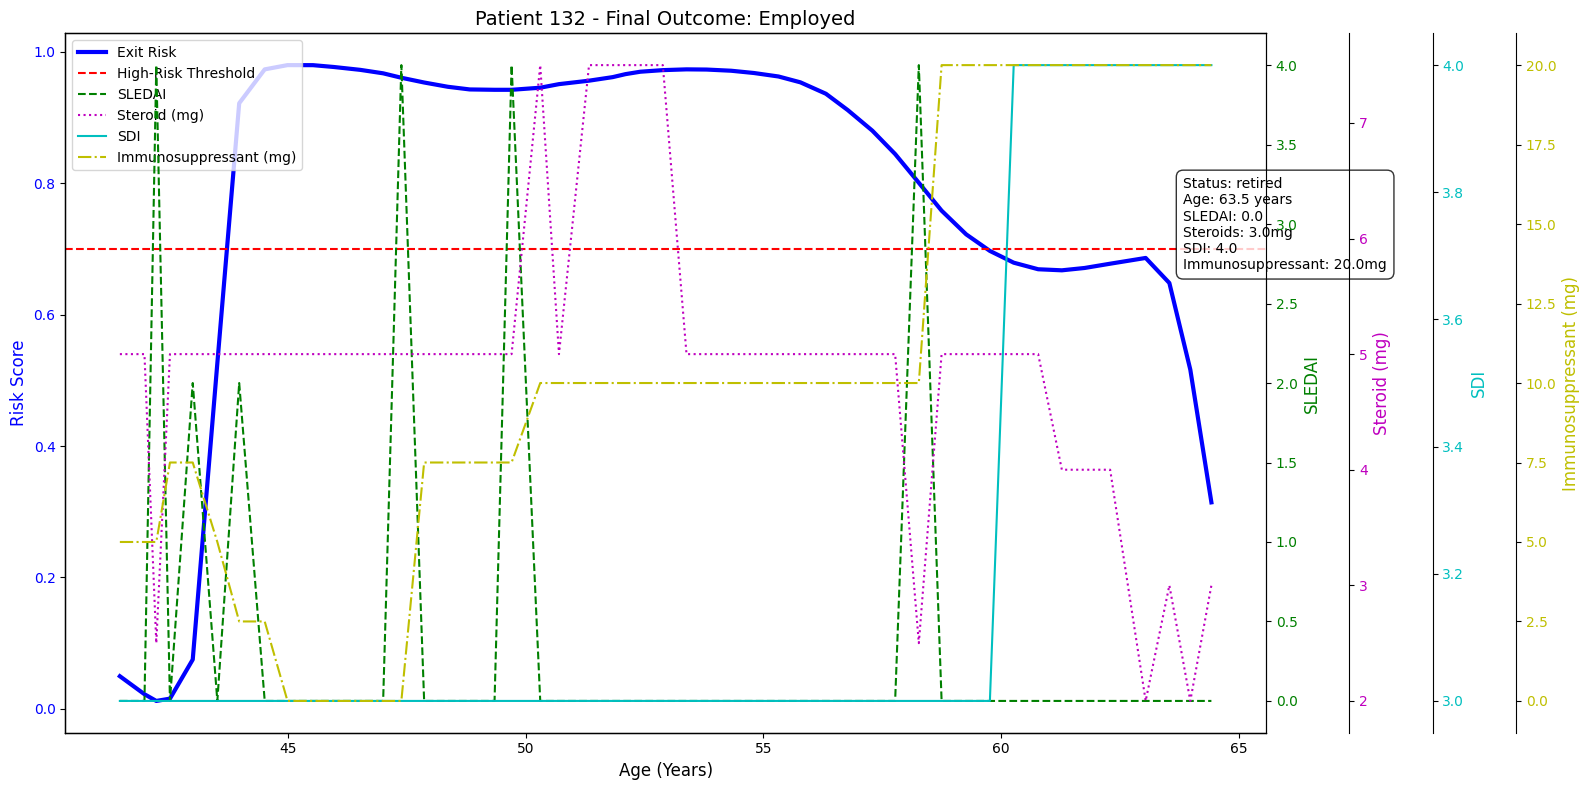

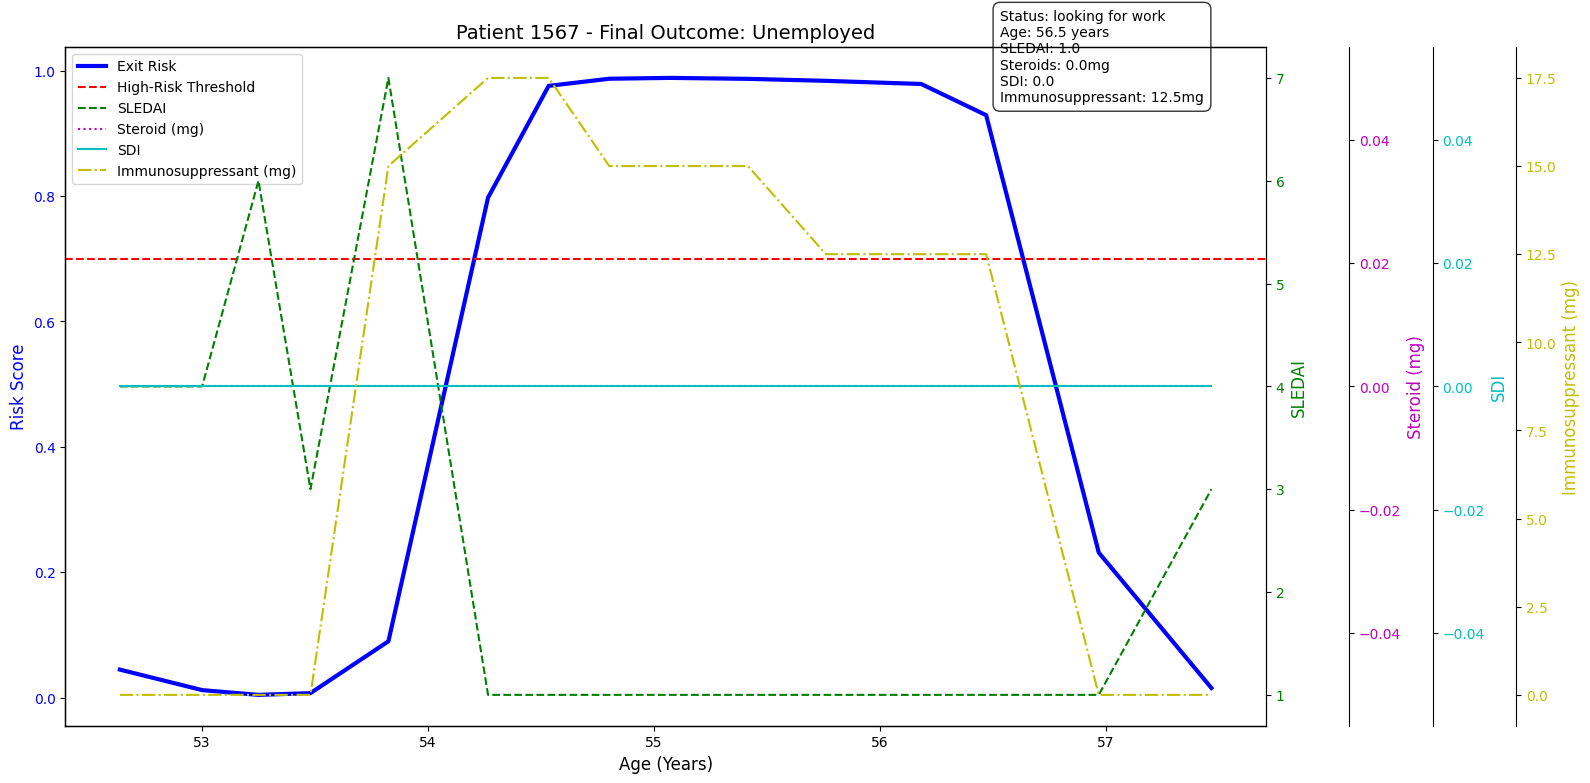

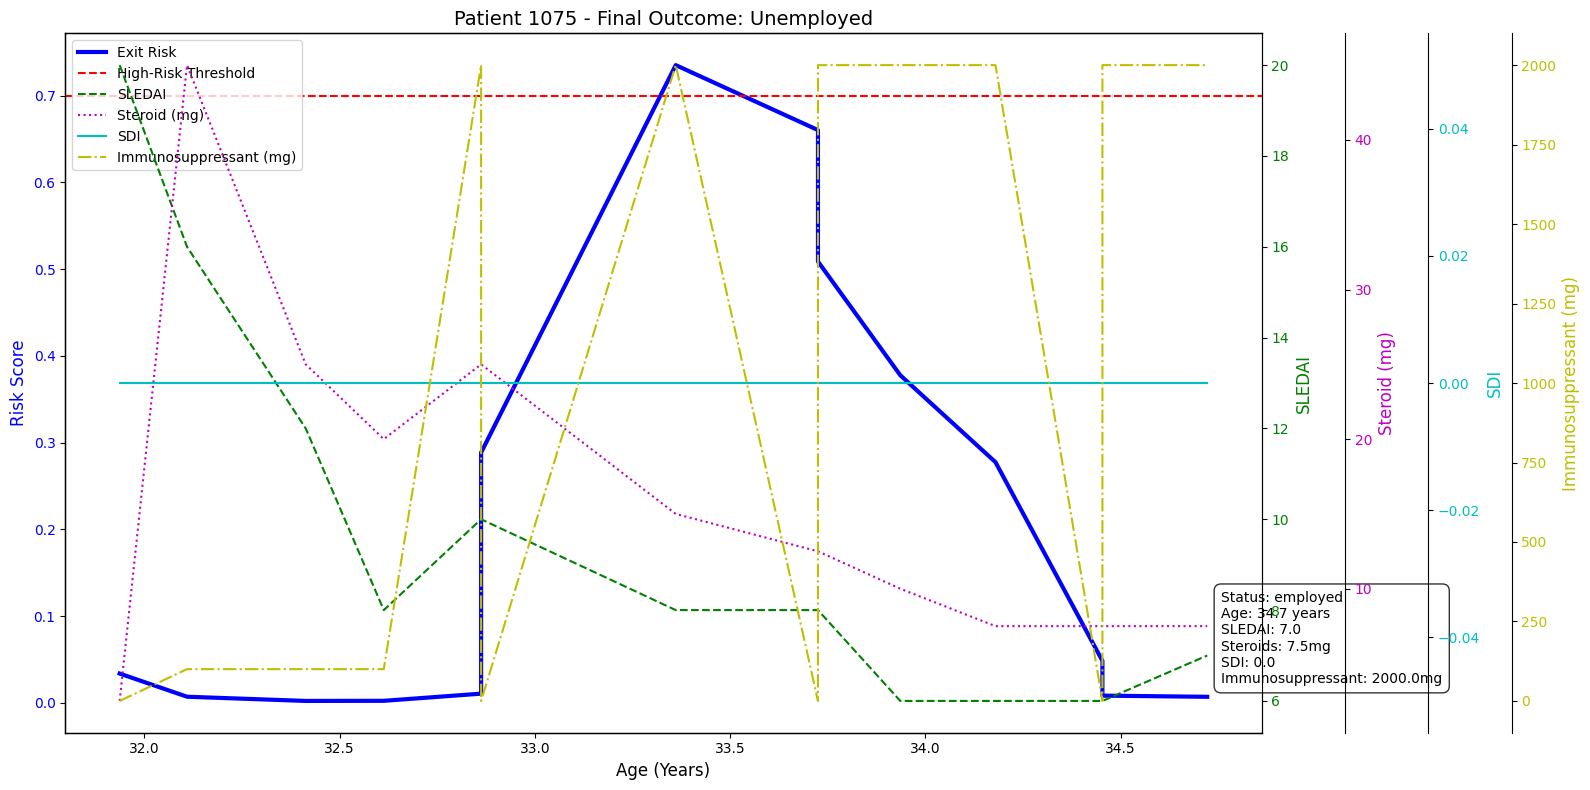

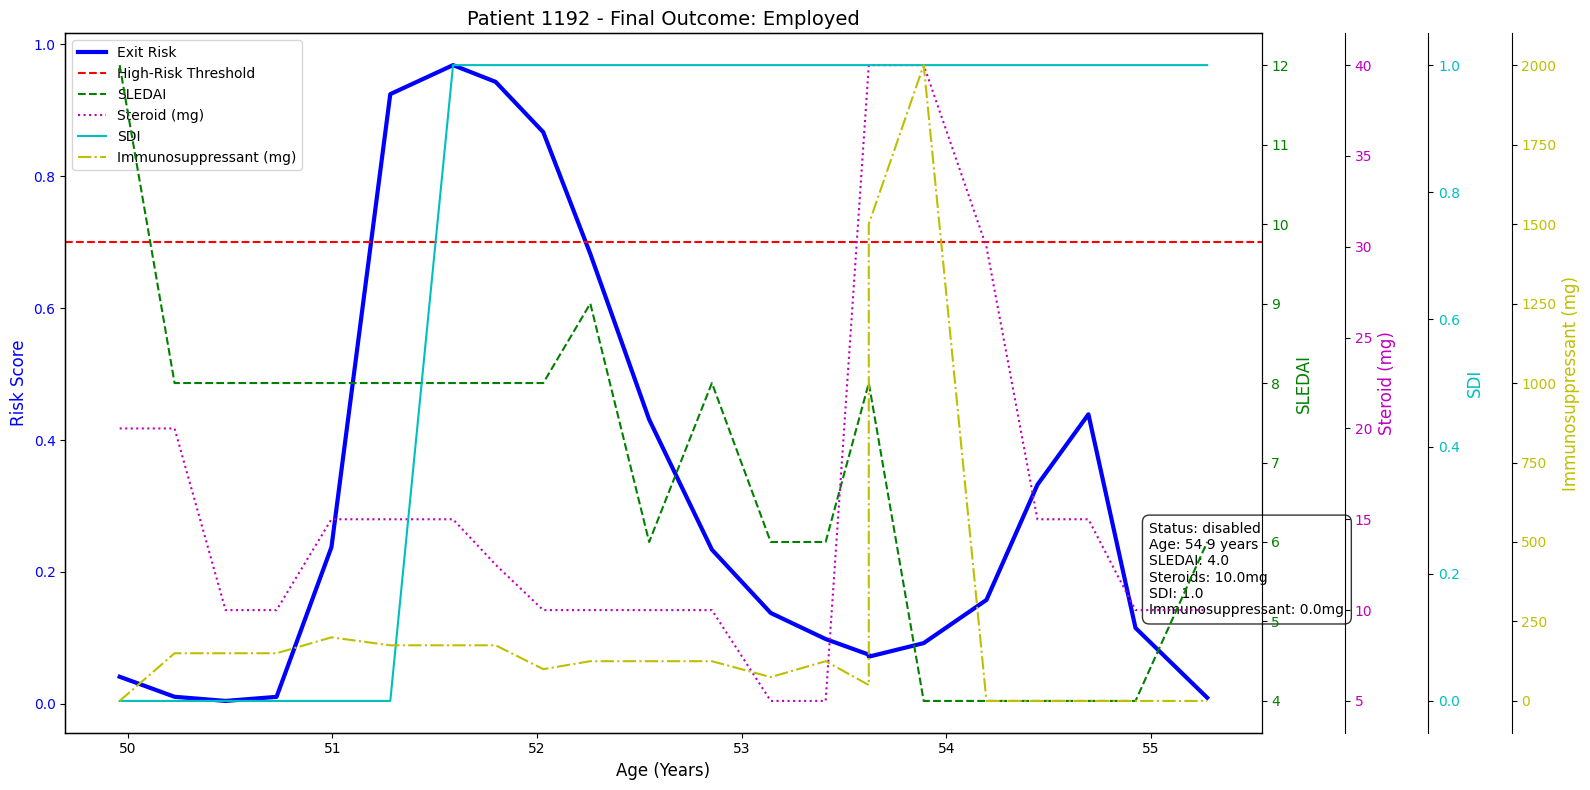

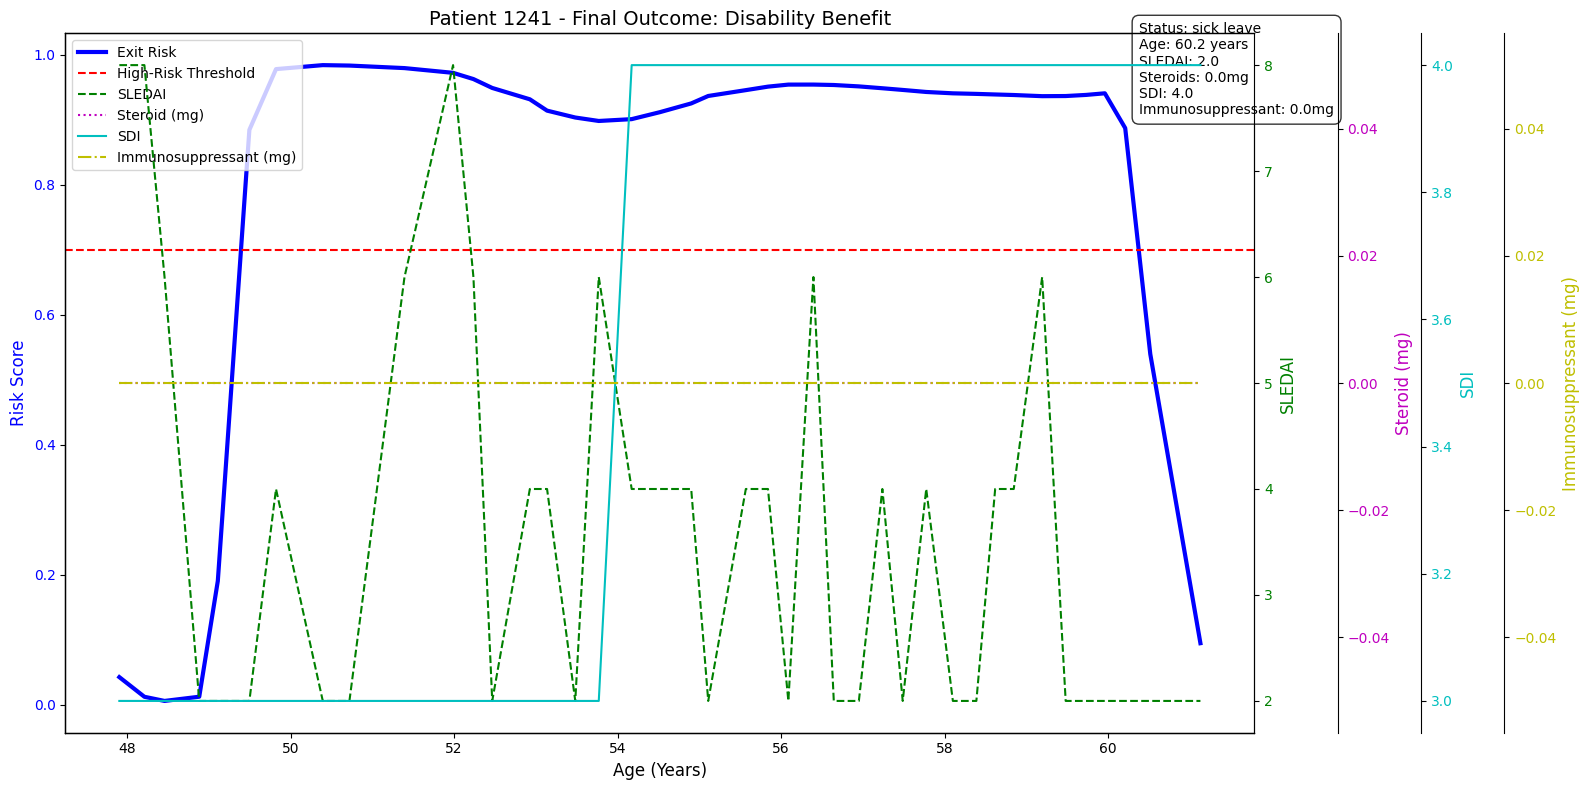

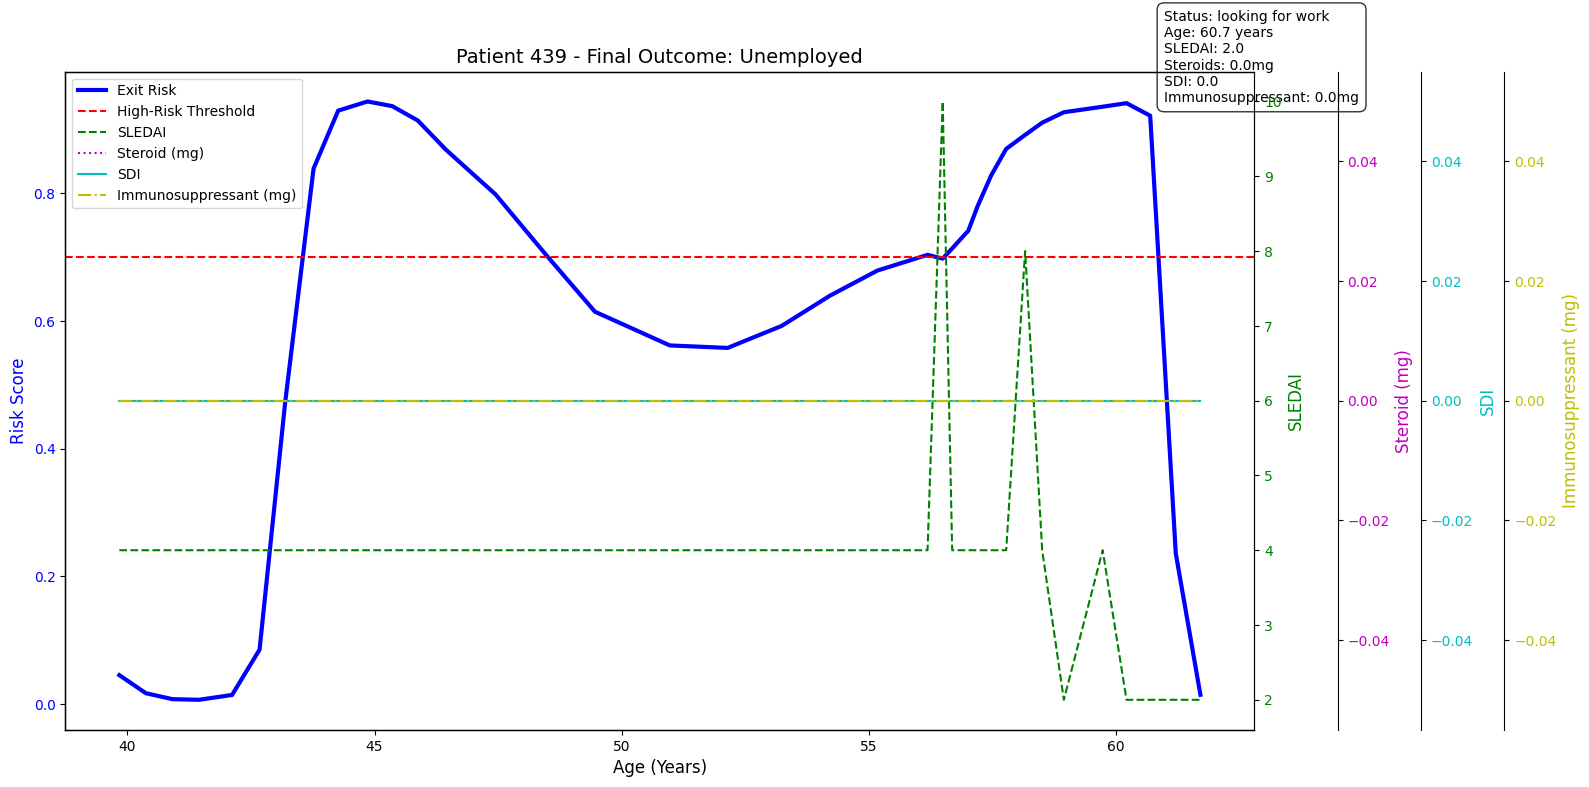

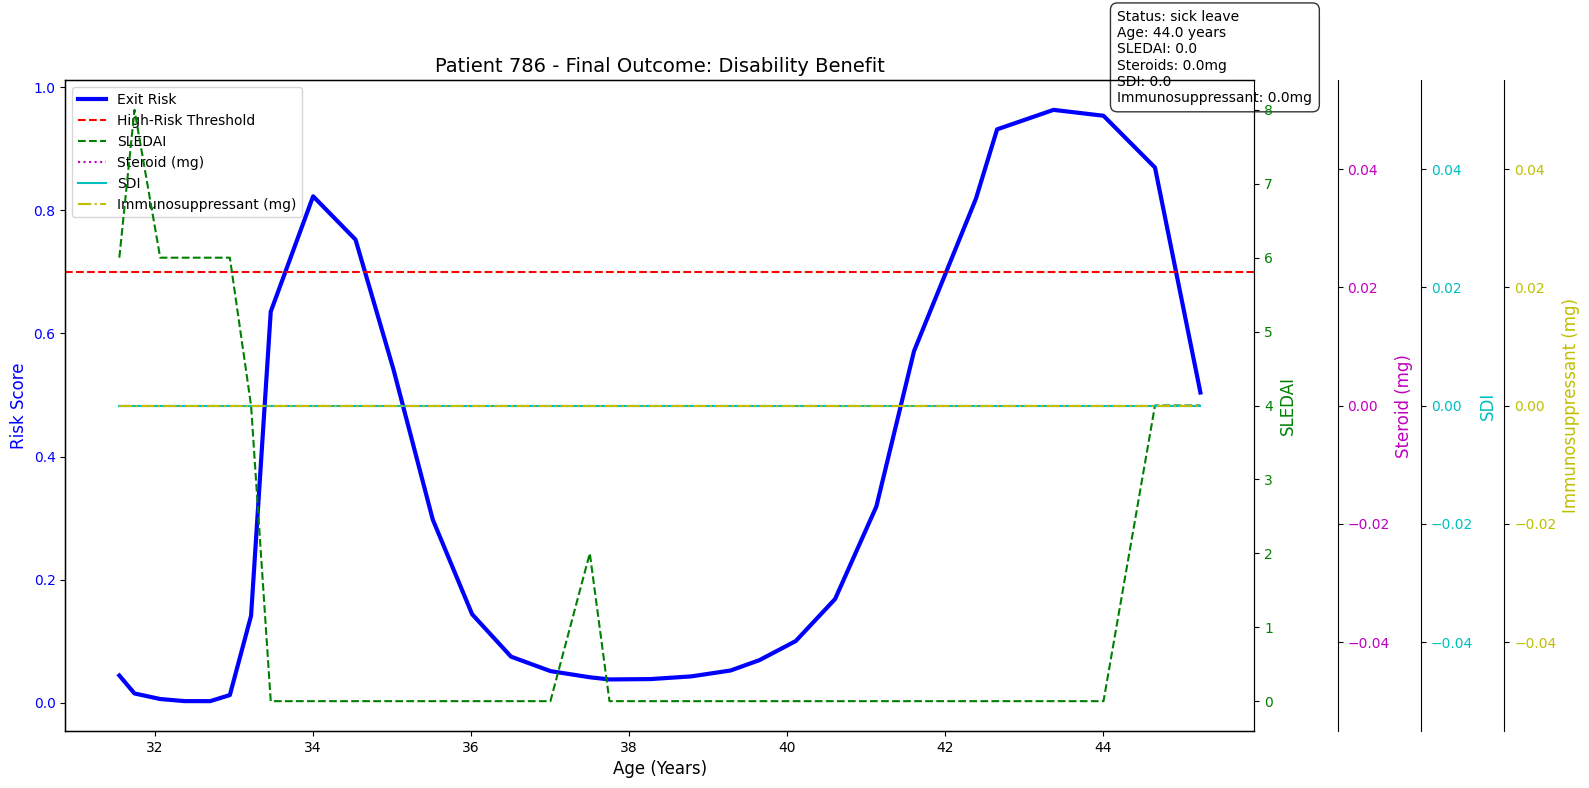

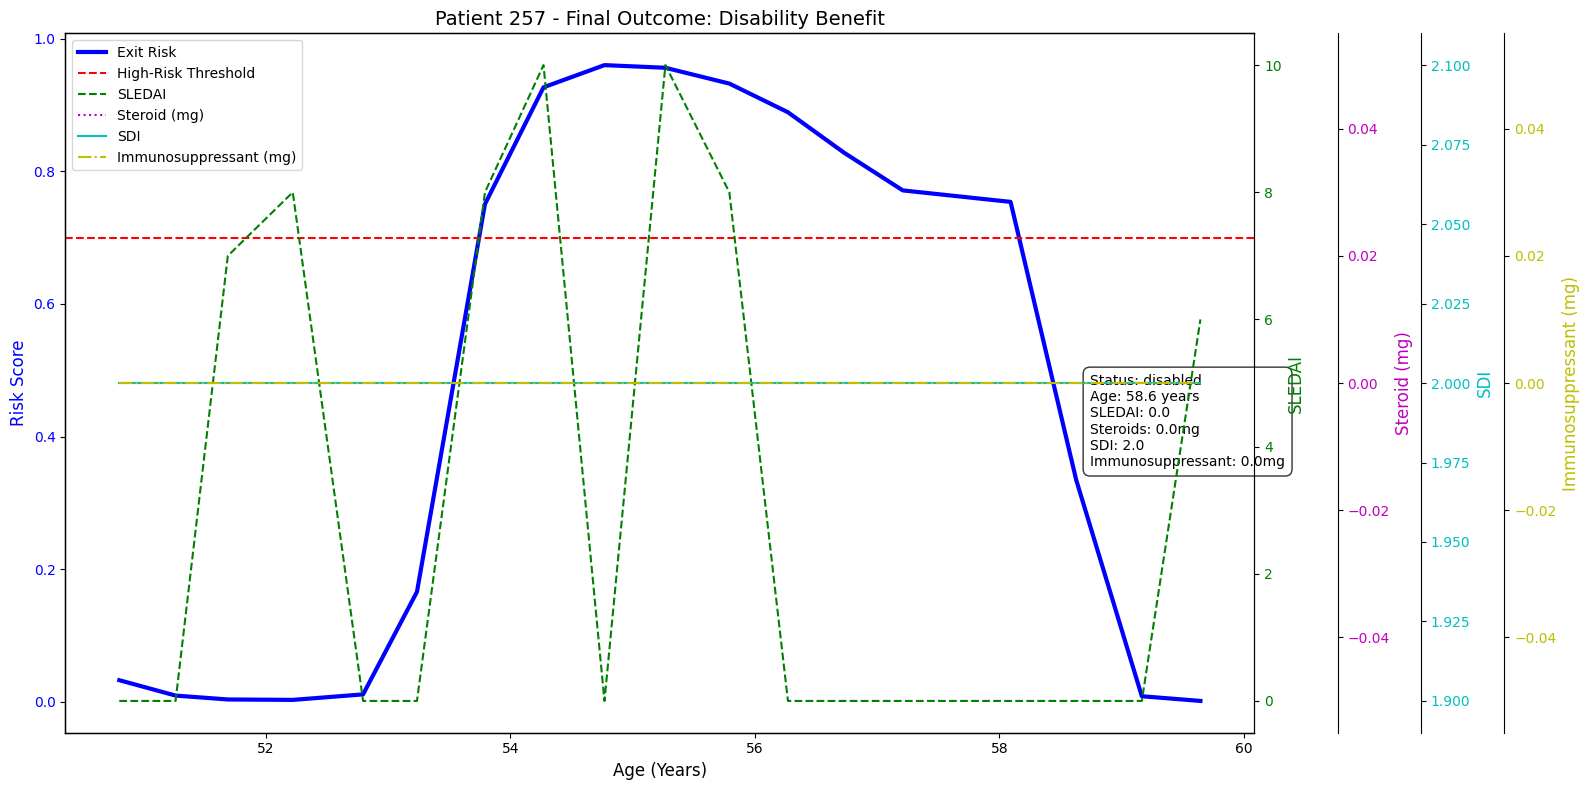

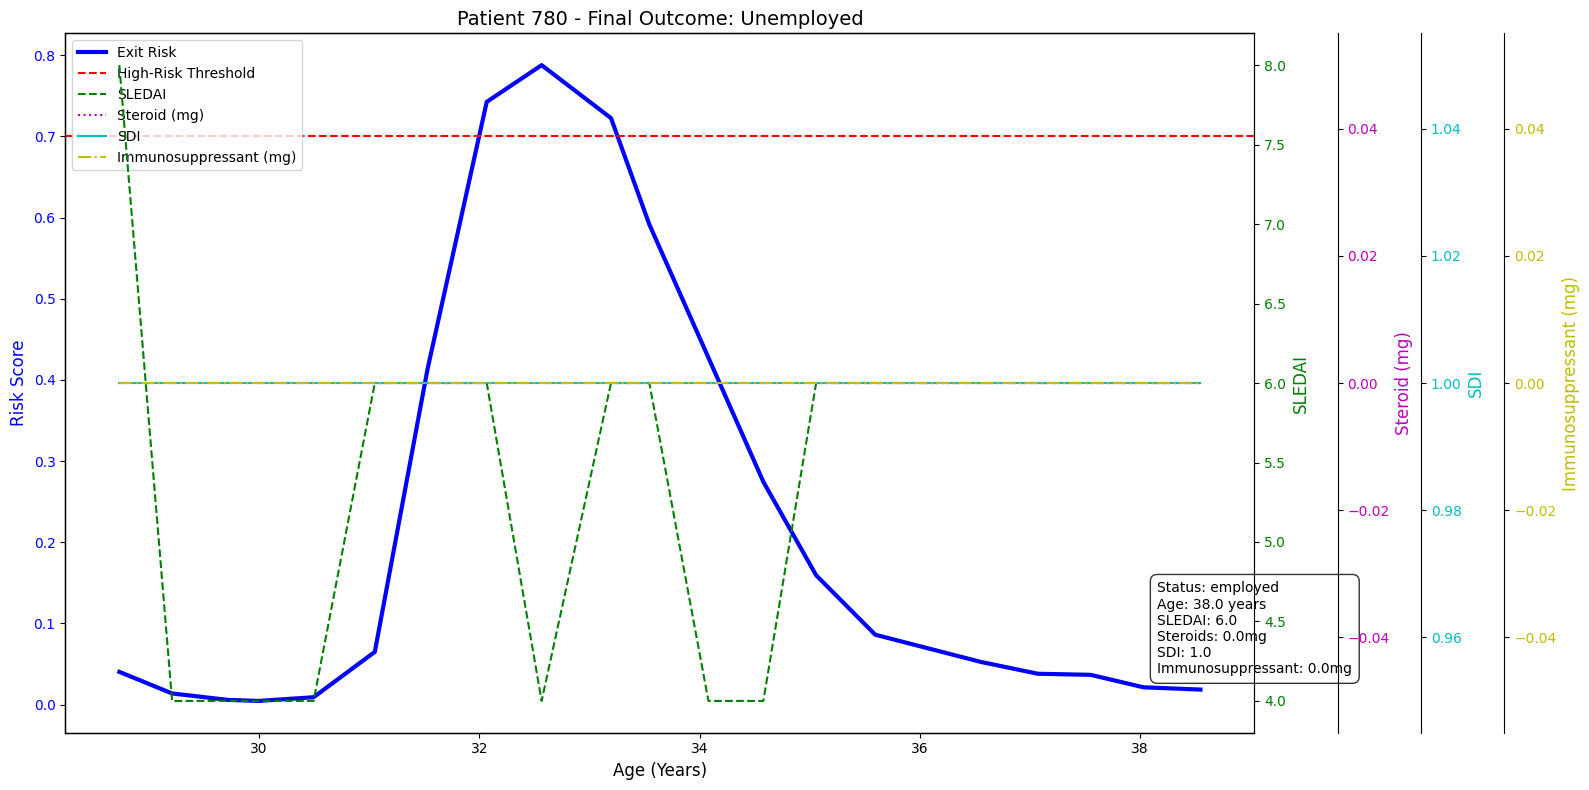

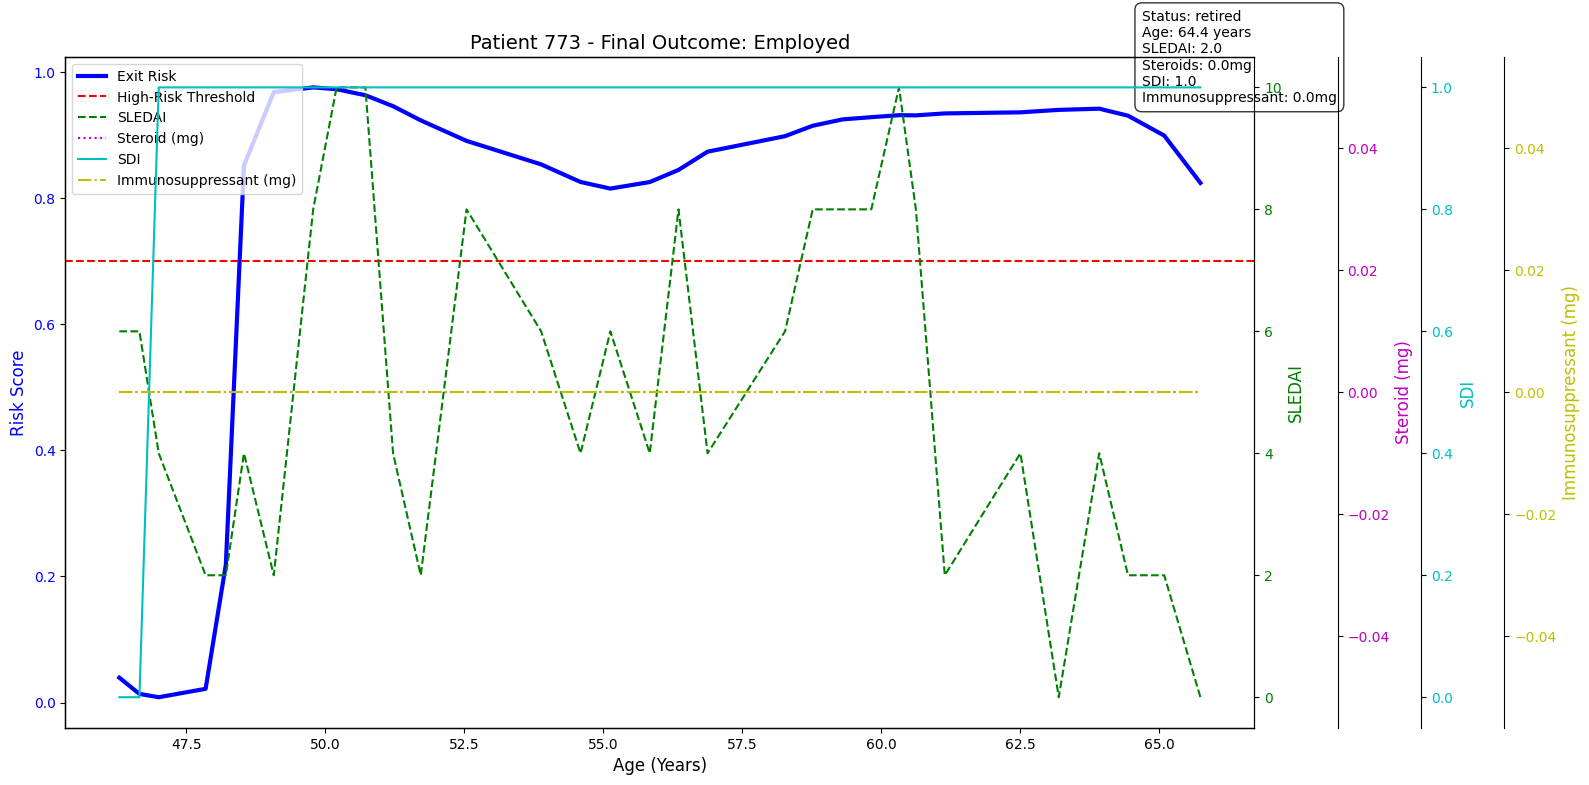

In [73]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import random

# Set random seeds for reproducibility
random.seed(365)
np.random.seed(365)

# Create sequences for each patient (same as before)
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Convert y back to class labels for stratified k-fold
y_labels = np.argmax(y, axis=1)

# Initialize k-fold cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
fold_results = []
histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_labels)):
    print(f"\n=== Fold {fold + 1}/{n_splits} ===")
    
    # Split data
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Calculate class weights for this fold
    y_integers = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Build LSTM model
    num_classes = y.shape[1]
    model = Sequential([
        Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    
    # Compile the model
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    
    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        batch_size=32,
        epochs=50,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # Store training history
    histories.append(history)
    
    # Evaluate on validation set
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation Accuracy: {val_acc:.4f}")
    
    # Predictions
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_val, axis=1)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(
        y_true_classes, 
        y_pred_classes, 
        target_names=label_encoder.classes_
    ))
    
    # Confusion matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_classes, y_pred_classes))
    
    # Store results
    fold_results.append({
        'fold': fold + 1,
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'classification_report': classification_report(
            y_true_classes, 
            y_pred_classes, 
            target_names=label_encoder.classes_,
            output_dict=True
        ),
        'confusion_matrix': confusion_matrix(y_true_classes, y_pred_classes)
    })

# Print cross-validation summary
print("\n=== Cross-Validation Summary ===")
for result in fold_results:
    print(f"Fold {result['fold']}: Val Accuracy = {result['val_accuracy']:.4f}")

mean_val_accuracy = np.mean([res['val_accuracy'] for res in fold_results])
print(f"\nMean Validation Accuracy: {mean_val_accuracy:.4f}")

# Optional: Train final model on all data
print("\nTraining final model on all data...")
y_integers = np.argmax(y, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

final_model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

final_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

final_model.fit(
    X, y,
    batch_size=32,
    epochs=50,
    callbacks=[early_stopping],
    class_weight=class_weight_dict
)


def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules
    THRESHOLD_RULES = [
        {'conditions': {'SLEDAI2_I': lambda x: x >= 6, 'STERDOSE': lambda x: x >= 7.5},
         'risk_threshold': 0.4},
        {'conditions': {'ISDOSE': lambda x: x >= 100},
         'risk_threshold': 0.35},
        {'conditions': {'EMPf': lambda x: 'unemployed' in x.lower()},
         'risk_threshold': 0.3},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prioritize warnings closer to employment change
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            # Only include warnings within 5 years of exit
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'SLEDAI_at_Warning': best_warning['context']['SLEDAI2_I'],
                    'Steroid_at_Warning': best_warning['context']['STERDOSE'],
                    'SDI_at_Warning': best_warning['context']['score_n'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'Very_High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] > 30])/len(high_risk_df):.0%} on >30mg prednisone",
            'High_ISDOSE': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 100])/len(high_risk_df):.0%} on high ISDOSE (≥100mg)",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Trigger_Types': {
            'Risk_Score_Only': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Risk_Score'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A",
            'Clinical_Deterioration': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Clinical_Deterioration'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Plot a patient's risk score and clinical markers with age on x-axis"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age at each assessment
    patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = (risk_df['ASSDT'] - patient_data['BIRTHDT'].iloc[0]).dt.days / 365.25
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure with larger width to accommodate multiple axes
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Plot risk score (left axis) with age on x-axis
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # Create temporary array for inverse transform
    temp_array = np.zeros((len(risk_df), len(features)))
    
    # Fill with scaled values
    temp_array[:, feature_pos['SLEDAI2_I']] = risk_df['SLEDAI']
    temp_array[:, feature_pos['STERDOSE']] = risk_df['Steroid_Dose']
    temp_array[:, feature_pos['score_n']] = risk_df['SDI']
    temp_array[:, feature_pos['ISDOSE']] = risk_df['Immunosuppressant']
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract unscaled values
    risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos['SLEDAI2_I']]
    risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos['STERDOSE']]
    risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos['score_n']]
    risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos['ISDOSE']]
    
    # Define colors and styles for each clinical marker
    clinical_markers = {
        'SLEDAI': ('g', '--'),
        'Steroid (mg)': ('m', ':'),
        'SDI': ('c', '-'),
        'Immunosuppressant (mg)': ('y', '-.')
    }
    
    # Create right axes for each clinical marker
    axes_right = {}
    offset = 60  # Pixel offset for each additional axis
    
    for i, (marker_name, (color, linestyle)) in enumerate(clinical_markers.items()):
        # Create new axis, offset from the previous one
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset * i))
        
        # Plot the clinical marker
        ax.plot(risk_df['Age'], risk_df[f'{marker_name.split(" ")[0]}_unscaled'], 
               color=color, linestyle=linestyle, label=marker_name)
        
        # Style the axis
        ax.set_ylabel(marker_name, color=color, fontsize=12)
        ax.tick_params(axis='y', labelcolor=color)
        
        # Store the axis for later reference
        axes_right[marker_name] = ax
    
    # Find point where employment status changes
    status_changes = risk_df['Employment_Status'].ne(risk_df['Employment_Status'].shift())
    if status_changes.any():
        change_point = risk_df[status_changes].iloc[-1]  # Get last status change
        label = (f"Status: {change_point['Employment_Status']}\n"
                f"Age: {change_point['Age']:.1f} years\n"
                f"SLEDAI: {change_point['SLEDAI_unscaled']:.1f}\n"
                f"Steroids: {change_point['Steroid_unscaled']:.1f}mg\n"
                f"SDI: {change_point['SDI_unscaled']:.1f}\n"
                f"Immunosuppressant: {change_point['Immunosuppressant_unscaled']:.1f}mg")
        
        ax1.annotate(label, 
                    (change_point['Age'], change_point['Risk_Score']),
                    textcoords="offset points", 
                    xytext=(10,10), 
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}', fontsize=14)
    
    # Combine legends from all axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for ax in axes_right.values():
        lines, labels = ax.get_legend_handles_labels()
        lines_right.extend(lines)
        labels_right.extend(labels)
    
    ax1.legend(lines1 + lines_right, labels1 + labels_right, loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
data['BIRTHDT'] = pd.to_datetime(data['BIRTHDT'])
# Print patients with final state "Disability Benefit"
# -------------------
high_risk_df = get_high_risk_patients(final_model, data, features)


# Execute the analysis with age on x-axis
# -------------------
# Generate clinical report with all predictors
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(10, len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, final_model, features, scaler)


In [74]:
def evaluate_flagging_performance(high_risk_df, data):
    """Evaluate how well the flagging system performed across the entire dataset"""
    
    # 1. Analyze flagged patients
    flagged_stats = {
        'total_flagged': len(high_risk_df),
        'still_employed_when_flagged': high_risk_df['Employment_at_Warning'].str.contains('employed', case=False).sum(),
        'percentage_still_employed': high_risk_df['Employment_at_Warning'].str.contains('employed', case=False).mean(),
        'median_months_before_exit': high_risk_df['Months_Prior_to_Exit'].median(),
        'early_warnings': (high_risk_df['Months_Prior_to_Exit'] > 12).sum(),
        'imminent_warnings': (high_risk_df['Months_Prior_to_Exit'] <= 12).sum()
    }
    
    # 2. Analyze entire dataset
    all_patients = data.groupby('PTNO').last().reset_index()
    should_have_been_flagged = all_patients[~all_patients['EMPf'].str.contains('employed', case=False)]
    was_flagged = all_patients['PTNO'].isin(high_risk_df['PTNO'])
    
    # Calculate confusion matrix components
    true_positives = len(high_risk_df)
    false_positives = len(was_flagged[was_flagged & all_patients['EMPf'].str.contains('employed', case=False)])
    false_negatives = len(should_have_been_flagged) - true_positives
    true_negatives = len(all_patients) - (true_positives + false_positives + false_negatives)
    
    # Calculate performance metrics
    sensitivity = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    specificity = true_negatives / (true_negatives + false_positives) if (true_negatives + false_positives) > 0 else 0
    
    overall_stats = {
        'total_patients': len(all_patients),
        'should_have_been_flagged': len(should_have_been_flagged),
        'was_flagged': true_positives,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'true_negatives': true_negatives,
        'sensitivity': sensitivity,
        'precision': precision,
        'specificity': specificity,
        'flagging_rate': true_positives / len(should_have_been_flagged) if len(should_have_been_flagged) > 0 else 0,
        'false_positive_rate': false_positives / (len(all_patients) - len(should_have_been_flagged)) if (len(all_patients) - len(should_have_been_flagged)) > 0 else 0
    }
    
    return flagged_stats, overall_stats

# After generating high_risk_df
flagged_stats, overall_stats = evaluate_flagging_performance(high_risk_df, data)

# Print detailed flagging report
print("\n=== Flagging Performance Report ===")
print("\nFlagged Patients Summary:")
print(f"- Total flagged: {flagged_stats['total_flagged']}")
print(f"- Still employed when flagged: {flagged_stats['still_employed_when_flagged']} ({flagged_stats['percentage_still_employed']:.1%})")
print(f"- Median months before exit: {flagged_stats['median_months_before_exit']}")
print(f"- Early warnings (>12 months): {flagged_stats['early_warnings']}")
print(f"- Imminent warnings (≤12 months): {flagged_stats['imminent_warnings']}")

print("\nOverall Flagging Accuracy:")
print(f"- Total patients: {overall_stats['total_patients']}")
print(f"- Should have been flagged (not employed at end): {overall_stats['should_have_been_flagged']}")
print(f"- Correctly flagged (true positives): {overall_stats['was_flagged']}")
print(f"- False positives: {overall_stats['false_positives']}")
print(f"- False negatives: {overall_stats['false_negatives']}")
print(f"- Sensitivity (recall): {overall_stats['sensitivity']:.1%}")
print(f"- Precision: {overall_stats['precision']:.1%}")
print(f"- Specificity: {overall_stats['specificity']:.1%}")
print(f"- Flagging rate: {overall_stats['flagging_rate']:.1%}")
print(f"- False positive rate: {overall_stats['false_positive_rate']:.1%}")

# Add to clinical report
clinical_report['Flagging_Performance'] = {
    'Flagged_Patients': flagged_stats,
    'Overall_Accuracy': overall_stats
}


=== Flagging Performance Report ===

Flagged Patients Summary:
- Total flagged: 179
- Still employed when flagged: 66 (36.9%)
- Median months before exit: 6.0
- Early warnings (>12 months): 47
- Imminent warnings (≤12 months): 132

Overall Flagging Accuracy:
- Total patients: 1025
- Should have been flagged (not employed at end): 243
- Correctly flagged (true positives): 179
- False positives: 20
- False negatives: 64
- Sensitivity (recall): 73.7%
- Precision: 89.9%
- Specificity: 97.4%
- Flagging rate: 73.7%
- False positive rate: 2.6%


# Sanity Check

In [85]:

# Load the data
data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])

# Sort by patient and assessment date
data = data.sort_values(['PTNO', 'ASSDT'])

# Calculate time differences
data['time_since_first'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: (x - x.min()).dt.days
)
data['time_since_last'] = data.groupby('PTNO')['ASSDT'].transform(
    lambda x: x.diff().dt.days.fillna(0)
)

# Convert categorical EMPf to numerical
emp_mapping = {v: k for k, v in enumerate(data['EMPf'].unique())}
data['EMP_numeric'] = data['EMPf'].map(emp_mapping)

# Encode the target (end_state)
label_encoder = LabelEncoder()
data['end_state_encoded'] = label_encoder.fit_transform(data['end_state'])

# Features to use
features = ['EMP_numeric', 'SLEDAI2_I', 'score_n', 'STERDOSE', 'ISDOSE', 'INCEPT',
            'AMDOSE', 'age_at_record', 'time_since_last', 
            'time_since_first', 'visit_num']

# Identify categorical columns (non-numeric)
categorical_cols = data[features].select_dtypes(include=['object', 'category']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))


# Fill NA values
data[features] = data[features].fillna(0)

# Normalize features
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths

# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/2470185762.py:2: DtypeWarning: Columns (94,127,136,143,145) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledataempl.csv', parse_dates=['ASSDT'])
/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/2470185762.py:3: DtypeWarning: Columns (124,126,133,135,142,144,149) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut.csv', parse_dates=['ASSDT'])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 194ms/step - accuracy: 0.2705 - loss: 1.6194 - val_accuracy: 0.1073 - val_loss: 1.7878
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.1958 - loss: 1.6535 - val_accuracy: 0.2293 - val_loss: 1.7930
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.3591 - loss: 1.6968 - val_accuracy: 0.7415 - val_loss: 1.6216
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.7094 - loss: 1.4956 - val_accuracy: 0.7463 - val_loss: 1.5070
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.7299 - loss: 1.4606 - val_accuracy: 0.7902 - val_loss: 1.2510
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.7540 - loss: 1.4719 - val_accuracy: 0.7610 - val_loss: 1.1425
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.7415 - loss: 1.3748 - val_accuracy: 0.7854 - val_loss: 1.0473
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.7102 - loss: 1.4122 - val_accuracy: 0

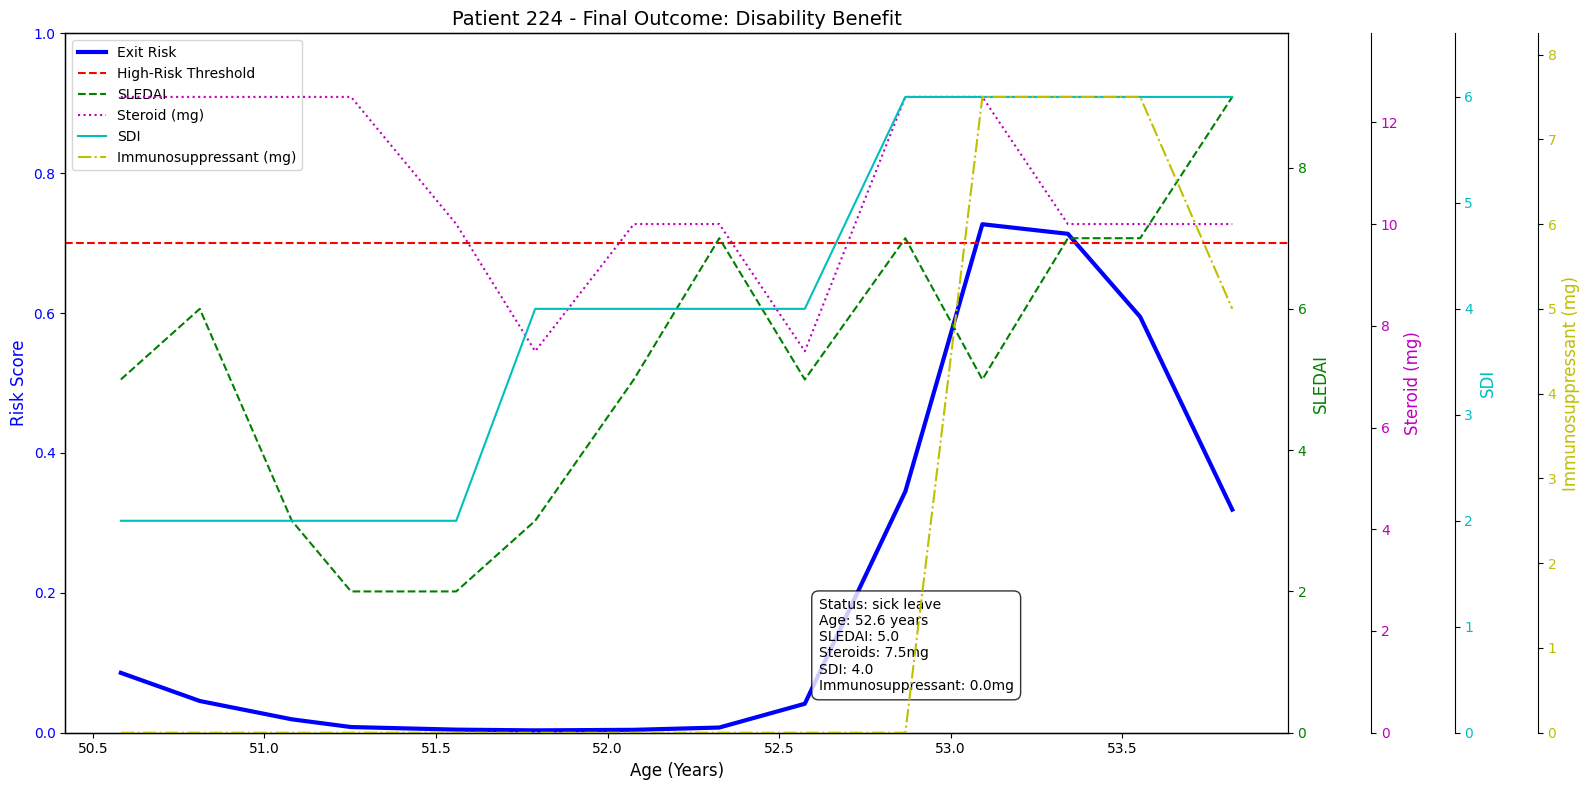

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3802051967.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


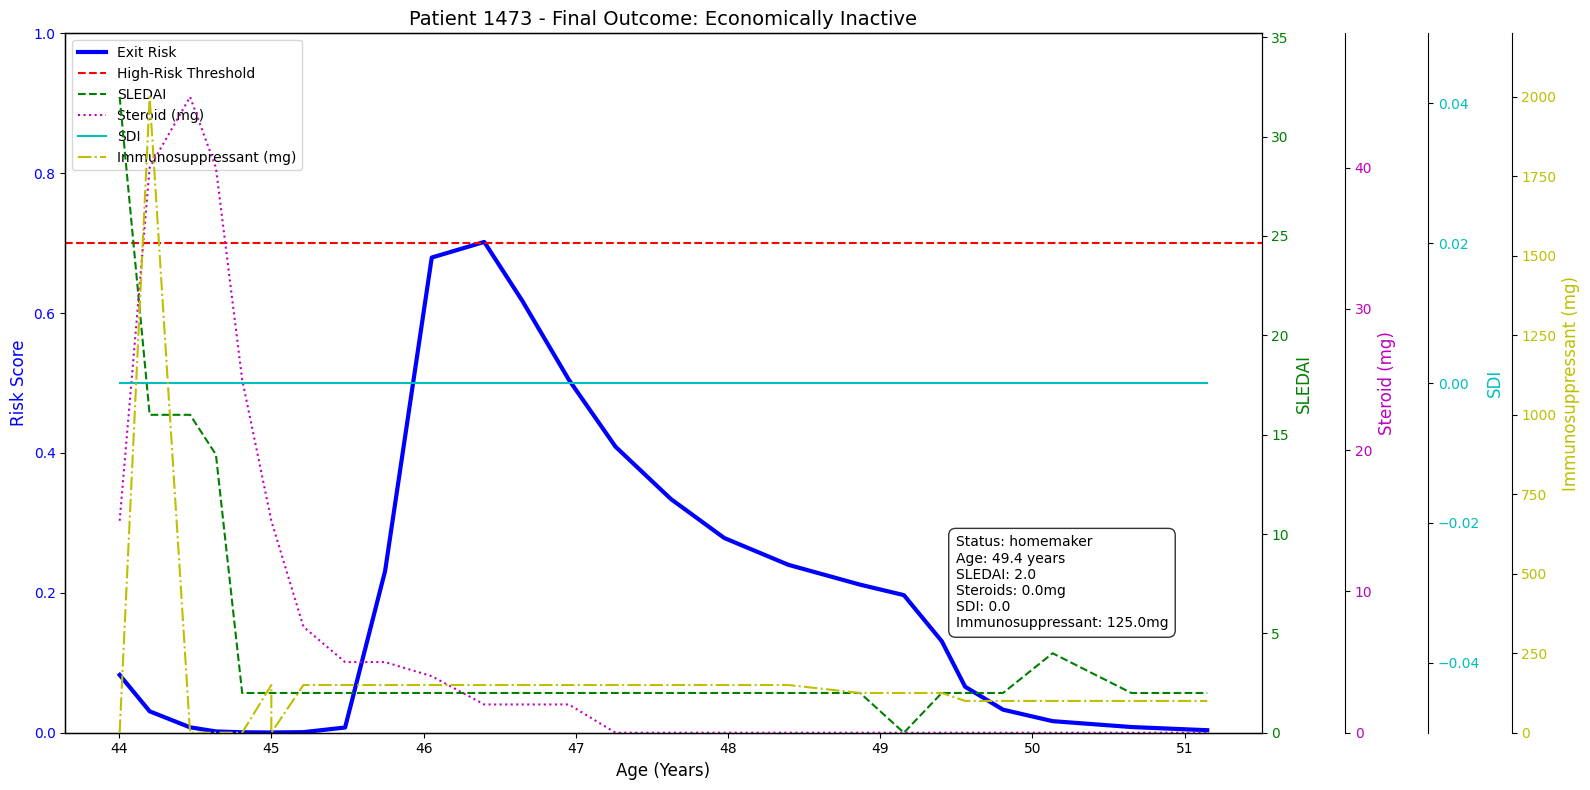

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3802051967.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


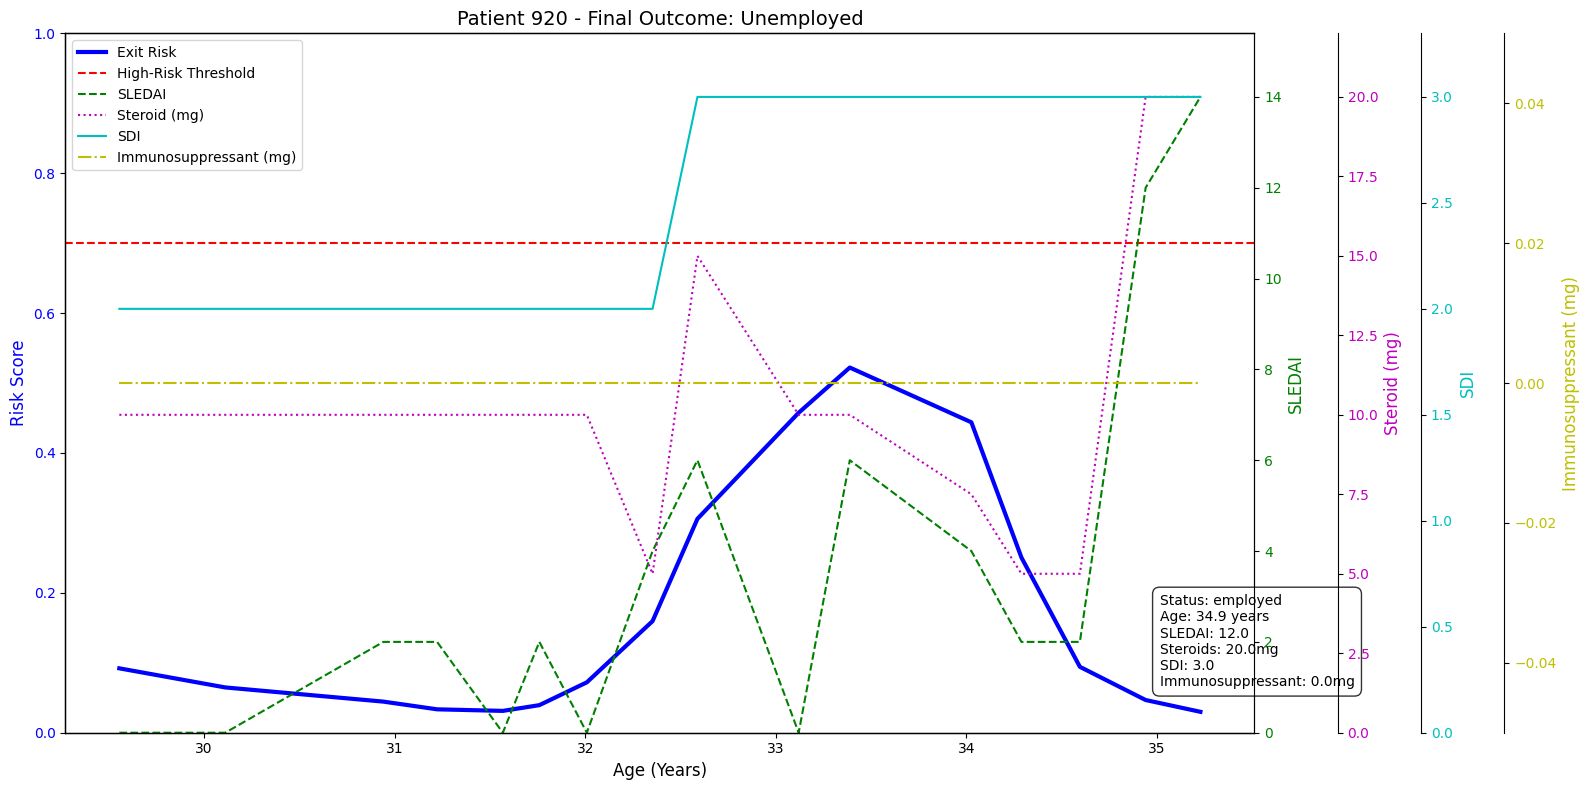

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3802051967.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


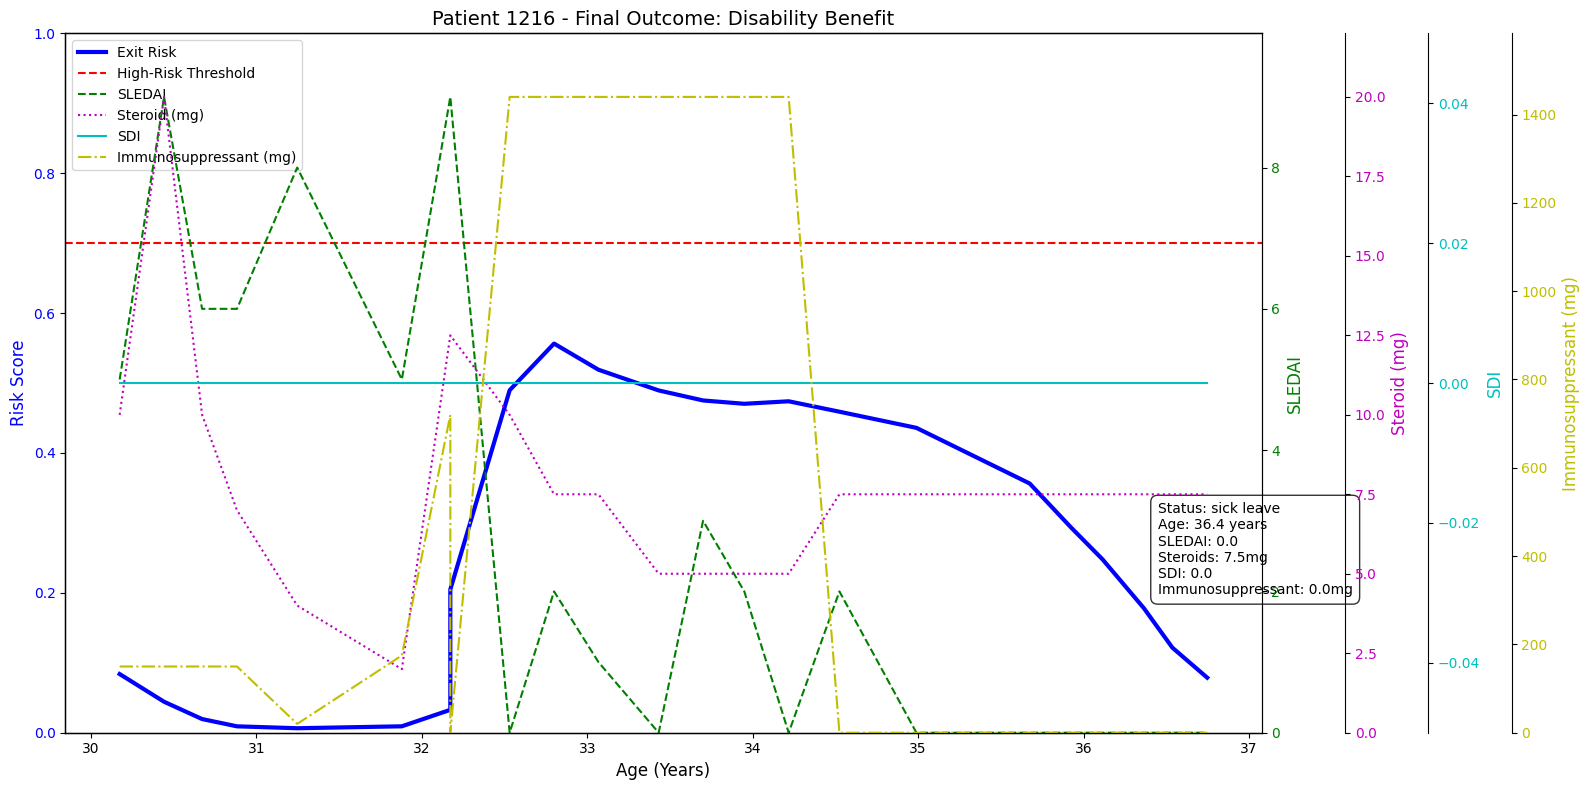

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3802051967.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


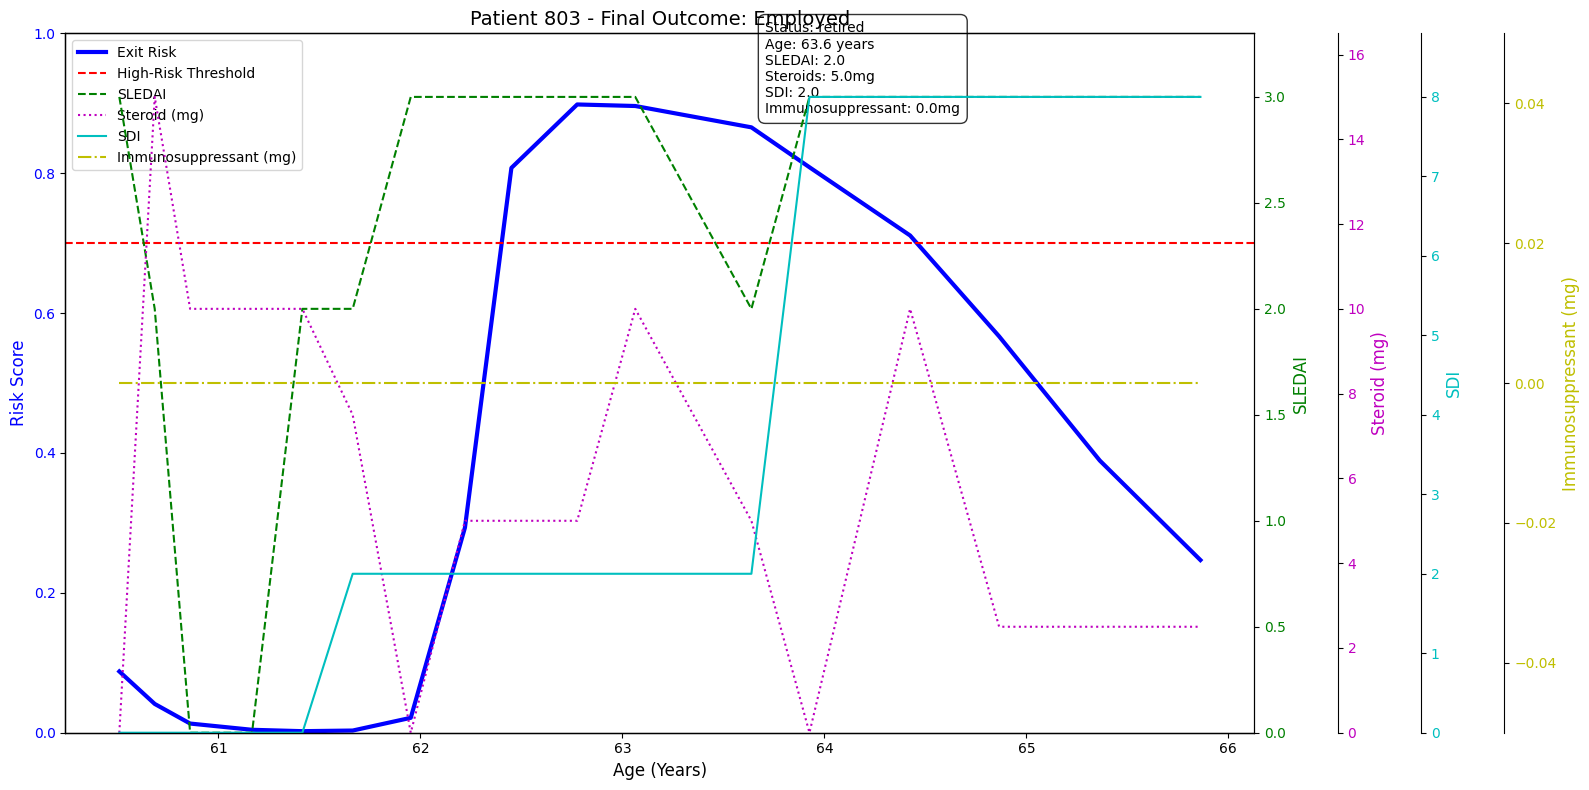

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3802051967.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


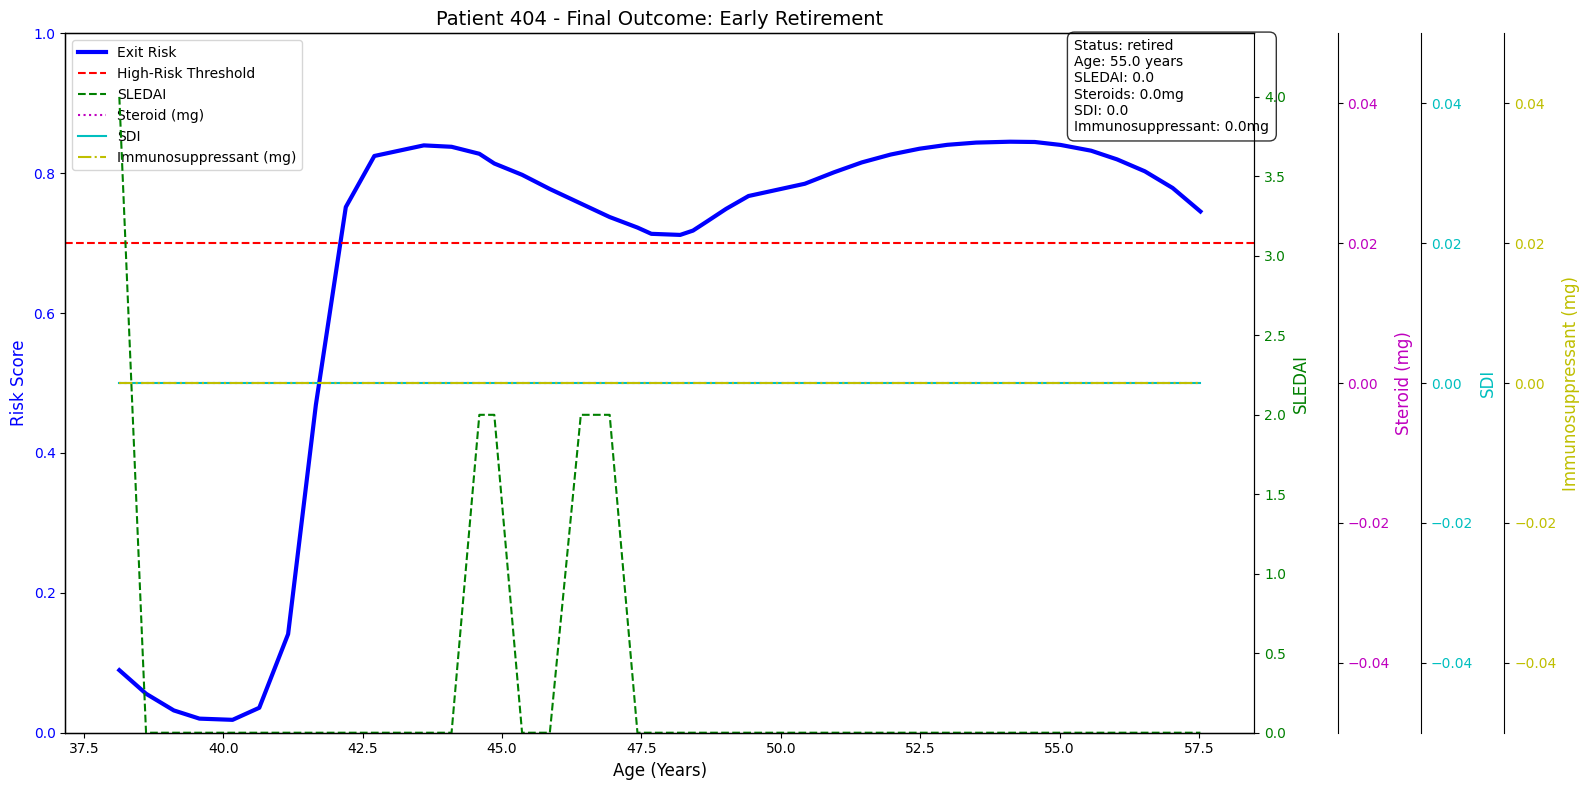

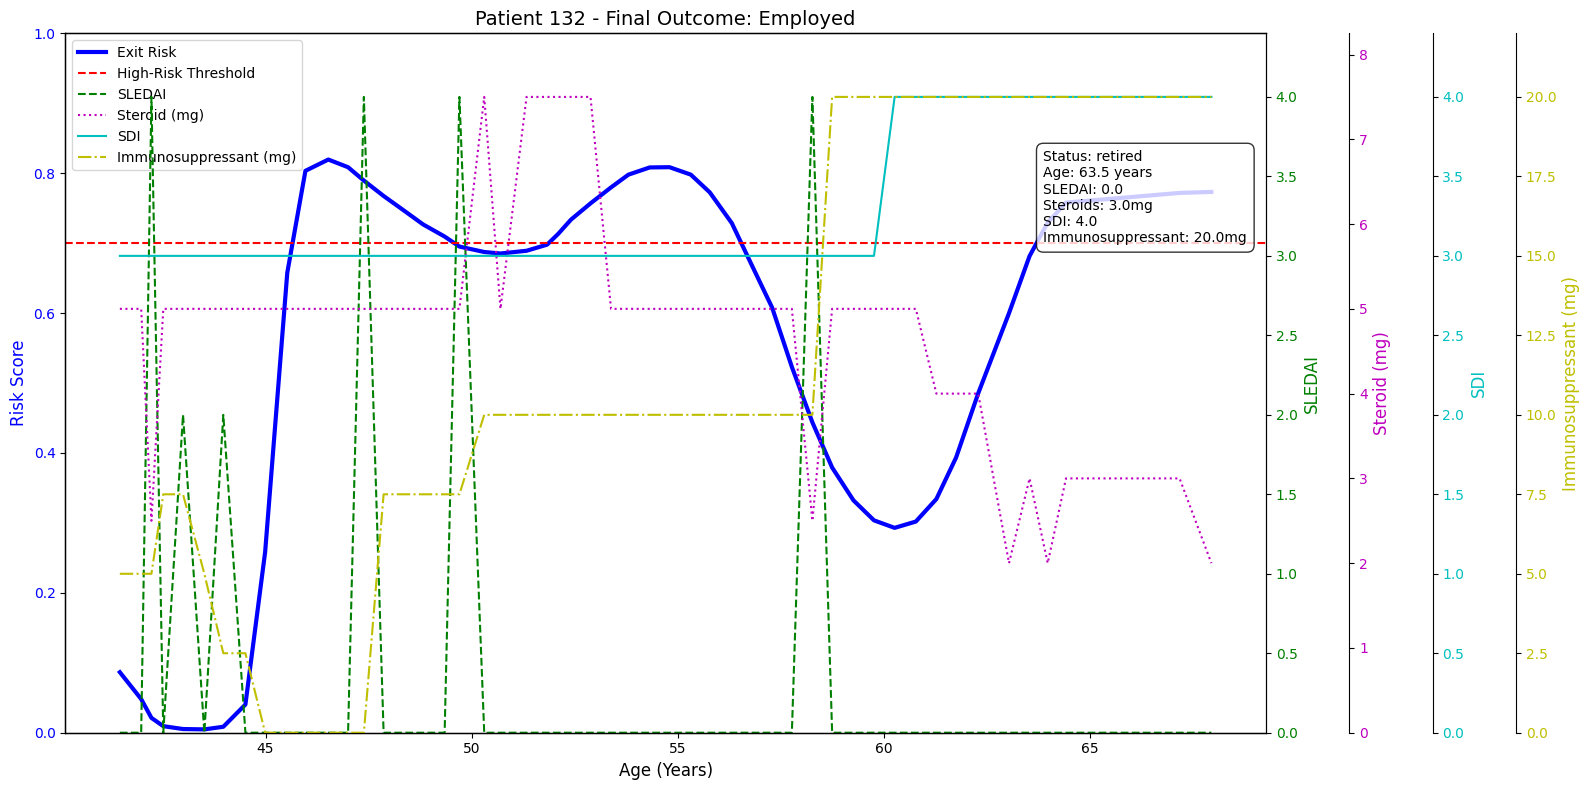

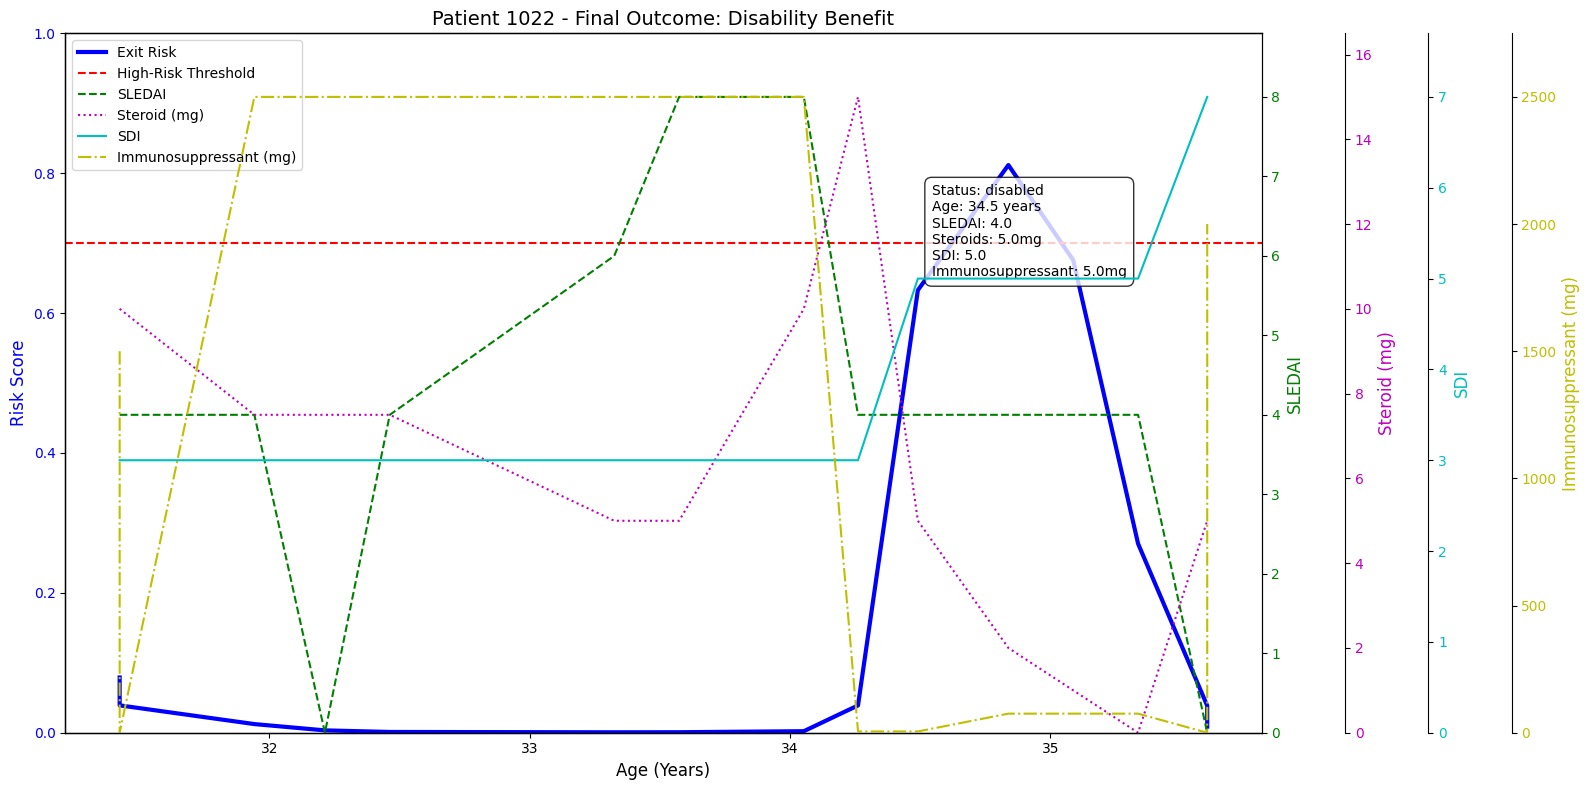

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3802051967.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


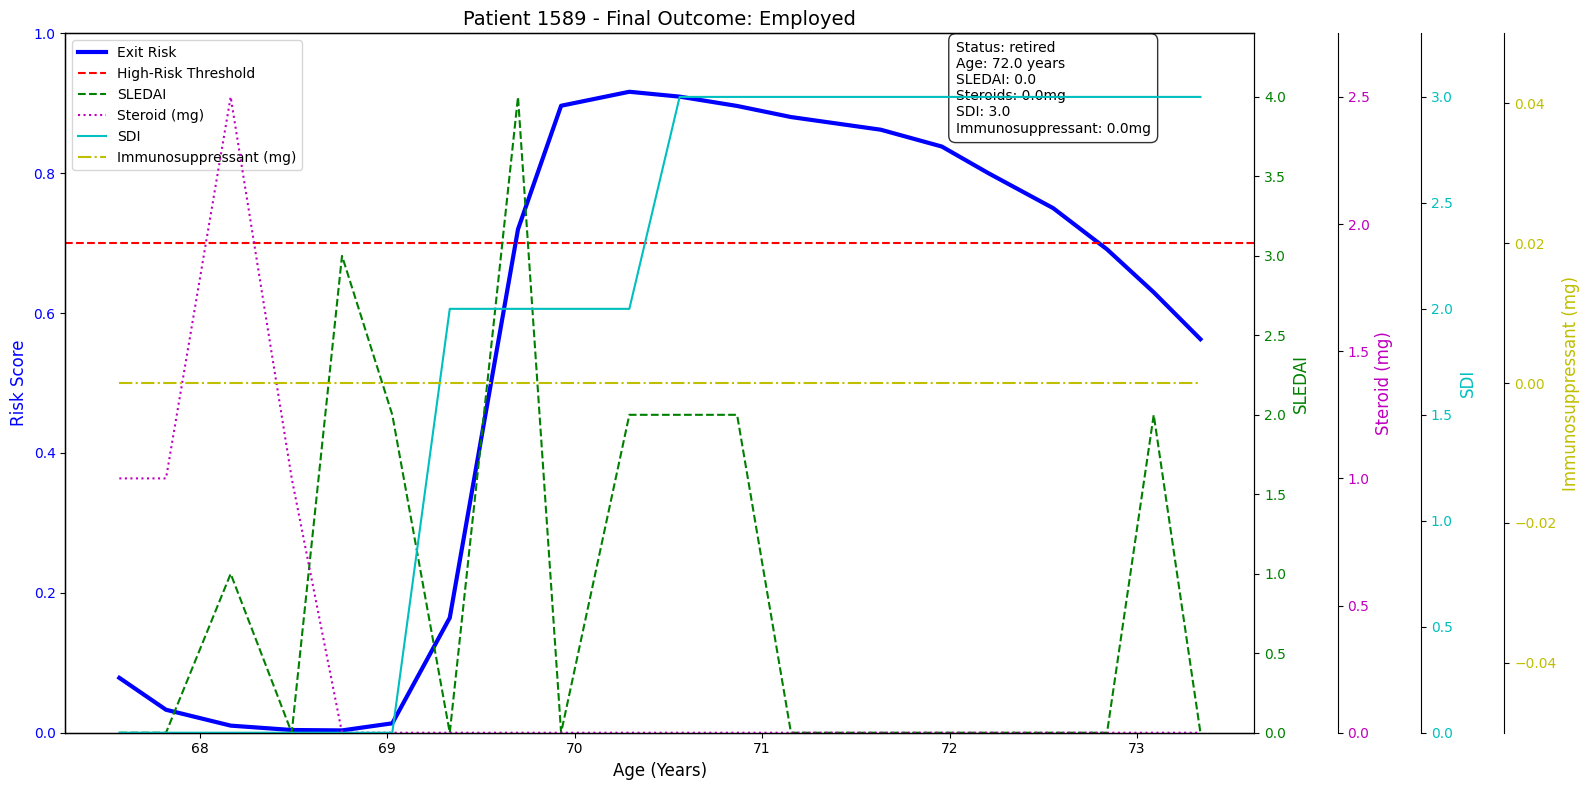

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_98702/3802051967.py:320: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_val + buffer)


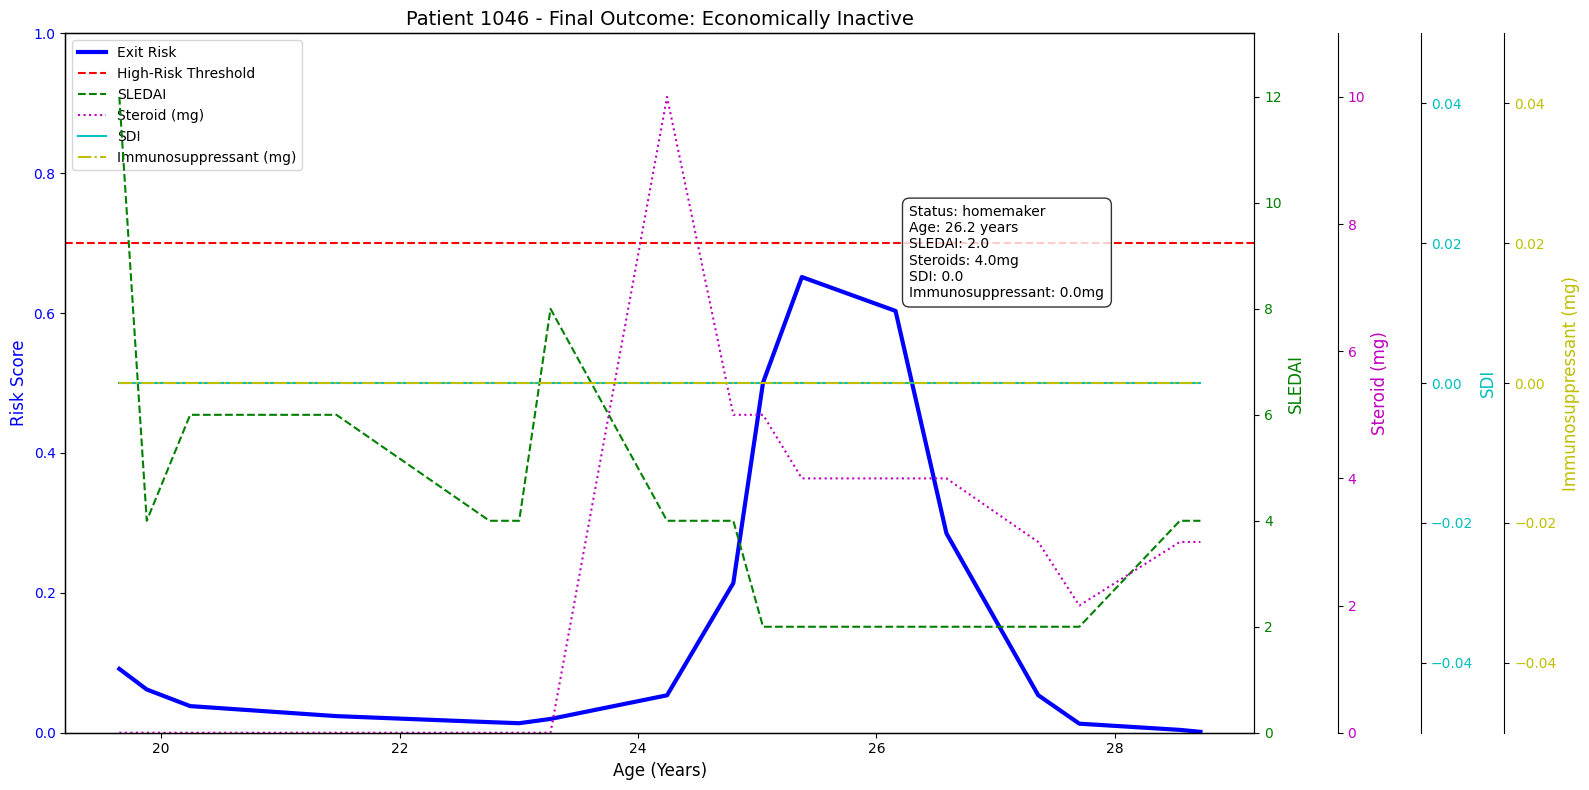

In [86]:
### Train Test Split
random.seed(365)
# Create sequences for each patient
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    num_features = len(features)
    
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()
    
    X = np.zeros((len(patients), max_seq_length, num_features))
    y = np.zeros(len(patients))
    seq_lengths = np.zeros(len(patients))
    
    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        seq_lengths[i] = seq_len
        
        # Fill the sequence data
        X[i, :seq_len, :] = patient_data[features].values
        
        # Get the end_state label (last record)
        y[i] = patient_data['end_state_encoded'].iloc[-1]
    
    return X, to_categorical(y), seq_lengths



# Create sequences
X, y, seq_lengths = create_sequences(data, features)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Build LSTM model
num_classes = y.shape[1]
model = Sequential([
    Masking(mask_value=0., input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

random.seed(365)
# Corrected model training section
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Train the model with corrected class_weight
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict  # Use the computed weights
)

# Rest of your code remains the same...

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_acc:.4f}')

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    target_names=label_encoder.classes_
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_classes, y_pred_classes))

def get_high_risk_patients(model, data, features, min_visits=3):
    """Optimized high-risk detection with enhanced criteria"""
    patients = data['PTNO'].unique()
    high_risk = []
    
    # Define dynamic threshold rules
    THRESHOLD_RULES = [
        {'conditions': {'SLEDAI2_I': lambda x: x >= 6, 'STERDOSE': lambda x: x >= 7.5},
         'risk_threshold': 0.4},
        {'conditions': {'ISDOSE': lambda x: x >= 100},
         'risk_threshold': 0.35},
        {'conditions': {'EMPf': lambda x: 'unemployed' in x.lower()},
         'risk_threshold': 0.3},
        {'default': True,
         'risk_threshold': 0.5}
    ]
    
    for pid in patients:
        patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
        if len(patient_data) < min_visits:
            continue
            
        risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
        
        # Find all warning points
        warning_points = []
        for i in range(1, len(risk_df)):
            current_data = patient_data.iloc[i]
            current_risk = risk_df['Risk_Score'].iloc[i]
            
            # Apply threshold rules
            applied_threshold = 0.5
            for rule in THRESHOLD_RULES:
                if 'default' in rule:
                    applied_threshold = rule['risk_threshold']
                    break
                if all(f(current_data[k]) for k,f in rule['conditions'].items() if k in current_data):
                    applied_threshold = rule['risk_threshold']
                    break
            
            if current_risk >= applied_threshold:
                warning_points.append({
                    'date': risk_df['ASSDT'].iloc[i],
                    'risk': current_risk,
                    'context': current_data,
                    'threshold': applied_threshold
                })
        
        # Select most clinically relevant warning
        if warning_points:
            # Prioritize warnings closer to employment change
            final_status_date = patient_data['ASSDT'].iloc[-1]
            warning_points.sort(key=lambda x: abs((final_status_date - x['date']).days))
            
            best_warning = warning_points[0]
            months_prior = (final_status_date - best_warning['date']).days // 30
            
            # Only include warnings within 5 years of exit
            if months_prior <= 60:
                high_risk.append({
                    'PTNO': pid,
                    'First_High_Risk_Date': best_warning['date'],
                    'Final_Outcome': patient_data['end_state'].iloc[-1],
                    'Risk_Score': best_warning['risk'],
                    'Threshold_Used': best_warning['threshold'],
                    'SLEDAI_at_Warning': best_warning['context']['SLEDAI2_I'],
                    'Steroid_at_Warning': best_warning['context']['STERDOSE'],
                    'SDI_at_Warning': best_warning['context']['score_n'],
                    'Immunosuppressant_at_Warning': best_warning['context']['ISDOSE'],
                    'Employment_at_Warning': best_warning['context']['EMPf'],
                    'Months_Prior_to_Exit': months_prior,
                    'Warning_Type': 'Early' if months_prior > 12 else 'Imminent'
                })
    
    return pd.DataFrame(high_risk)

def generate_clinical_report(high_risk_df, scaler, features):
    """Enhanced clinical report with steroid categories and ISDOSE flags"""
    # First verify what columns we actually have
    print("Available columns in high_risk_df:", high_risk_df.columns.tolist())
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Create mapping between warning columns and feature names
    warning_to_feature = {
        'SLEDAI_at_Warning': 'SLEDAI2_I',
        'Steroid_at_Warning': 'STERDOSE',
        'SDI_at_Warning': 'score_n',
        'Immunosuppressant_at_Warning': 'ISDOSE'
    }
    
    # Create a temporary array for inverse transform
    temp_array = np.zeros((len(high_risk_df), len(features)))
    
    # Fill the temporary array with scaled values
    for warning_col, feat in warning_to_feature.items():
        if warning_col in high_risk_df.columns and feat in feature_pos:
            temp_array[:, feature_pos[feat]] = high_risk_df[warning_col]
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract the unscaled values
    high_risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos.get('SLEDAI2_I', 0)]
    high_risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos.get('STERDOSE', 0)]
    high_risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos.get('score_n', 0)]
    high_risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos.get('ISDOSE', 0)]

    # Enhanced report with new categories
    report = {
        'Detection_Rate': f"{len(high_risk_df)}/{len(data[data['end_state'] == 'Employment Exit'])} detected",
        'Median_Warning_Time': f"{high_risk_df['Months_Prior_to_Exit'].median()} months before exit",
        'Common_Triggers': {
            'SLEDAI_Increase': f"{len(high_risk_df[high_risk_df['SLEDAI_unscaled'] >= 4])/len(high_risk_df):.0%} had SLEDAI ≥4",
            'High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] >= 7.5])/len(high_risk_df):.0%} on ≥7.5mg prednisone",
            'Very_High_Steroids': f"{len(high_risk_df[high_risk_df['Steroid_unscaled'] > 30])/len(high_risk_df):.0%} on >30mg prednisone",
            'High_ISDOSE': f"{len(high_risk_df[high_risk_df['Immunosuppressant_unscaled'] >= 100])/len(high_risk_df):.0%} on high ISDOSE (≥100mg)",
            'SDI_Elevated': f"{len(high_risk_df[high_risk_df['SDI_unscaled'] >= 1])/len(high_risk_df):.0%} had SDI ≥1",
            'Employment_Change': f"{len(high_risk_df[~high_risk_df['Employment_at_Warning'].str.contains('Employed', case=False)])/len(high_risk_df):.0%} showed work status decline"
        },
        'Trigger_Types': {
            'Risk_Score_Only': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Risk_Score'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A",
            'Clinical_Deterioration': f"{len(high_risk_df[high_risk_df['Trigger_Type'] == 'Clinical_Deterioration'])/len(high_risk_df):.0%}" if 'Trigger_Type' in high_risk_df else "N/A"
        },
        'Median_Values': {
            'SLEDAI': high_risk_df['SLEDAI_unscaled'].median(),
            'Steroid_Dose': high_risk_df['Steroid_unscaled'].median(),
            'SDI': high_risk_df['SDI_unscaled'].median(),
            'Immunosuppressant_Dose': high_risk_df['Immunosuppressant_unscaled'].median()
        },
        'Accuracy_by_Outcome': {}
    }
    
    # Calculate accuracy by outcome if 'end_state' exists in original data
    if 'end_state' in data.columns:
        for outcome in high_risk_df['Final_Outcome'].unique():
            n_correct = len(high_risk_df[high_risk_df['Final_Outcome'] == outcome])
            n_total = len(data[data['end_state'] == outcome])
            if n_total > 0:
                report['Accuracy_by_Outcome'][outcome] = f"{n_correct/n_total:.0%}"
    
    return report, high_risk_df

def plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler):
    """Plot a patient's risk score and clinical markers with age on x-axis"""
    patient_data = data[data['PTNO'] == pid].sort_values('ASSDT')
    
    # Calculate age at each assessment
    patient_data['Age'] = (patient_data['ASSDT'] - patient_data['BIRTHDT']).dt.days / 365.25
    
    risk_df = predict_risk_over_time(model, patient_data, features, X.shape[1])
    risk_df['Age'] = (risk_df['ASSDT'] - patient_data['BIRTHDT'].iloc[0]).dt.days / 365.25
    
    # Create feature position mapping
    feature_pos = {feat: idx for idx, feat in enumerate(features)}
    
    # Prepare figure with larger width to accommodate multiple axes
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # Plot risk score (left axis) with age on x-axis
    ax1.plot(risk_df['Age'], risk_df['Risk_Score'], 'b-', label='Exit Risk', linewidth=3)
    ax1.set_xlabel('Age (Years)', fontsize=12)
    ax1.set_ylabel('Risk Score', color='b', fontsize=12)
    ax1.axhline(y=0.7, color='r', linestyle='--', label='High-Risk Threshold')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_ylim(0, 1)  # Force risk score axis to start at 0 and end at 1
    
    # Create temporary array for inverse transform
    temp_array = np.zeros((len(risk_df), len(features)))
    
    # Fill with scaled values
    temp_array[:, feature_pos['SLEDAI2_I']] = risk_df['SLEDAI']
    temp_array[:, feature_pos['STERDOSE']] = risk_df['Steroid_Dose']
    temp_array[:, feature_pos['score_n']] = risk_df['SDI']
    temp_array[:, feature_pos['ISDOSE']] = risk_df['Immunosuppressant']
    
    # Apply inverse transformation
    unscaled_array = scaler.inverse_transform(temp_array)
    
    # Extract unscaled values
    risk_df['SLEDAI_unscaled'] = unscaled_array[:, feature_pos['SLEDAI2_I']]
    risk_df['Steroid_unscaled'] = unscaled_array[:, feature_pos['STERDOSE']]
    risk_df['SDI_unscaled'] = unscaled_array[:, feature_pos['score_n']]
    risk_df['Immunosuppressant_unscaled'] = unscaled_array[:, feature_pos['ISDOSE']]
    
    # Define colors and styles for each clinical marker
    clinical_markers = {
        'SLEDAI': ('g', '--'),
        'Steroid (mg)': ('m', ':'),
        'SDI': ('c', '-'),
        'Immunosuppressant (mg)': ('y', '-.')
    }
    
    # Create right axes for each clinical marker
    axes_right = {}
    offset = 60  # Pixel offset for each additional axis
    
    for i, (marker_name, (color, linestyle)) in enumerate(clinical_markers.items()):
        # Create new axis, offset from the previous one
        ax = ax1.twinx()
        ax.spines['right'].set_position(('outward', offset * i))
        
        # Plot the clinical marker
        ax.plot(risk_df['Age'], risk_df[f'{marker_name.split(" ")[0]}_unscaled'], 
               color=color, linestyle=linestyle, label=marker_name)
        
        # Style the axis and set y-lim to start at 0
        ax.set_ylabel(marker_name, color=color, fontsize=12)
        ax.tick_params(axis='y', labelcolor=color)
        
        # Get the max value for this marker to set upper bound
        max_val = risk_df[f'{marker_name.split(" ")[0]}_unscaled'].max()
        buffer = max_val * 0.1  # Add 10% buffer above max value
        ax.set_ylim(0, max_val + buffer)
        
        # Store the axis for later reference
        axes_right[marker_name] = ax
    
    # Find point where employment status changes
    status_changes = risk_df['Employment_Status'].ne(risk_df['Employment_Status'].shift())
    if status_changes.any():
        change_point = risk_df[status_changes].iloc[-1]  # Get last status change
        label = (f"Status: {change_point['Employment_Status']}\n"
                f"Age: {change_point['Age']:.1f} years\n"
                f"SLEDAI: {change_point['SLEDAI_unscaled']:.1f}\n"
                f"Steroids: {change_point['Steroid_unscaled']:.1f}mg\n"
                f"SDI: {change_point['SDI_unscaled']:.1f}\n"
                f"Immunosuppressant: {change_point['Immunosuppressant_unscaled']:.1f}mg")
        
        ax1.annotate(label, 
                    (change_point['Age'], change_point['Risk_Score']),
                    textcoords="offset points", 
                    xytext=(10,10), 
                    ha='left',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))
    
    plt.title(f'Patient {pid} - Final Outcome: {patient_data["end_state"].iloc[-1]}', fontsize=14)
    
    # Combine legends from all axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines_right = []
    labels_right = []
    
    for ax in axes_right.values():
        lines, labels = ax.get_legend_handles_labels()
        lines_right.extend(lines)
        labels_right.extend(labels)
    
    ax1.legend(lines1 + lines_right, labels1 + labels_right, loc='upper left')
    
    plt.tight_layout()
    plt.show()

data['BIRTHDT'] = pd.to_datetime(data['BIRTHDT'])
# Print patients with final state "Disability Benefit"
# -------------------
high_risk_df = get_high_risk_patients(model, data, features)


# Execute the analysis with age on x-axis
# -------------------
# Generate clinical report with all predictors
clinical_report, high_risk_df = generate_clinical_report(high_risk_df, scaler, features)

# Print value distributions
print("\n=== Value Distributions in High-Risk Patients (Unscaled) ===")
print("SLEDAI:\n", high_risk_df['SLEDAI_unscaled'].describe())
print("\nSteroid Doses:\n", high_risk_df['Steroid_unscaled'].describe())
print("\nSDI Scores:\n", high_risk_df['SDI_unscaled'].describe())
print("\nImmunosuppressant Doses:\n", high_risk_df['Immunosuppressant_unscaled'].describe())
print("\nEmployment Status:\n", high_risk_df['Employment_at_Warning'].value_counts())

# Print comprehensive clinical report
print("\n=== Actionable Clinical Insights ===")
print(f"Early Warning: Model flagged {len(high_risk_df)} patients at high risk")
print(f"Median lead time: {clinical_report['Median_Warning_Time']}")
print("\nKey Predictors of Labor Force Exit:")
for k, v in clinical_report['Common_Triggers'].items():
    print(f"- {v}")
print("\nMedian Values at Warning Point:")
for k, v in clinical_report['Median_Values'].items():
    print(f"- {k}: {v:.2f}")

# Visualize example cases with age on x-axis
print("\nVisualizing High-Risk Patient Trajectories (Age on X-axis)...")
for pid in high_risk_df['PTNO'].sample(min(10, len(high_risk_df)), random_state=69):
    plot_high_risk_trajectory_age_xaxis(pid, data, model, features, scaler)